# Modelo de Regresión Logística

Este notebook implementa la Regresión Logística como modelo supervisado base para la detección y clasificación de tráfico anómalo en el dataset LITNET-2020.

Se desarrollan dos tareas:

1. Clasificación binaria: distinguir entre tráfico normal (`attack_a = 0`) y tráfico de ataque (`attack_a = 1`).
2. Clasificación multiclase: identificar el tipo específico de ataque utilizando únicamente los registros con `attack_a = 1` y la variable objetivo `attack_t`.

El notebook reutiliza el particionamiento y las funciones de preprocesamiento definidas en `03_preprocesamiento_para_modelado.ipynb`. El preprocesamiento se ajustará exclusivamente con datos de entrenamiento (`fit`) y posteriormente se aplicará sin reajuste sobre validación y prueba (`transform`).

Durante la fase de desarrollo se utilizará `dataset_modelado_dev.parquet` para reducir el costo computacional. La configuración seleccionada posteriormente podrá evaluarse sobre el conjunto completo `dataset_modelado_con_split.parquet`.

El conjunto de prueba se reserva para la evaluación final y no se utilizará durante la selección de estrategias de desbalance, hiperparámetros o umbrales de clasificación.

In [1]:
from pathlib import Path
import sys
import json
import random
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
SECOND_RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [5]:
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data"
INTERIM_PATH = DATA_PATH / "interim"
RESULTS_PATH = PROJECT_ROOT / "results"
PREPROCESSING_RESULTS_PATH = RESULTS_PATH / "preprocessing"
LR_RESULTS_PATH = (RESULTS_PATH / "modeling" / "logistic_regression")
LR_BINARY_RESULTS_PATH = (LR_RESULTS_PATH / "binary")
LR_MULTICLASS_RESULTS_PATH = (LR_RESULTS_PATH / "multiclass")
MODELS_PATH = PROJECT_ROOT / "models"
LR_MODELS_PATH = (MODELS_PATH / "logistic_regression")
for path in [LR_RESULTS_PATH, LR_BINARY_RESULTS_PATH, LR_MULTICLASS_RESULTS_PATH, LR_MODELS_PATH]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:")
print(PROJECT_ROOT)
print("\nResultados Regresión Logística:")
print(LR_RESULTS_PATH)
print("\nModelos Regresión Logística:")
print(LR_MODELS_PATH)

PROJECT_ROOT:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026

Resultados Regresión Logística:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression

Modelos Regresión Logística:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\models\logistic_regression


In [6]:
# Modo de ejecución - muestra DEV o dataset completo
USE_DEV_SAMPLE = False 
DATASET_MODE = (
    "development"
    if USE_DEV_SAMPLE
    else "full"
)
print(f"Modo de ejecución: {DATASET_MODE}")
if USE_DEV_SAMPLE:
    print("Se utilizará dataset_modelado_dev.parquet.")
else:
    print("Se utilizará dataset_modelado_con_split.parquet.")

Modo de ejecución: full
Se utilizará dataset_modelado_con_split.parquet.


### Configuraciones de preprocesamiento y desbalance

Las decisiones sobre variables, transformaciones y estrategias de desbalance no se redefinen en este notebook. Se cargan desde los archivos generados previamente, garantizando que los distintos modelos utilicen una configuración común.

In [7]:
# Archivos de configuración
PREPROCESSING_CONFIG_PATH = (PREPROCESSING_RESULTS_PATH / "preprocessing_config.json")
IMBALANCE_CONFIG_PATH = (PREPROCESSING_RESULTS_PATH / "imbalance_config.json")
for config_path in [PREPROCESSING_CONFIG_PATH, IMBALANCE_CONFIG_PATH,]:
    if not config_path.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo: {config_path}"
        )

with open(PREPROCESSING_CONFIG_PATH, "r", encoding="utf-8") as file:
    preprocessing_config = json.load(file)

with open(IMBALANCE_CONFIG_PATH, "r", encoding="utf-8") as file:
    imbalance_config = json.load(file)

print("Configuraciones cargadas correctamente.")
print("\nNúmero de variables predictoras:", len(preprocessing_config["predictor_candidate_columns"]))
print("\nEstrategias de desbalance:")
print(imbalance_config["imbalance_strategies"])

Configuraciones cargadas correctamente.

Número de variables predictoras: 22

Estrategias de desbalance:
['none', 'class_weight', 'smote', 'adasyn', 'smote_enn']


In [8]:
# Validación básica de configuraciones
required_preprocessing_keys = {
    "numeric_log_columns",
    "binary_flag_columns",
    "one_hot_columns",
    "frequency_encoding_columns",
    "ip_columns",
    "port_feature_columns",
    "target_columns",
    "predictor_candidate_columns",
    "binary_target_column",
    "multiclass_target_column",
}
missing_preprocessing_keys = (required_preprocessing_keys - set(preprocessing_config))
if missing_preprocessing_keys:
    raise ValueError("Faltan elementos en preprocessing_config: "f"{sorted(missing_preprocessing_keys)}")

if "imbalance_strategies" not in imbalance_config:
    raise ValueError("imbalance_config no contiene'imbalance_strategies'.")

print("Configuraciones validadas correctamente.")

Configuraciones validadas correctamente.


### Utilidades reutilizables

Las funciones de carga, separación de variables, preprocesamiento y manejo del desbalance se importan desde `src/modeling_utils.py`.

In [9]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [10]:
from src.modeling_utils import (
    build_base_preprocessor,
    get_transformed_feature_names,
    load_split_dataframe,
    split_features_target,
    compute_class_weight_dict,
    build_resampler,
    validate_imbalance_strategy_for_model,
    summarize_class_distribution,
)
print("Utilidades de modelado cargadas correctamente")

Utilidades de modelado cargadas correctamente


## 1. Carga y validación de los datos

Se cargan únicamente las particiones de entrenamiento y validación. El conjunto de prueba permanece reservado para la evaluación final del modelo.

Durante esta primera etapa se utiliza la muestra de desarrollo. No se genera un nuevo particionamiento, sino que se conserva exactamente la asignación `train/valid/test` definida en el notebook 03.

In [11]:
# Columnas necesarias para el modelado
predictor_columns = (preprocessing_config["predictor_candidate_columns"])
target_columns = (preprocessing_config["target_columns"])
metadata_columns = ["clase", "strata_key", "split", "row_id_model"]
modeling_columns = list(dict.fromkeys(predictor_columns + target_columns + metadata_columns))
print("Variables predictoras:", len(predictor_columns))
print("Columnas cargadas en total:", len(modeling_columns))

Variables predictoras: 22
Columnas cargadas en total: 28


In [12]:
# Carga de TRAIN
df_train = load_split_dataframe(
    split_name="train",
    preprocessing_config=preprocessing_config,
    use_dev_sample=USE_DEV_SAMPLE,
    columns=modeling_columns,
    project_root=PROJECT_ROOT,
)
print("TRAIN cargado:", df_train.shape)

TRAIN cargado: (15803376, 28)


In [13]:
# Carga de VALID
df_valid = load_split_dataframe(
    split_name="valid",
    preprocessing_config=preprocessing_config,
    use_dev_sample=USE_DEV_SAMPLE,
    columns=modeling_columns,
    project_root=PROJECT_ROOT,
)
print("VALID cargado:", df_valid.shape)

VALID cargado: (3386438, 28)


In [14]:
# Validación estructural
required_columns = set(modeling_columns)
for split_name, df in {"train": df_train, "valid": df_valid}.items():
    missing_columns = (required_columns - set(df.columns))
    if missing_columns:
        raise ValueError(f"{split_name}: faltan columnas: " f"{sorted(missing_columns)}")

    if not df["split"].eq(split_name).all():
        raise ValueError(f"{split_name}: se encontraron registros pertenecientes a otro split.")

    # Los objetivos no deben tener nulos
    if df[preprocessing_config["binary_target_column"]].isna().any():
        raise ValueError(f"{split_name}: attack_a contiene nulos.")

    # Identificador único dentro del split
    if df["row_id_model"].duplicated().any():
        raise ValueError(f"{split_name}: row_id_model contiene duplicados.")

# Validar valores de la tarea binaria
binary_values = set(pd.concat([df_train["attack_a"], df_valid["attack_a"]]).unique())
if not binary_values.issubset({0, 1}):
    raise ValueError("attack_a contiene valores "f"inesperados: {binary_values}")

# Confirmar ausencia de solapamiento entre train y valid
train_ids = (df_train["row_id_model"].to_numpy())
valid_ids = (df_valid["row_id_model"].to_numpy())
overlap_ids = np.intersect1d(train_ids, valid_ids, assume_unique=True)
if overlap_ids.size > 0:
    raise ValueError("Se encontraron registros compartidos entre train y valid.")

print("Validación estructural completada correctamente.")

Validación estructural completada correctamente.


In [12]:
# Distribución binaria
df_binary_distribution = pd.concat(
    [summarize_class_distribution(df_train["attack_a"], name="train"),
        summarize_class_distribution(df_valid["attack_a"], name="valid"),
    ],ignore_index=True,
)
df_binary_distribution

,dataset,clase,n,porcentaje
0,train,0,14775206,93.493985
1,train,1,1028170,6.506015
2,valid,0,3166116,93.493990
3,valid,1,220322,6.506010


In [13]:
# Distribución multiclase solo registros attack_a = 1
y_train_multiclass_check = df_train.loc[df_train["attack_a"].eq(1),"attack_t"]
y_valid_multiclass_check = df_valid.loc[df_valid["attack_a"].eq(1), "attack_t"]
df_multiclass_distribution = pd.concat([
        summarize_class_distribution(y_train_multiclass_check, name="train"),
        summarize_class_distribution(y_valid_multiclass_check, name="valid"),
    ],ignore_index=True,
)
df_multiclass_distribution

,dataset,clase,n,porcentaje
0,train,tcp_red_w,878991,85.490824
1,train,udp_f,65508,6.371320
2,train,icmp_smf,41635,4.049428
3,train,tcp_w32_w,17003,1.653715
4,train,http_f,16071,1.563068
5,train,icmp_f,8139,0.791601
6,train,udp_reaper_w,823,0.080045
7,valid,tcp_red_w,188355,85.490782
8,valid,udp_f,14037,6.371130
9,valid,icmp_smf,8922,4.049528


In [15]:
# Clases de ataque esperadas
ATTACK_CLASS_ORDER = ["icmp_f", "icmp_smf", "udp_f", "http_f", "tcp_w32_w", "tcp_red_w", "udp_reaper_w"]
expected_attack_classes = set(ATTACK_CLASS_ORDER)
for split_name, df in {"train": df_train, "valid": df_valid}.items():
    observed_classes = set(df.loc[df["attack_a"].eq(1), "attack_t"].dropna().unique())
    missing_classes = (expected_attack_classes - observed_classes)
    unexpected_classes = (observed_classes - expected_attack_classes)
    if missing_classes:
        raise ValueError(f"{split_name}: faltan clases de ataque: "f"{sorted(missing_classes)}")
    if unexpected_classes:
        raise ValueError(f"{split_name}: aparecen clases no esperadas: "f"{sorted(unexpected_classes)}")

print("Las siete clases de ataque están presentes en train y valid.")

Las siete clases de ataque están presentes en train y valid.


## 2. Definición de las tareas de clasificación

**Clasificación binaria**

La tarea principal consiste en detectar si un flujo corresponde a tráfico normal o anómalo. Se utiliza `attack_a` como variable objetivo:

- `0`: tráfico normal.
- `1`: tráfico de ataque.

Para esta tarea se utilizan todos los registros de cada partición.

**Clasificación multiclase**

Como tarea complementaria se evalúa la capacidad del modelo para diferenciar entre los tipos de ataque presentes en el conjunto de datos.
Primero se seleccionan únicamente los registros con `attack_a = 1` y posteriormente se utiliza `attack_t` como variable objetivo. Por tanto, el tráfico normal no constituye una clase de esta tarea.
Las clases consideradas son `icmp_f`, `icmp_smf`, `udp_f`, `http_f`, `tcp_w32_w`, `tcp_red_w` y `udp_reaper_w`.

Ambas tareas conservan las particiones definidas en el notebook 03; no se realiza un nuevo split.

In [16]:
# Definición formal de tareas
BINARY_CLASS_ORDER = [0, 1]
ATTACK_CLASS_ORDER = ["icmp_f", "icmp_smf", "udp_f", "http_f", "tcp_w32_w", "tcp_red_w", "udp_reaper_w"]
TASK_CONFIG = {
    "binary": {
        "target_column": preprocessing_config["binary_target_column"],
        "positive_label": 1,
        "class_order": BINARY_CLASS_ORDER,
        "description": "Detección de tráfico normal frente a ataque",
    },
    "multiclass": {
        "target_column":preprocessing_config["multiclass_target_column"],
        "filter_column":preprocessing_config["binary_target_column"],
        "filter_value": 1,
        "class_order": ATTACK_CLASS_ORDER,
        "description": "Clasificación del tipo de ataque",
    },
}
for task_name, config in TASK_CONFIG.items():
    print(f"{task_name.upper()}: " f"{config['description']}")

BINARY: Detección de tráfico normal frente a ataque
MULTICLASS: Clasificación del tipo de ataque


## 3. Construcción del pipeline de Regresión Logística

Se construye un pipeline común que integra el preprocesamiento definido en el notebook 03, el tratamiento opcional del desbalance de clases y el clasificador de Regresión Logística. El flujo general es:

**Datos originales → Preprocesamiento → Estrategia de desbalance opcional → Regresión Logística**

Se consideran cinco escenarios:

1. `none`: distribución de entrenamiento sin modificación.
2. `class_weight`: ajuste de los pesos de las clases sin modificar las observaciones.
3. `smote`: sobremuestreo sintético de las clases minoritarias.
4. `adasyn`: sobremuestreo adaptativo.
5. `smote_enn`: sobremuestreo mediante SMOTE seguido de limpieza mediante ENN.

El preprocesamiento y cualquier técnica de remuestreo serán ajustados exclusivamente durante el entrenamiento. Validación y prueba únicamente recibirán las transformaciones aprendidas.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from imblearn.pipeline import Pipeline as ImbPipeline
import sklearn
import imblearn
warnings.filterwarnings("default", category=ConvergenceWarning)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

scikit-learn: 1.7.1
imbalanced-learn: 0.14.2


### 3.1 Configuración base del clasificador

Antes de realizar optimización de hiperparámetros se establece una configuración inicial común para todos los escenarios de desbalance.
Se utiliza el solver `saga`, adecuado para conjuntos de datos grandes y compatible con clasificación binaria y multiclase. Como configuración inicial se utiliza regularización L2 con `C = 1.0`. Se establece un máximo amplio de iteraciones para reducir el riesgo de detener el entrenamiento antes de alcanzar convergencia. Esta configuración constituye el punto de partida del experimento y posteriormente será sometida a optimización.

In [18]:
# Configuración base de Regresión Logística
LR_BASE_PARAMS = {
    "solver": "saga",
    "penalty": "l2",
    "C": 1.0,
    "fit_intercept": True,
    "max_iter": 1000,
    "tol": 1e-4,
    "random_state": RANDOM_STATE,
}
LR_STRATEGIES = ["none", "class_weight", "smote", "adasyn", "smote_enn"]
print("Parámetros base:")
print(LR_BASE_PARAMS)
print("\nEstrategias:")
print(LR_STRATEGIES)

Parámetros base:
{'solver': 'saga', 'penalty': 'l2', 'C': 1.0, 'fit_intercept': True, 'max_iter': 1000, 'tol': 0.0001, 'random_state': 42}

Estrategias:
['none', 'class_weight', 'smote', 'adasyn', 'smote_enn']


In [19]:
configured_strategies = set(imbalance_config["imbalance_strategies"])
expected_strategies = set(LR_STRATEGIES)
if configured_strategies != expected_strategies:
    raise ValueError("Las estrategias del notebook 04 no coinciden con imbalance_config. "f"Configuradas: {sorted(configured_strategies)} | "
        f"Esperadas: {sorted(expected_strategies)}"
    )
print("Las estrategias de desbalance coinciden con imbalance_config.")

Las estrategias de desbalance coinciden con imbalance_config.


In [20]:
# Etiquetas de entrenamiento
y_train_binary_ref = df_train["attack_a"]
attack_train_mask = df_train["attack_a"].eq(1)
y_train_multiclass_ref = df_train.loc[attack_train_mask, "attack_t"]
print("Tarea binaria:", len(y_train_binary_ref), "registros")
print("Tarea multiclase:", len(y_train_multiclass_ref), "ataques")

Tarea binaria: 15803376 registros
Tarea multiclase: 1028170 ataques


In [21]:
binary_class_weights = compute_class_weight_dict(y_train_binary_ref)
multiclass_class_weights = compute_class_weight_dict(y_train_multiclass_ref)
print("Pesos de clase - tarea binaria:")
print(binary_class_weights)
print("\nPesos de clase - tarea multiclase:")
print(multiclass_class_weights)

Pesos de clase - tarea binaria:
{0: 0.5347937619279217, 1: 7.68519602789422}

Pesos de clase - tarea multiclase:
{'http_f': 9.139532609758483, 'icmp_f': 18.046618573710354, 'icmp_smf': 3.527835440649179, 'tcp_red_w': 0.16710231227786015, 'tcp_w32_w': 8.638559581922518, 'udp_f': 2.242190702989384, 'udp_reaper_w': 178.47075160562403}


### 3.2 Constructor del pipeline

Para cada escenario se genera un pipeline independiente. El preprocesador se crea nuevamente en cada ejecución para garantizar que sus estadísticas sean aprendidas exclusivamente durante el ajuste correspondiente.

En el escenario `class_weight` se modifican los pesos utilizados por Regresión Logística, pero no se altera el número de observaciones. En los escenarios SMOTE, ADASYN y SMOTE+ENN se utiliza el remuestreador definido en el notebook 03. Las estrategias de remuestreo no se combinan inicialmente con pesos de clase para poder analizar por separado el efecto de cada tratamiento del desbalance.

In [22]:
def build_logistic_regression_pipeline(task, strategy_name, y_train, binary_profile="conservative"):
    if task not in {"binary", "multiclass"}:
        raise ValueError("task debe ser 'binary' o 'multiclass'.")
    if strategy_name not in LR_STRATEGIES:
        raise ValueError(f"Estrategia no válida: {strategy_name}")

    validate_imbalance_strategy_for_model(strategy_name=strategy_name, model_family="logistic_regression", imbalance_config=imbalance_config)
    # Preprocesamiento nuevo para cada pipeline
    preprocessor = build_base_preprocessor(preprocessing_config=preprocessing_config, model_family="linear")

    # Pesos solo en el escenario class_weight
    class_weight = (compute_class_weight_dict(y_train)
        if strategy_name == "class_weight"
        else None
    )
    # Remuestreo solo para SMOTE / ADASYN / SMOTE+ENN
    resampler = build_resampler(
        strategy_name=strategy_name,
        task=task,
        y_train=y_train,
        imbalance_config=imbalance_config,
        random_state=RANDOM_STATE,
        binary_profile=binary_profile,
    )
    classifier = LogisticRegression(**LR_BASE_PARAMS, class_weight=class_weight)
    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("resampler", resampler if resampler is not None else "passthrough"),
        ("classifier", classifier),
    ])
    return pipeline

**Escenarios experimentales**

| Escenario | Preprocesamiento | Remuestreo | Pesos de clase |
|---|---|---|---|
| `none` | Sí | No | No |
| `class_weight` | Sí | No | Sí |
| `smote` | Sí | SMOTE | No |
| `adasyn` | Sí | ADASYN | No |
| `smote_enn` | Sí | SMOTE + ENN | No |

De esta manera cada escenario modifica únicamente un componente relacionado con el tratamiento del desbalance, manteniendo constante la configuración inicial de Regresión Logística.

In [23]:
lr_binary_pipelines = {
    strategy: build_logistic_regression_pipeline(task="binary", strategy_name=strategy, y_train=y_train_binary_ref)
    for strategy in LR_STRATEGIES
}
print("Pipelines binarios preparados:")
print(list(lr_binary_pipelines))

Pipelines binarios preparados:
['none', 'class_weight', 'smote', 'adasyn', 'smote_enn']


In [24]:
lr_multiclass_pipelines = {
    strategy: build_logistic_regression_pipeline(task="multiclass", strategy_name=strategy, y_train=y_train_multiclass_ref)
    for strategy in LR_STRATEGIES
}
print("Pipelines multiclase preparados:")
print(list(lr_multiclass_pipelines))

Pipelines multiclase preparados:
['none', 'class_weight', 'smote', 'adasyn', 'smote_enn']


In [25]:
def summarize_lr_pipelines(pipelines, task):
    rows = []
    for strategy, pipeline in pipelines.items():
        resampler = pipeline.named_steps["resampler"]
        classifier = pipeline.named_steps["classifier"]
        rows.append({
            "task": task,
            "strategy": strategy,
            "preprocessor": type(pipeline.named_steps["preprocessor"]).__name__,
            "resampler": "None" if resampler == "passthrough" else type(resampler).__name__,
            "class_weight": "Sí" if classifier.class_weight is not None else "No",
            "solver": classifier.solver,
            "C": classifier.C,
            "max_iter": classifier.max_iter,
        })
    return pd.DataFrame(rows)

In [26]:
df_pipeline_summary = pd.concat([
    summarize_lr_pipelines(lr_binary_pipelines, "binary"),
    summarize_lr_pipelines(lr_multiclass_pipelines, "multiclass"),
], ignore_index=True)
df_pipeline_summary

,task,strategy,preprocessor,resampler,class_weight,solver,C,max_iter
0,binary,none,ColumnTransformer,None,No,saga,1.0,1000
1,binary,class_weight,ColumnTransformer,None,Sí,saga,1.0,1000
2,binary,smote,ColumnTransformer,SMOTE,No,saga,1.0,1000
3,binary,adasyn,ColumnTransformer,ADASYN,No,saga,1.0,1000
4,binary,smote_enn,ColumnTransformer,SMOTEENN,No,saga,1.0,1000
5,multiclass,none,ColumnTransformer,None,No,saga,1.0,1000
6,multiclass,class_weight,ColumnTransformer,None,Sí,saga,1.0,1000
7,multiclass,smote,ColumnTransformer,SMOTE,No,saga,1.0,1000
8,multiclass,adasyn,ColumnTransformer,ADASYN,No,saga,1.0,1000
9,multiclass,smote_enn,ColumnTransformer,SMOTEENN,No,saga,1.0,1000


In [27]:
for strategy in ["smote", "adasyn", "smote_enn"]:
    sampler = lr_binary_pipelines[strategy].named_steps["resampler"]
    print(f"{strategy:10s} -> " f"sampling_strategy = {sampler.sampling_strategy}")

smote      -> sampling_strategy = {1: 1178170}
adasyn     -> sampling_strategy = {1: 1178170}
smote_enn  -> sampling_strategy = {1: 1178170}


In [28]:
for strategy in ["smote", "adasyn", "smote_enn"]:
    sampler = lr_multiclass_pipelines[strategy].named_steps["resampler"]
    print(f"\n{strategy}:")
    print(sampler.sampling_strategy)


smote:
{'icmp_smf': 50000, 'tcp_w32_w': 25504, 'http_f': 24106, 'icmp_f': 12208, 'udp_reaper_w': 1234}

adasyn:
{'icmp_smf': 50000, 'tcp_w32_w': 25504, 'http_f': 24106, 'icmp_f': 12208, 'udp_reaper_w': 1234}

smote_enn:
{'icmp_smf': 50000, 'tcp_w32_w': 25504, 'http_f': 24106, 'icmp_f': 12208, 'udp_reaper_w': 1234}


In [28]:
#Comprobación de independencia de pipelines
assert (lr_binary_pipelines["none"].named_steps["preprocessor"] is not lr_binary_pipelines["smote"].named_steps["preprocessor"])
assert (lr_binary_pipelines["none"].named_steps["classifier"] is not lr_binary_pipelines["class_weight"].named_steps["classifier"])
print("Cada escenario contiene instancias independientes.")

Cada escenario contiene instancias independientes.


## 4. Funciones de evaluación

Se definen funciones comunes para evaluar de manera uniforme todos los escenarios de Regresión Logística. Estas funciones se utilizarán posteriormente sobre validación y prueba sin modificar el modelo ni los datos evaluados.

Para la **clasificación binaria**, la clase positiva corresponde al tráfico de ataque (`attack_a = 1`). Se reportan Precision, Recall, F1, PR-AUC, ROC-AUC, Balanced Accuracy y matriz de confusión.

Para la **clasificación multiclase**, Macro-F1 constituye la métrica principal debido al desbalance entre tipos de ataque. También se reportan Weighted-F1, Precision y Recall macro, Balanced Accuracy, métricas individuales por clase y matriz de confusión.

In [29]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score,
    precision_recall_curve, auc,
    confusion_matrix, precision_recall_fscore_support
)

### 4.1 Evaluación de la tarea binaria

La evaluación binaria utiliza la probabilidad estimada para la clase ataque. Inicialmente se utiliza un umbral de decisión de `0.50`.
Además de las métricas agregadas, se almacenan los valores TN, FP, FN y TP para facilitar el análisis posterior de falsas alarmas y ataques no detectados.

In [30]:
def evaluate_binary_predictions(y_true, y_score, threshold=0.50, positive_label=1):
    """Evalúa la clasificación binaria a partir de probabilidades de ataque."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(np.int8)

    precision = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_score)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_score, pos_label=positive_label)
    pr_auc = auc(recall_curve, precision_curve)

    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = pd.DataFrame([{
        "threshold": threshold,
        "precision_attack": precision,
        "recall_attack": recall,
        "f1_attack": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "balanced_accuracy": balanced_acc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "n": len(y_true),
    }])

    cm_df = pd.DataFrame(cm, index=["real_normal", "real_attack"], columns=["pred_normal", "pred_attack"])
    return metrics, cm_df, y_pred

In [31]:
def get_binary_attack_scores(fitted_pipeline, X, positive_label=1):
    """Obtiene P(ataque) a partir de un pipeline ya entrenado."""
    probabilities = fitted_pipeline.predict_proba(X)
    classes = fitted_pipeline.named_steps["classifier"].classes_
    positive_idx = np.where(classes == positive_label)[0]
    if len(positive_idx) != 1:
        raise ValueError(f"No se encontró correctamente la clase positiva {positive_label}.")

    return probabilities[:, positive_idx[0]]

### 4.2 Evaluación de la tarea multiclase

En la clasificación del tipo de ataque se utiliza Macro-F1 como métrica principal, ya que otorga el mismo peso a cada clase independientemente de su frecuencia. Se calculan también Weighted-F1, Precision y Recall macro, Balanced Accuracy y las métricas individuales de cada ataque.

In [32]:
def evaluate_multiclass_predictions(y_true, y_pred, class_order):
    """Evalúa la clasificación multiclase y genera métricas globales y por clase."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    summary = pd.DataFrame([{
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "balanced_accuracy": balanced_acc,
        "n": len(y_true),
    }])
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=class_order, zero_division=0
    )
    per_class = pd.DataFrame({
        "class": class_order,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(int),
    })
    cm = confusion_matrix(y_true, y_pred, labels=class_order)
    cm_df = pd.DataFrame(cm, index=[f"real_{label}" for label in class_order], columns=[f"pred_{label}" for label in class_order])
    return summary, per_class, cm_df

In [33]:
PRIMARY_METRIC = {
    "binary": "pr_auc",
    "multiclass": "macro_f1",
}
SECONDARY_METRICS = {
    "binary": ["precision_attack", "recall_attack", "f1_attack", "roc_auc", "balanced_accuracy"],
    "multiclass": ["macro_precision", "macro_recall", "weighted_f1", "balanced_accuracy"],
}
print("Métrica principal binaria:", PRIMARY_METRIC["binary"])
print("Métrica principal multiclase:", PRIMARY_METRIC["multiclass"])

Métrica principal binaria: pr_auc
Métrica principal multiclase: macro_f1


**Función para añadir información del experimento**

In [34]:
def add_experiment_metadata(metrics_df, task, strategy, split, dataset_mode=DATASET_MODE):
    """Añade información común para identificar cada resultado experimental."""
    result = metrics_df.copy()
    result.insert(0, "dataset_mode", dataset_mode)
    result.insert(1, "model", "logistic_regression")
    result.insert(2, "task", task)
    result.insert(3, "strategy", strategy)
    result.insert(4, "split", split)

    return result

In [35]:
binary_experiment_results = []
multiclass_experiment_results = []
print("Estructuras de resultados inicializadas.")

Estructuras de resultados inicializadas.


## 5. Experimento binario base

Se entrena una primera Regresión Logística para establecer el desempeño de referencia de la tarea binaria. El modelo se ajusta exclusivamente con `train` y se evalúa sobre `valid`. Este escenario utiliza:

- La configuración base de Regresión Logística definida anteriormente.
- La distribución original de la muestra de entrenamiento.
- Sin pesos de clase.
- Sin SMOTE, ADASYN ni SMOTE+ENN.
- Umbral inicial de clasificación de `0.50`.



In [23]:
# Datos para la tarea binaria
X_train_binary, y_train_binary = split_features_target(df_train, preprocessing_config=preprocessing_config, task="binary")
X_valid_binary, y_valid_binary = split_features_target(df_valid, preprocessing_config=preprocessing_config, task="binary")
print("TRAIN:", X_train_binary.shape, y_train_binary.shape)
print("VALID:", X_valid_binary.shape, y_valid_binary.shape)
display(
    pd.concat([
        summarize_class_distribution(y_train_binary, name="train"),
        summarize_class_distribution(y_valid_binary, name="valid"),
    ], ignore_index=True)
)

KeyboardInterrupt: 

In [44]:
# Pipeline baseline
BASELINE_STRATEGY = "none"
lr_binary_baseline = lr_binary_pipelines[BASELINE_STRATEGY]
lr_binary_baseline

,steps,"[('preprocessor', ...), ('resampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_log', ...), ('flags', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 5.1 Entrenamiento del baseline

El preprocesador y la Regresión Logística se ajustan conjuntamente utilizando únicamente el conjunto de entrenamiento. Las estadísticas utilizadas para escalamiento, codificación por frecuencia, codificación de IP y demás transformaciones se aprenden exclusivamente durante este `fit`.

In [38]:
import time
start_time = time.perf_counter()
lr_binary_baseline.fit(X_train_binary, y_train_binary)
baseline_fit_time = time.perf_counter() - start_time
print(f"Entrenamiento completado en {baseline_fit_time / 60:.2f} minutos.")

Entrenamiento completado en 0.94 minutos.


In [39]:
#Verificación de convergencia
baseline_classifier = lr_binary_baseline.named_steps["classifier"]
print("Iteraciones utilizadas:", baseline_classifier.n_iter_)
print("Máximo permitido:", baseline_classifier.max_iter)
if np.max(baseline_classifier.n_iter_) >= baseline_classifier.max_iter:
    print("ADVERTENCIA: el modelo alcanzó max_iter; conviene revisar convergencia.")
else:
    print("El modelo terminó antes de alcanzar max_iter.")

Iteraciones utilizadas: [19]
Máximo permitido: 1000
El modelo terminó antes de alcanzar max_iter.


**Variables generadas por el preprocesamiento**

In [40]:
baseline_preprocessor = lr_binary_baseline.named_steps["preprocessor"]
baseline_feature_names = get_transformed_feature_names(baseline_preprocessor)
if baseline_feature_names is not None:
    print("Número de variables después del preprocesamiento:", len(baseline_feature_names))
    print("\nPrimeras variables:")
    print(baseline_feature_names[:20])

Número de variables después del preprocesamiento: 49

Primeras variables:
['num_log__td' 'num_log__ipkt' 'num_log__ibyt' 'flags__tcp_flag_fin'
 'flags__tcp_flag_syn' 'flags__tcp_flag_rst' 'flags__tcp_flag_psh'
 'flags__tcp_flag_ack' 'flags__tcp_flag_urg' 'flags__tcp_flag_ece'
 'flags__tcp_flag_cwr' 'onehot__pr_AH' 'onehot__pr_ESP' 'onehot__pr_GRE'
 'onehot__pr_ICMP' 'onehot__pr_ICMP6' 'onehot__pr_IGMP' 'onehot__pr_IPIP'
 'onehot__pr_IPv6' 'onehot__pr_OSPF']


### 5.2 Evaluación sobre validación

El pipeline entrenado se aplica al conjunto de validación sin reajustar ninguna transformación. Se obtiene la probabilidad estimada de pertenecer a la clase ataque y, como punto de referencia inicial, se utiliza un umbral de `0.50`.

In [41]:
start_time = time.perf_counter()
y_valid_score_baseline = get_binary_attack_scores(lr_binary_baseline, X_valid_binary, positive_label=1)
baseline_predict_time = time.perf_counter() - start_time
print(f"Predicciones generadas en {baseline_predict_time:.2f} segundos.")
print("Rango de probabilidades:", float(y_valid_score_baseline.min()), "-", float(y_valid_score_baseline.max()))

Predicciones generadas en 3.23 segundos.
Rango de probabilidades: 7.053303253956589e-13 - 0.9988356232643127


In [42]:
#Métricas del baseline
baseline_metrics, baseline_cm, y_valid_pred_baseline = evaluate_binary_predictions(
    y_true=y_valid_binary,
    y_score=y_valid_score_baseline,
    threshold=0.50,
    positive_label=1,
)
baseline_metrics["fit_time_seconds"] = baseline_fit_time
baseline_metrics["predict_time_seconds"] = baseline_predict_time
baseline_metrics = add_experiment_metadata(baseline_metrics, task="binary", strategy=BASELINE_STRATEGY, split="valid")
baseline_metrics

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n,fit_time_seconds,predict_time_seconds
0,development,logistic_regression,binary,none,valid,0.5,0.94094,0.863347,0.900475,0.958989,0.986648,0.922346,176642,3358,8468,53499,241967,56.27262,3.227368


In [43]:
baseline_cm

,pred_normal,pred_attack
real_normal,176642,3358
real_attack,8468,53499


In [44]:
# Cálculo de FPR y FNR
tn = baseline_metrics.loc[0, "tn"]
fp = baseline_metrics.loc[0, "fp"]
fn = baseline_metrics.loc[0, "fn"]
tp = baseline_metrics.loc[0, "tp"]

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print(f"False Positive Rate (FPR): {fpr:.6f}")
print(f"False Negative Rate (FNR): {fnr:.6f}")

False Positive Rate (FPR): 0.018656
False Negative Rate (FNR): 0.136653


In [45]:
binary_experiment_results.append(baseline_metrics.copy())
df_binary_experiments = pd.concat(binary_experiment_results, ignore_index=True)
df_binary_experiments

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n,fit_time_seconds,predict_time_seconds
0,development,logistic_regression,binary,none,valid,0.5,0.94094,0.863347,0.900475,0.958989,0.986648,0.922346,176642,3358,8468,53499,241967,56.27262,3.227368


In [46]:
BASELINE_RESULTS_PATH = LR_BINARY_RESULTS_PATH / "baseline_none"
BASELINE_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
baseline_metrics.to_csv(BASELINE_RESULTS_PATH / "validation_metrics.csv", index=False, encoding="utf-8-sig")
baseline_cm.to_csv(BASELINE_RESULTS_PATH / "confusion_matrix.csv", encoding="utf-8-sig")
print("Resultados guardados en:")
print(BASELINE_RESULTS_PATH)

Resultados guardados en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\baseline_none


In [47]:
baseline_summary = baseline_metrics.iloc[0]
print("BASELINE BINARIO — VALIDACIÓN")
print("-" * 40)
print(f"PR-AUC:            {baseline_summary['pr_auc']:.4f}")
print(f"ROC-AUC:           {baseline_summary['roc_auc']:.4f}")
print(f"Precision ataque:  {baseline_summary['precision_attack']:.4f}")
print(f"Recall ataque:     {baseline_summary['recall_attack']:.4f}")
print(f"F1 ataque:         {baseline_summary['f1_attack']:.4f}")
print(f"Balanced accuracy: {baseline_summary['balanced_accuracy']:.4f}")
print()
print(f"FP: {int(baseline_summary['fp']):,}")
print(f"FN: {int(baseline_summary['fn']):,}")

BASELINE BINARIO — VALIDACIÓN
----------------------------------------
PR-AUC:            0.9590
ROC-AUC:           0.9866
Precision ataque:  0.9409
Recall ataque:     0.8633
F1 ataque:         0.9005
Balanced accuracy: 0.9223

FP: 3,358
FN: 8,468


La Regresión Logística ya logra una separación bastante buena entre tráfico normal y ataque sin ninguna estrategia de corrección del desbalance y sin optimización de hiperparámetros considerando el uso de la muestra preparada -> dataset_modelado_dev

De los 61.967 ataques presentes en validación:
- Detecta 53.499.
- Deja pasar 8.468.

## 6. Evaluación sobre dataset completo

Una vez validado el funcionamiento del pipeline mediante la muestra de desarrollo, los experimentos de Regresión Logística se realizan sobre el conjunto completo `dataset_modelado_con_split.parquet`.

Este conjunto conserva la distribución original del tráfico, con aproximadamente 93,49 % de registros normales y 6,51 % de ataques. Esto permite evaluar el comportamiento del modelo y de las estrategias de tratamiento del desbalance bajo condiciones más representativas del conjunto de datos original.

Inicialmente se mantienen constantes los hiperparámetros de Regresión Logística y el umbral de decisión de 0,50. De esta forma, las diferencias observadas entre los escenarios pueden atribuirse principalmente al tratamiento del desbalance.

In [36]:
import gc
# Los resultados del baseline DEV ya fueron guardados.
# Se liberan los dataframes y matrices de desarrollo antes de cargar el dataset completo.
objects_to_delete = ["X_train_binary", "y_train_binary", "X_valid_binary", "y_valid_binary", "df_train", "df_valid","y_train_binary_ref", "y_train_multiclass_ref"]
for obj_name in objects_to_delete:
    if obj_name in globals():
        del globals()[obj_name]

gc.collect()
print("Memoria de la muestra DEV liberada.")

Memoria de la muestra DEV liberada.


In [37]:
# Carga del dataset completo - tarea binaria
FULL_BINARY_COLUMNS = predictor_columns + ["attack_a"]

df_train_full = load_split_dataframe(
    split_name="train",
    preprocessing_config=preprocessing_config,
    use_dev_sample=False,
    columns=FULL_BINARY_COLUMNS,
    project_root=PROJECT_ROOT,
)
print("FULL TRAIN:", df_train_full.shape)

FULL TRAIN: (15803376, 23)


In [38]:
df_valid_full = load_split_dataframe(
    split_name="valid",
    preprocessing_config=preprocessing_config,
    use_dev_sample=False,
    columns=FULL_BINARY_COLUMNS,
    project_root=PROJECT_ROOT,
)
print("FULL VALID:", df_valid_full.shape)

FULL VALID: (3386438, 23)


In [39]:
display(summarize_class_distribution(df_train_full["attack_a"], name="full_train"))

,dataset,clase,n,porcentaje
0,full_train,0,14775206,93.493985
1,full_train,1,1028170,6.506015


In [38]:
display(summarize_class_distribution(df_valid_full["attack_a"], name="full_valid"))

,dataset,clase,n,porcentaje
0,full_valid,0,3166116,93.49399
1,full_valid,1,220322,6.50601


In [40]:
# Separar X/y
X_train_binary_full, y_train_binary_full = split_features_target(
    df_train_full,
    preprocessing_config=preprocessing_config,
    task="binary",
)
X_valid_binary_full, y_valid_binary_full = split_features_target(
    df_valid_full,
    preprocessing_config=preprocessing_config,
    task="binary",
)
print("FULL TRAIN:", X_train_binary_full.shape, y_train_binary_full.shape)
print("FULL VALID:", X_valid_binary_full.shape, y_valid_binary_full.shape)

FULL TRAIN: (15803376, 22) (15803376,)
FULL VALID: (3386438, 22) (3386438,)


In [41]:
del df_train_full, df_valid_full
gc.collect()
print("DataFrames originales liberados.")

DataFrames originales liberados.


In [42]:
# Reconstruir los pipelines
lr_binary_pipelines_full = {
    strategy: build_logistic_regression_pipeline(
        task="binary",
        strategy_name=strategy,
        y_train=y_train_binary_full,
    )
    for strategy in LR_STRATEGIES
}
print("Pipelines binarios FULL preparados:")
print(list(lr_binary_pipelines_full))

Pipelines binarios FULL preparados:
['none', 'class_weight', 'smote', 'adasyn', 'smote_enn']


In [43]:
for strategy in ["smote", "adasyn", "smote_enn"]:
    sampler = lr_binary_pipelines_full[strategy].named_steps["resampler"]
    print(f"{strategy}: {sampler.sampling_strategy}")

smote: {1: 1178170}
adasyn: {1: 1178170}
smote_enn: {1: 1178170}


In [54]:
# Ground truth de FULL VALID para análisis posterior de threshold
VALIDATION_TARGETS_PATH = LR_BINARY_RESULTS_PATH / "validation_targets.npy"
np.save(VALIDATION_TARGETS_PATH, np.asarray(y_valid_binary_full, dtype=np.uint8))
print("Targets de validación guardados en:")
print(VALIDATION_TARGETS_PATH)
print("Shape:", y_valid_binary_full.shape)

Targets de validación guardados en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\validation_targets.npy
Shape: (3386438,)


### 6.1 Entrenamiento - none

In [55]:
import time
lr_binary_baseline_full = lr_binary_pipelines_full["none"]
start_time = time.perf_counter()
lr_binary_baseline_full.fit(X_train_binary_full, y_train_binary_full)
full_baseline_fit_time = time.perf_counter() - start_time
print(f"Entrenamiento completado en {full_baseline_fit_time / 60:.2f} minutos.")

Entrenamiento completado en 10.81 minutos.


In [56]:
full_baseline_classifier = lr_binary_baseline_full.named_steps["classifier"]
print("Iteraciones utilizadas:", full_baseline_classifier.n_iter_)
print("Máximo permitido:", full_baseline_classifier.max_iter)
if np.max(full_baseline_classifier.n_iter_) >= full_baseline_classifier.max_iter:
    print("ADVERTENCIA: el modelo alcanzó max_iter.")
else:
    print("El modelo terminó antes de alcanzar max_iter.")

Iteraciones utilizadas: [20]
Máximo permitido: 1000
El modelo terminó antes de alcanzar max_iter.


In [57]:
start_time = time.perf_counter()
y_valid_score_baseline_full = get_binary_attack_scores(lr_binary_baseline_full, X_valid_binary_full, positive_label=1)
full_baseline_predict_time = time.perf_counter() - start_time
full_baseline_metrics, full_baseline_cm, y_valid_pred_baseline_full = evaluate_binary_predictions(
    y_true=y_valid_binary_full,
    y_score=y_valid_score_baseline_full,
    threshold=0.50,
    positive_label=1,
)
full_baseline_metrics = add_experiment_metadata(full_baseline_metrics, task="binary", strategy="none", split="valid", dataset_mode="full")
full_baseline_metrics

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n
0,full,logistic_regression,binary,none,valid,0.5,0.15101,0.033782,0.055213,0.385886,0.938244,0.510283,3124271,41845,212879,7443,3386438


In [58]:
full_baseline_cm

,pred_normal,pred_attack
real_normal,3124271,41845
real_attack,212879,7443


In [59]:
FULL_BASELINE_RESULTS_PATH = LR_BINARY_RESULTS_PATH / "full_none"
FULL_BASELINE_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
tn, fp, fn, tp = [full_baseline_metrics.loc[0, col]
    for col in ["tn", "fp", "fn", "tp"]
]
full_baseline_classifier = lr_binary_baseline_full.named_steps["classifier"]
full_baseline_metrics["fpr"] = fp / (fp + tn)
full_baseline_metrics["fnr"] = fn / (fn + tp)
full_baseline_metrics["fit_time_seconds"] = full_baseline_fit_time
full_baseline_metrics["predict_time_seconds"] = full_baseline_predict_time
full_baseline_metrics["n_iter"] = int(np.max(full_baseline_classifier.n_iter_))
full_baseline_metrics["binary_profile"] = "none"
n_train_normal = int((y_train_binary_full == 0).sum())
n_train_attack = int((y_train_binary_full == 1).sum())
full_baseline_metrics["train_attack_prevalence_original"] = (n_train_attack / (n_train_normal + n_train_attack))
full_baseline_metrics["train_attack_prevalence_effective"] = (n_train_attack / (n_train_normal + n_train_attack))
full_baseline_metrics.to_csv(FULL_BASELINE_RESULTS_PATH / "validation_metrics.csv", index=False, encoding="utf-8-sig")
full_baseline_cm.to_csv(FULL_BASELINE_RESULTS_PATH / "confusion_matrix.csv", encoding="utf-8-sig")
np.save(FULL_BASELINE_RESULTS_PATH / "validation_scores.npy", np.asarray(y_valid_score_baseline_full, dtype=np.float32))
print("Resultados guardados en:")
print(FULL_BASELINE_RESULTS_PATH)

Resultados guardados en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_none


In [60]:
FULL_BASELINE_RESULTS_PATH = LR_BINARY_RESULTS_PATH / "full_none"
FULL_BASELINE_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
full_baseline_metrics["fit_time_seconds"] = full_baseline_fit_time
full_baseline_metrics.to_csv(FULL_BASELINE_RESULTS_PATH / "validation_metrics.csv", index=False, encoding="utf-8-sig")
full_baseline_cm.to_csv(FULL_BASELINE_RESULTS_PATH / "confusion_matrix.csv", encoding="utf-8-sig")
print("Resultados guardados en:")
print(FULL_BASELINE_RESULTS_PATH)

Resultados guardados en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_none


In [61]:
binary_experiment_results.append(full_baseline_metrics.copy())
df_binary_experiments = (pd.concat(binary_experiment_results, ignore_index=True)
    .drop_duplicates(subset=["dataset_mode", "model", "task", "strategy", "split", "threshold"], keep="last").reset_index(drop=True)
)
df_binary_experiments

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,...,tp,n,fpr,fnr,fit_time_seconds,predict_time_seconds,n_iter,binary_profile,train_attack_prevalence_original,train_attack_prevalence_effective
0,full,logistic_regression,binary,none,valid,0.5,0.15101,0.033782,0.055213,0.385886,...,7443,3386438,0.013217,0.966218,648.682576,37.594276,20,none,0.06506,0.06506


Con la distribución original del conjunto de datos, la Regresión Logística sin tratamiento del desbalance presentó una reducción considerable en su capacidad para detectar ataques. Aunque el modelo mantuvo una capacidad discriminativa elevada en términos de ROC-AUC (0,9382), con el umbral de 0,50 solo identificó el 3,38 % de los ataques, obteniendo un F1 de 0,0552. El PR-AUC de 0,3859 indica que el modelo conserva capacidad para diferenciar la clase minoritaria, pero el punto de decisión inicial favorece fuertemente al tráfico normal. Este resultado establece el baseline para evaluar el efecto de las estrategias de tratamiento del desbalance.

## 7. Comparación de estrategias de tratamiento del desbalance

A partir del baseline obtenido con la distribución original, se evalúan las estrategias `class_weight`, SMOTE, ADASYN y SMOTE+ENN.

Todos los escenarios mantienen la misma configuración base de Regresión Logística y un umbral de clasificación de 0,50. De esta manera, las diferencias observadas en validación pueden atribuirse al tratamiento del desbalance.

Los modelos se entrenan exclusivamente con `FULL TRAIN` y se evalúan sobre `FULL VALID`. El conjunto `TEST` continúa reservado para la evaluación final.

In [62]:
# Baseline FULL como referencia
full_baseline_metrics = full_baseline_metrics.copy()
tn = full_baseline_metrics.loc[0, "tn"]
fp = full_baseline_metrics.loc[0, "fp"]
fn = full_baseline_metrics.loc[0, "fn"]
tp = full_baseline_metrics.loc[0, "tp"]
full_baseline_metrics["fpr"] = fp / (fp + tn)
full_baseline_metrics["fnr"] = fn / (fn + tp)
if "fit_time_seconds" not in full_baseline_metrics.columns:
    full_baseline_metrics["fit_time_seconds"] = full_baseline_fit_time
full_binary_strategy_results = [full_baseline_metrics.copy()]
print("Baseline FULL preparado como referencia.")

Baseline FULL preparado como referencia.


Función única para ejecutar cada escenario

In [33]:
def run_binary_full_scenario(strategy_name, binary_profile="conservative", result_name=None):
    """Entrena y evalúa una estrategia binaria sobre FULL TRAIN / FULL VALID."""
    result_name = result_name or strategy_name
    print(f"\n{'=' * 55}")
    print(f"ESTRATEGIA: {strategy_name.upper()}")
    print(f"{'=' * 55}")

    # Pipeline nuevo para esta estrategia
    pipeline = build_logistic_regression_pipeline(task="binary", strategy_name=strategy_name, y_train=y_train_binary_full, binary_profile=binary_profile)
    # Mostrar configuración específica
    classifier = pipeline.named_steps["classifier"]
    resampler = pipeline.named_steps["resampler"]
    print("Class weight:", classifier.class_weight)

    if resampler != "passthrough":
        print("Sampling strategy:", resampler.sampling_strategy)
    else:
        print("Remuestreo: no aplicado")

    # Distribución efectiva de TRAIN
    n_normal = int((y_train_binary_full == 0).sum())
    n_attack_original = int((y_train_binary_full == 1).sum())
    if resampler != "passthrough" and isinstance(resampler.sampling_strategy, dict):
        n_attack_effective = int(resampler.sampling_strategy.get(1, n_attack_original))
    else:
        n_attack_effective = n_attack_original
    train_prevalence_original = (n_attack_original / (n_normal + n_attack_original))
    train_prevalence_effective = (n_attack_effective / (n_normal + n_attack_effective))
    print(f"Prevalencia original TRAIN: {train_prevalence_original:.4%}")
    print(f"Prevalencia efectiva TRAIN: {train_prevalence_effective:.4%}")

    # --------------------------------------------------------
    # Entrenamiento
    # --------------------------------------------------------
    start_time = time.perf_counter()
    pipeline.fit(X_train_binary_full, y_train_binary_full)
    fit_time = time.perf_counter() - start_time

    # Convergencia
    classifier = pipeline.named_steps["classifier"]
    n_iter = int(np.max(classifier.n_iter_))
    print(f"\nEntrenamiento: {fit_time / 60:.2f} minutos")
    print(f"Iteraciones: {n_iter}/{classifier.max_iter}")

    # --------------------------------------------------------
    # Validación
    # --------------------------------------------------------
    start_time = time.perf_counter()
    y_score = get_binary_attack_scores(pipeline, X_valid_binary_full, positive_label=1)
    predict_time = time.perf_counter() - start_time

    metrics, cm, _ = evaluate_binary_predictions(
        y_true=y_valid_binary_full,
        y_score=y_score,
        threshold=0.50,
        positive_label=1,
    )
    metrics = add_experiment_metadata(
        metrics,
        task="binary",
        strategy=strategy_name,
        split="valid",
        dataset_mode="full",
    )
    # Métricas adicionales
    tn, fp, fn, tp = [metrics.loc[0, col] for col in ["tn", "fp", "fn", "tp"]]
    metrics["fpr"] = fp / (fp + tn)
    metrics["fnr"] = fn / (fn + tp)
    metrics["fit_time_seconds"] = fit_time
    metrics["predict_time_seconds"] = predict_time
    metrics["n_iter"] = n_iter
    metrics["binary_profile"] = binary_profile
    metrics["train_attack_prevalence_original"] = train_prevalence_original
    metrics["train_attack_prevalence_effective"] = train_prevalence_effective

    # --------------------------------------------------------
    # Guardado inmediato
    # --------------------------------------------------------
    scenario_path = LR_BINARY_RESULTS_PATH / f"full_{strategy_name}"
    scenario_path.mkdir(parents=True, exist_ok=True)
    metrics.to_csv(scenario_path / "validation_metrics.csv", index=False, encoding="utf-8-sig")
    cm.to_csv(scenario_path / "confusion_matrix.csv", encoding="utf-8-sig")
    # Probabilidades necesarias para la fase de threshold
    np.save(scenario_path / "validation_scores.npy", np.asarray(y_score, dtype=np.float32))

    # --------------------------------------------------------
    # Resumen
    # --------------------------------------------------------
    row = metrics.iloc[0]
    print("\nRESULTADOS — VALIDACIÓN")
    print("-" * 40)
    print(f"PR-AUC:            {row['pr_auc']:.4f}")
    print(f"ROC-AUC:           {row['roc_auc']:.4f}")
    print(f"Precision ataque:  {row['precision_attack']:.4f}")
    print(f"Recall ataque:     {row['recall_attack']:.4f}")
    print(f"F1 ataque:         {row['f1_attack']:.4f}")
    print(f"Balanced accuracy: {row['balanced_accuracy']:.4f}")
    print(f"FPR:               {row['fpr']:.4f}")
    print(f"FNR:               {row['fnr']:.4f}")
    print()
    print(f"TN: {int(row['tn']):,}")
    print(f"FP: {int(row['fp']):,}")
    print(f"FN: {int(row['fn']):,}")
    print(f"TP: {int(row['tp']):,}")
    print("\nMatriz de confusión:")
    display(cm)
    print("\nResultados guardados en:")
    print(scenario_path)

    return metrics, cm

### 7.1 Técnica: class_weight

In [64]:
full_binary_class_weights = compute_class_weight_dict(y_train_binary_full)
print("Pesos calculados sobre FULL TRAIN:")
print(full_binary_class_weights)

Pesos calculados sobre FULL TRAIN:
{0: 0.5347937619279217, 1: 7.68519602789422}


In [65]:
class_weight_metrics, class_weight_cm = run_binary_full_scenario(strategy_name="class_weight", result_name="class_weight")
full_binary_strategy_results.append(class_weight_metrics.copy())


ESTRATEGIA: CLASS_WEIGHT
Class weight: {0: 0.5347937619279217, 1: 7.68519602789422}
Remuestreo: no aplicado
Prevalencia original TRAIN: 6.5060%
Prevalencia efectiva TRAIN: 6.5060%

Entrenamiento: 11.11 minutos
Iteraciones: 22/1000

RESULTADOS — VALIDACIÓN
----------------------------------------
PR-AUC:            0.3445
ROC-AUC:           0.9403
Precision ataque:  0.3545
Recall ataque:     0.9655
F1 ataque:         0.5186
Balanced accuracy: 0.9216
FPR:               0.1223
FNR:               0.0345

TN: 2,778,804
FP: 387,312
FN: 7,605
TP: 212,717

Matriz de confusión:


,pred_normal,pred_attack
real_normal,2778804,387312
real_attack,7605,212717



Resultados guardados en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_class_weight


In [66]:
df_full_binary_comparison = pd.concat(full_binary_strategy_results, ignore_index=True)
df_full_binary_comparison.to_csv(LR_BINARY_RESULTS_PATH / "full_strategy_comparison.csv", index=False, encoding="utf-8-sig")
df_full_binary_comparison

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,...,tp,n,fpr,fnr,fit_time_seconds,predict_time_seconds,n_iter,binary_profile,train_attack_prevalence_original,train_attack_prevalence_effective
0,full,logistic_regression,binary,none,valid,0.5,0.151010,0.033782,0.055213,0.385886,...,7443,3386438,0.013217,0.966218,648.682576,37.594276,20,none,0.06506,0.06506
1,full,logistic_regression,binary,class_weight,valid,0.5,0.354511,0.965482,0.518600,0.344465,...,212717,3386438,0.122330,0.034518,666.739027,39.513193,22,conservative,0.06506,0.06506


### 7.2 Técnica: SMOTE

Solo se generan aproximadamente 150.000 sintéticos y se mantiene un fuerte desbalance.

> **Experimento preliminar.** Este escenario utilizó la política conservadora de sobremuestreo (~7,4 % de ataques en TRAIN). Se conserva como referencia para justificar el posterior aumento de la intensidad del remuestreo, pero no se utiliza como configuración final.

In [68]:
smote_metrics, smote_cm = run_binary_full_scenario("smote")
full_binary_strategy_results.append(smote_metrics.copy())


ESTRATEGIA: SMOTE
Class weight: None
Sampling strategy: {1: 1178170}

Entrenamiento: 28.27 minutos
Iteraciones: 15/1000

RESULTADOS — VALIDACIÓN
----------------------------------------
PR-AUC:            0.3845
ROC-AUC:           0.9383
Precision ataque:  0.0869
Recall ataque:     0.0493
F1 ataque:         0.0629
Balanced accuracy: 0.5066
FPR:               0.0361
FNR:               0.9507

FP: 114,295
FN: 209,451


In [69]:
df_full_binary_comparison = pd.concat(full_binary_strategy_results, ignore_index=True)
df_full_binary_comparison.to_csv(LR_BINARY_RESULTS_PATH / "full_strategy_comparison.csv", index=False, encoding="utf-8-sig")
df_full_binary_comparison

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,...,tn,fp,fn,tp,n,fit_time_seconds,fpr,fnr,predict_time_seconds,n_iter
0,full,logistic_regression,binary,none,valid,0.5,0.151010,0.033782,0.055213,0.385886,...,3124271,41845,212879,7443,3386438,643.431572,0.013217,0.966218,NaN,NaN
1,full,logistic_regression,binary,class_weight,valid,0.5,0.354511,0.965482,0.518600,0.344465,...,2778804,387312,7605,212717,3386438,693.203576,0.122330,0.034518,38.200049,22.0
2,full,logistic_regression,binary,smote,valid,0.5,0.086853,0.049341,0.062931,0.384481,...,3051821,114295,209451,10871,3386438,1696.220676,0.036099,0.950659,46.128895,15.0


### 7.3 Técnica: ADASYN

> **Experimento preliminar.** Este escenario utilizó la política conservadora de sobremuestreo (~7,4 % de ataques en TRAIN). Se conserva como referencia para justificar el posterior aumento de la intensidad del remuestreo, pero no se utiliza como configuración final.

In [ ]:
adasyn_metrics, adasyn_cm = run_binary_full_scenario("adasyn", binary_profile="moderate")
full_binary_strategy_results.append(adasyn_metrics.copy())


ESTRATEGIA: ADASYN
Class weight: None
Sampling strategy: {1: 1178170}


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 106: invalid start byte



Entrenamiento: 318.51 minutos
Iteraciones: 17/1000

RESULTADOS — VALIDACIÓN
----------------------------------------
PR-AUC:            0.3725
ROC-AUC:           0.9381
Precision ataque:  0.1812
Recall ataque:     0.0526
F1 ataque:         0.0815
Balanced accuracy: 0.5180
FPR:               0.0165
FNR:               0.9474

FP: 52,348
FN: 208,734


In [66]:
df_full_binary_comparison = pd.concat(full_binary_strategy_results, ignore_index=True)
df_full_binary_comparison.to_csv(LR_BINARY_RESULTS_PATH / "full_strategy_comparison.csv", index=False, encoding="utf-8-sig")
df_full_binary_comparison

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,...,tn,fp,fn,tp,n,fpr,fnr,fit_time_seconds,predict_time_seconds,n_iter
0,full,logistic_regression,binary,none,valid,0.5,0.151010,0.033782,0.055213,0.385886,...,3124271,41845,212879,7443,3386438,0.013217,0.966218,655.522250,NaN,NaN
1,full,logistic_regression,binary,adasyn,valid,0.5,0.181244,0.052596,0.081532,0.372532,...,3113768,52348,208734,11588,3386438,0.016534,0.947404,19110.654374,46.587788,17.0


### 7.4 Técnica: SMOTE MODERADO - 15%

In [67]:
lr_smote_15pct = build_logistic_regression_pipeline(task="binary", strategy_name="smote", y_train=y_train_binary_full, binary_profile="moderate")
smote_15pct_sampler = lr_smote_15pct.named_steps["resampler"]
print("Sampling strategy:")
print(smote_15pct_sampler.sampling_strategy)

Sampling strategy:
{1: 2607389}


In [68]:
n_normal = int((y_train_binary_full == 0).sum())
n_attack_original = int((y_train_binary_full == 1).sum())
n_attack_target = int(smote_15pct_sampler.sampling_strategy[1])
synthetic_samples = n_attack_target - n_attack_original
target_prevalence = n_attack_target / (n_normal + n_attack_target)
print(f"Normales:              {n_normal:,}")
print(f"Ataques originales:    {n_attack_original:,}")
print(f"Ataques objetivo:       {n_attack_target:,}")
print(f"Sintéticos a generar:   {synthetic_samples:,}")
print(f"Prevalencia objetivo:   {target_prevalence:.4%}")

Normales:              14,775,206
Ataques originales:    1,028,170
Ataques objetivo:       2,607,389
Sintéticos a generar:   1,579,219
Prevalencia objetivo:   15.0000%


In [69]:
print("=" * 55)
print("ESTRATEGIA: SMOTE — 15 %")
print("=" * 55)
start_time = time.perf_counter()
lr_smote_15pct.fit(X_train_binary_full, y_train_binary_full)
smote_15pct_fit_time = time.perf_counter() - start_time
classifier = lr_smote_15pct.named_steps["classifier"]
smote_15pct_n_iter = int(np.max(classifier.n_iter_))
print(f"\nEntrenamiento: {smote_15pct_fit_time / 60:.2f} minutos")
print(f"Iteraciones: {smote_15pct_n_iter}/{classifier.max_iter}")

ESTRATEGIA: SMOTE — 15 %

Entrenamiento: 39.71 minutos
Iteraciones: 13/1000


In [70]:
start_time = time.perf_counter()
y_valid_score_smote_15pct = get_binary_attack_scores(lr_smote_15pct, X_valid_binary_full, positive_label=1)
smote_15pct_predict_time = time.perf_counter() - start_time
smote_15pct_metrics, smote_15pct_cm, _ = evaluate_binary_predictions(y_true=y_valid_binary_full, y_score=y_valid_score_smote_15pct, threshold=0.50, positive_label=1)
smote_15pct_metrics = add_experiment_metadata(smote_15pct_metrics, task="binary", strategy="smote_15pct", split="valid", dataset_mode="full")

In [71]:
tn, fp, fn, tp = [
    smote_15pct_metrics.loc[0, col]
    for col in ["tn", "fp", "fn", "tp"]
]
smote_15pct_metrics["fpr"] = fp / (fp + tn)
smote_15pct_metrics["fnr"] = fn / (fn + tp)
smote_15pct_metrics["fit_time_seconds"] = smote_15pct_fit_time
smote_15pct_metrics["predict_time_seconds"] = smote_15pct_predict_time
smote_15pct_metrics["n_iter"] = smote_15pct_n_iter
smote_15pct_metrics["binary_profile"] = "moderate"
smote_15pct_metrics["train_attack_prevalence_original"] = (n_attack_original / (n_normal + n_attack_original))
smote_15pct_metrics["train_attack_prevalence_effective"] = (n_attack_target / (n_normal + n_attack_target))

In [72]:
row = smote_15pct_metrics.iloc[0]
print("\nSMOTE 15 % — VALIDACIÓN")
print("-" * 40)
print(f"PR-AUC:            {row['pr_auc']:.4f}")
print(f"ROC-AUC:           {row['roc_auc']:.4f}")
print(f"Precision ataque:  {row['precision_attack']:.4f}")
print(f"Recall ataque:     {row['recall_attack']:.4f}")
print(f"F1 ataque:         {row['f1_attack']:.4f}")
print(f"Balanced accuracy: {row['balanced_accuracy']:.4f}")
print(f"FPR:               {row['fpr']:.4f}")
print(f"FNR:               {row['fnr']:.4f}")
print()
print(f"TN: {int(row['tn']):,}")
print(f"FP: {int(row['fp']):,}")
print(f"FN: {int(row['fn']):,}")
print(f"TP: {int(row['tp']):,}")


SMOTE 15 % — VALIDACIÓN
----------------------------------------
PR-AUC:            0.3788
ROC-AUC:           0.9390
Precision ataque:  0.5557
Recall ataque:     0.9283
F1 ataque:         0.6952
Balanced accuracy: 0.9383
FPR:               0.0516
FNR:               0.0717

TN: 3,002,591
FP: 163,525
FN: 15,792
TP: 204,530


In [73]:
smote_15pct_cm

,pred_normal,pred_attack
real_normal,3002591,163525
real_attack,15792,204530


In [74]:
full_binary_strategy_results.append(smote_15pct_metrics.copy())
df_full_binary_comparison = pd.concat(full_binary_strategy_results, ignore_index=True)
df_full_binary_comparison.to_csv(LR_BINARY_RESULTS_PATH / "full_strategy_comparison.csv", index=False, encoding="utf-8-sig")
df_full_binary_comparison

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,...,tp,n,fpr,fnr,fit_time_seconds,predict_time_seconds,n_iter,binary_profile,train_attack_prevalence_original,train_attack_prevalence_effective
0,full,logistic_regression,binary,none,valid,0.5,0.151010,0.033782,0.055213,0.385886,...,7443,3386438,0.013217,0.966218,648.682576,37.594276,20,none,0.06506,0.06506
1,full,logistic_regression,binary,class_weight,valid,0.5,0.354511,0.965482,0.518600,0.344465,...,212717,3386438,0.122330,0.034518,666.739027,39.513193,22,conservative,0.06506,0.06506
2,full,logistic_regression,binary,smote_15pct,valid,0.5,0.555705,0.928323,0.695235,0.378828,...,204530,3386438,0.051648,0.071677,2382.432957,43.899850,13,moderate,0.06506,0.15000


In [75]:
SMOTE_15PCT_RESULTS_PATH = LR_BINARY_RESULTS_PATH / "full_smote_15pct"
SMOTE_15PCT_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
smote_15pct_metrics.to_csv(SMOTE_15PCT_RESULTS_PATH / "validation_metrics.csv", index=False, encoding="utf-8-sig")
smote_15pct_cm.to_csv(SMOTE_15PCT_RESULTS_PATH / "confusion_matrix.csv", encoding="utf-8-sig")
np.save(SMOTE_15PCT_RESULTS_PATH / "validation_scores.npy", np.asarray(y_valid_score_smote_15pct, dtype=np.float32))
print("Resultados guardados en:")
print(SMOTE_15PCT_RESULTS_PATH)

Resultados guardados en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_smote_15pct


Frente a class_weight, SMOTE 15 % acepta 8.187 ataques adicionales no detectados, pero evita 223.787 falsas alarmas. Para un IDS ese intercambio es muy importante. class_weight sigue siendo un candidato excelente cuando se prioriza al máximo la sensibilidad, pero SMOTE 15 % tiene actualmente un comportamiento mucho más balanceado.

### 7.5 Técnica: ADASYN MODERADO - 15%

In [76]:
lr_adasyn_15pct = build_logistic_regression_pipeline(task="binary", strategy_name="adasyn", y_train=y_train_binary_full, binary_profile="moderate")
adasyn_15pct_sampler = lr_adasyn_15pct.named_steps["resampler"]
print("Sampling strategy:")
print(adasyn_15pct_sampler.sampling_strategy)

Sampling strategy:
{1: 2607389}


In [77]:
n_normal = int((y_train_binary_full == 0).sum())
n_attack_original = int((y_train_binary_full == 1).sum())
n_attack_target = int(adasyn_15pct_sampler.sampling_strategy[1])
synthetic_samples = n_attack_target - n_attack_original
target_prevalence = n_attack_target / (n_normal + n_attack_target)
print(f"Normales:              {n_normal:,}")
print(f"Ataques originales:    {n_attack_original:,}")
print(f"Ataques objetivo:       {n_attack_target:,}")
print(f"Sintéticos a generar:   {synthetic_samples:,}")
print(f"Prevalencia objetivo:   {target_prevalence:.4%}")

Normales:              14,775,206
Ataques originales:    1,028,170
Ataques objetivo:       2,607,389
Sintéticos a generar:   1,579,219
Prevalencia objetivo:   15.0000%


In [78]:
print("=" * 55)
print("ESTRATEGIA: ADASYN — 15 %")
print("=" * 55)
start_time = time.perf_counter()
lr_adasyn_15pct.fit(X_train_binary_full, y_train_binary_full)
adasyn_15pct_fit_time = time.perf_counter() - start_time
classifier = lr_adasyn_15pct.named_steps["classifier"]
adasyn_15pct_n_iter = int(np.max(classifier.n_iter_))
print(f"\nEntrenamiento: {adasyn_15pct_fit_time / 60:.2f} minutos")
print(f"Iteraciones: {adasyn_15pct_n_iter}/{classifier.max_iter}")

ESTRATEGIA: ADASYN — 15 %

Entrenamiento: 492.49 minutos
Iteraciones: 8/1000


In [79]:
start_time = time.perf_counter()
y_valid_score_adasyn_15pct = get_binary_attack_scores(lr_adasyn_15pct, X_valid_binary_full, positive_label=1)
adasyn_15pct_predict_time = time.perf_counter() - start_time
adasyn_15pct_metrics, adasyn_15pct_cm, _ = evaluate_binary_predictions(y_true=y_valid_binary_full, y_score=y_valid_score_adasyn_15pct, threshold=0.50, positive_label=1)
adasyn_15pct_metrics = add_experiment_metadata(adasyn_15pct_metrics, task="binary", strategy="adasyn_15pct", split="valid", dataset_mode="full")

In [80]:
tn, fp, fn, tp = [
    adasyn_15pct_metrics.loc[0, col]
    for col in ["tn", "fp", "fn", "tp"]
]
adasyn_15pct_metrics["fpr"] = fp / (fp + tn)
adasyn_15pct_metrics["fnr"] = fn / (fn + tp)
adasyn_15pct_metrics["fit_time_seconds"] = adasyn_15pct_fit_time
adasyn_15pct_metrics["predict_time_seconds"] = adasyn_15pct_predict_time
adasyn_15pct_metrics["n_iter"] = adasyn_15pct_n_iter
adasyn_15pct_metrics["binary_profile"] = "moderate"
adasyn_15pct_metrics["train_attack_prevalence_original"] = (n_attack_original / (n_normal + n_attack_original))
adasyn_15pct_metrics["train_attack_prevalence_effective"] = (n_attack_target / (n_normal + n_attack_target))

In [81]:
row = adasyn_15pct_metrics.iloc[0]
print("\nADASYN 15 % — VALIDACIÓN")
print("-" * 40)
print(f"PR-AUC:            {row['pr_auc']:.4f}")
print(f"ROC-AUC:           {row['roc_auc']:.4f}")
print(f"Precision ataque:  {row['precision_attack']:.4f}")
print(f"Recall ataque:     {row['recall_attack']:.4f}")
print(f"F1 ataque:         {row['f1_attack']:.4f}")
print(f"Balanced accuracy: {row['balanced_accuracy']:.4f}")
print(f"FPR:               {row['fpr']:.4f}")
print(f"FNR:               {row['fnr']:.4f}")
print()
print(f"TN: {int(row['tn']):,}")
print(f"FP: {int(row['fp']):,}")
print(f"FN: {int(row['fn']):,}")
print(f"TP: {int(row['tp']):,}")


ADASYN 15 % — VALIDACIÓN
----------------------------------------
PR-AUC:            0.3167
ROC-AUC:           0.9303
Precision ataque:  0.1994
Recall ataque:     0.1349
F1 ataque:         0.1609
Balanced accuracy: 0.5486
FPR:               0.0377
FNR:               0.8651

TN: 3,046,790
FP: 119,326
FN: 190,605
TP: 29,717


In [84]:
# Mostrar todas las columnas sin límite
pd.set_option('display.max_columns', None)

In [85]:
full_binary_strategy_results.append(adasyn_15pct_metrics.copy())
df_full_binary_comparison = pd.concat(full_binary_strategy_results, ignore_index=True)
df_full_binary_comparison.to_csv(LR_BINARY_RESULTS_PATH / "full_strategy_comparison.csv", index=False, encoding="utf-8-sig")
df_full_binary_comparison

,dataset_mode,model,task,strategy,split,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n,fpr,fnr,fit_time_seconds,predict_time_seconds,n_iter,binary_profile,train_attack_prevalence_original,train_attack_prevalence_effective
0,full,logistic_regression,binary,none,valid,0.5,0.151010,0.033782,0.055213,0.385886,0.938244,0.510283,3124271,41845,212879,7443,3386438,0.013217,0.966218,648.682576,37.594276,20,none,0.06506,0.06506
1,full,logistic_regression,binary,class_weight,valid,0.5,0.354511,0.965482,0.518600,0.344465,0.940291,0.921576,2778804,387312,7605,212717,3386438,0.122330,0.034518,666.739027,39.513193,22,conservative,0.06506,0.06506
2,full,logistic_regression,binary,smote_15pct,valid,0.5,0.555705,0.928323,0.695235,0.378828,0.939009,0.938337,3002591,163525,15792,204530,3386438,0.051648,0.071677,2382.432957,43.899850,13,moderate,0.06506,0.15000
3,full,logistic_regression,binary,adasyn_15pct,valid,0.5,0.199385,0.134880,0.160909,0.316668,0.930259,0.548596,3046790,119326,190605,29717,3386438,0.037688,0.865120,29549.221754,54.468053,8,moderate,0.06506,0.15000
4,full,logistic_regression,binary,adasyn_15pct,valid,0.5,0.199385,0.134880,0.160909,0.316668,0.930259,0.548596,3046790,119326,190605,29717,3386438,0.037688,0.865120,29549.221754,54.468053,8,moderate,0.06506,0.15000


In [83]:
ADASYN_15PCT_RESULTS_PATH = LR_BINARY_RESULTS_PATH / "full_adasyn_15pct"
ADASYN_15PCT_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
adasyn_15pct_metrics.to_csv(ADASYN_15PCT_RESULTS_PATH / "validation_metrics.csv", index=False, encoding="utf-8-sig")
adasyn_15pct_cm.to_csv(ADASYN_15PCT_RESULTS_PATH / "confusion_matrix.csv", encoding="utf-8-sig")
np.save(ADASYN_15PCT_RESULTS_PATH / "validation_scores.npy", np.asarray(y_valid_score_adasyn_15pct, dtype=np.float32))
print("Resultados guardados en:")
print(ADASYN_15PCT_RESULTS_PATH)

Resultados guardados en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_adasyn_15pct


In [86]:
from pathlib import Path
import numpy as np

required_files = {
    "targets": LR_BINARY_RESULTS_PATH / "validation_targets.npy",
    "none": LR_BINARY_RESULTS_PATH / "full_none" / "validation_scores.npy",
    "class_weight": LR_BINARY_RESULTS_PATH / "full_class_weight" / "validation_scores.npy",
    "smote_15pct": LR_BINARY_RESULTS_PATH / "full_smote_15pct" / "validation_scores.npy",
    "adasyn_15pct": LR_BINARY_RESULTS_PATH / "full_adasyn_15pct" / "validation_scores.npy",
}

print("VERIFICACIÓN ANTES DE CERRAR")
print("-" * 50)

for name, path in required_files.items():
    if path.exists():
        arr = np.load(path, mmap_mode="r")
        print(f"{name:<15} OK | shape={arr.shape} | {path}")
    else:
        print(f"{name:<15} FALTA | {path}")

VERIFICACIÓN ANTES DE CERRAR
--------------------------------------------------
targets         OK | shape=(3386438,) | C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\validation_targets.npy
none            OK | shape=(3386438,) | C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_none\validation_scores.npy
class_weight    OK | shape=(3386438,) | C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_class_weight\validation_scores.npy
smote_15pct     OK | shape=(3386438,) | C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_smote_15pct\validation_scores.npy
adasyn_15pct    OK | shape=(3386438,) | C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\binary\full_adasyn_15pct\validation_scores.npy


In [87]:
y_valid_saved = np.load(LR_BINARY_RESULTS_PATH / "validation_targets.npy", mmap_mode="r")
print("VALID guardado:", y_valid_saved.shape)
for name in ["none", "class_weight", "smote_15pct", "adasyn_15pct"]:
    scores = np.load(required_files[name], mmap_mode="r")
    assert len(scores) == len(y_valid_saved), f"Longitud incorrecta en {name}"

print("Todos los scores corresponden al mismo FULL VALID.")

VALID guardado: (3386438,)
Todos los scores corresponden al mismo FULL VALID.


### 7.6 Técnica: SMOTE+ENN - 15 %

In [88]:
lr_smote_enn = build_logistic_regression_pipeline(task="binary", strategy_name="smote_enn", y_train=y_train_binary_full, binary_profile="moderate")
smote_enn_sampler = lr_smote_enn.named_steps["resampler"]
print("Sampling strategy:")
print(smote_enn_sampler.sampling_strategy)

Sampling strategy:
{1: 2607389}


In [ ]:
print("=" * 55)
print("ESTRATEGIA: SMOTE+ENN — 15 %")
print("=" * 55)
start_time = time.perf_counter()
lr_smote_enn.fit(X_train_binary_full, y_train_binary_full)
smote_enn_fit_time = time.perf_counter() - start_time
classifier = lr_smote_enn.named_steps["classifier"]
smote_enn_n_iter = int(np.max(classifier.n_iter_))
print(f"\nEntrenamiento: {smote_enn_fit_time / 60:.2f} minutos")
print(f"Iteraciones: {smote_enn_n_iter}/{classifier.max_iter}")

ESTRATEGIA: SMOTE+ENN — 15 %


In [ ]:
start_time = time.perf_counter()
y_valid_score_smote_enn = get_binary_attack_scores(lr_smote_enn, X_valid_binary_full, positive_label=1)
smote_enn_predict_time = time.perf_counter() - start_time
smote_enn_metrics, smote_enn_cm, _ = evaluate_binary_predictions(y_true=y_valid_binary_full, y_score=y_valid_score_smote_enn, threshold=0.50, positive_label=1)
smote_enn_metrics = add_experiment_metadata(smote_enn_metrics, task="binary", strategy="smote_enn", split="valid", dataset_mode="full")

In [ ]:
tn, fp, fn, tp = [
    smote_enn_metrics.loc[0, col]
    for col in ["tn", "fp", "fn", "tp"]
]
smote_enn_metrics["fpr"] = fp / (fp + tn)
smote_enn_metrics["fnr"] = fn / (fn + tp)
smote_enn_metrics["fit_time_seconds"] = smote_enn_fit_time
smote_enn_metrics["predict_time_seconds"] = smote_enn_predict_time
smote_enn_metrics["n_iter"] = smote_enn_n_iter
smote_enn_metrics["binary_profile"] = "moderate"
smote_enn_metrics["train_attack_prevalence_original"] = (n_attack_original / (n_normal + n_attack_original))
smote_enn_metrics["train_attack_prevalence_effective"] = (n_attack_target / (n_normal + n_attack_target))

In [ ]:
row = smote_enn_metrics.iloc[0]
print("\nSMOTE+ENN 15 % — VALIDACIÓN")
print("-" * 40)
print(f"PR-AUC:            {row['pr_auc']:.4f}")
print(f"ROC-AUC:           {row['roc_auc']:.4f}")
print(f"Precision ataque:  {row['precision_attack']:.4f}")
print(f"Recall ataque:     {row['recall_attack']:.4f}")
print(f"F1 ataque:         {row['f1_attack']:.4f}")
print(f"Balanced accuracy: {row['balanced_accuracy']:.4f}")
print(f"FPR:               {row['fpr']:.4f}")
print(f"FNR:               {row['fnr']:.4f}")
print()
print(f"TN: {int(row['tn']):,}")
print(f"FP: {int(row['fp']):,}")
print(f"FN: {int(row['fn']):,}")
print(f"TP: {int(row['tp']):,}")

In [ ]:
full_binary_strategy_results.append(smote_enn_metrics.copy())
df_full_binary_comparison = pd.concat(full_binary_strategy_results, ignore_index=True)
df_full_binary_comparison.to_csv(LR_BINARY_RESULTS_PATH / "full_strategy_comparison.csv", index=False, encoding="utf-8-sig")
df_full_binary_comparison

In [ ]:
SMOTE_ENN_RESULTS_PATH = LR_BINARY_RESULTS_PATH / "full_smote_enn_15pct"
SMOTE_ENN_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
smote_enn_metrics.to_csv(SMOTE_ENN_RESULTS_PATH / "validation_metrics.csv", index=False, encoding="utf-8-sig")
smote_enn_cm.to_csv(SMOTE_ENN_RESULTS_PATH / "confusion_matrix.csv", encoding="utf-8-sig")
np.save(SMOTE_ENN_RESULTS_PATH / "validation_scores.npy", np.asarray(y_valid_score_smote_enn, dtype=np.float32))
print("Resultados guardados en:")
print(SMOTE_ENN_RESULTS_PATH)

### 7.7 Comparación final de esta Fase 1

In [5]:
phase1_scenarios = {
    "none": LR_BINARY_RESULTS_PATH / "full_none" / "validation_metrics.csv",
    "class_weight": LR_BINARY_RESULTS_PATH / "full_class_weight" / "validation_metrics.csv",
    "smote_15pct": LR_BINARY_RESULTS_PATH / "full_smote_15pct" / "validation_metrics.csv",
    "adasyn_15pct": LR_BINARY_RESULTS_PATH / "full_adasyn_15pct" / "validation_metrics.csv",
}
phase1_results = []
for scenario, path in phase1_scenarios.items():
    if path.exists():
        df = pd.read_csv(path)
        df["scenario"] = scenario
        phase1_results.append(df)

df_phase1_comparison = pd.concat(phase1_results, ignore_index=True)
comparison_columns = ["scenario", "threshold", "precision_attack", "recall_attack", "f1_attack", "pr_auc", "roc_auc", "balanced_accuracy", "fpr", "fnr", "fp", "fn", "tp", "fit_time_seconds"]
df_phase1_summary = (
    df_phase1_comparison[comparison_columns]
    .sort_values("f1_attack", ascending=False)
    .reset_index(drop=True)
)
df_phase1_summary

,scenario,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,fpr,fnr,fp,fn,tp,fit_time_seconds
0,smote_15pct,0.5,0.555705,0.928323,0.695235,0.378828,0.939009,0.938337,0.051648,0.071677,163525,15792,204530,2382.432957
1,class_weight,0.5,0.354511,0.965482,0.518600,0.344465,0.940291,0.921576,0.122330,0.034518,387312,7605,212717,666.739027
2,adasyn_15pct,0.5,0.199385,0.134880,0.160909,0.316668,0.930259,0.548596,0.037688,0.865120,119326,190605,29717,29549.221754
3,none,0.5,0.151010,0.033782,0.055213,0.385886,0.938244,0.510283,0.013217,0.966218,41845,212879,7443,648.682576


In [ ]:
"""phase1_scenarios["smote_enn_15pct"] = (
    LR_BINARY_RESULTS_PATH
    / "full_smote_enn_15pct"
    / "validation_metrics.csv"
)"""

## 8. Análisis de threshold

In [34]:
import numpy as np
from pathlib import Path
LR_BINARY_RESULTS_PATH = Path("../results/modeling/logistic_regression/binary")
y_valid_threshold = np.load(LR_BINARY_RESULTS_PATH / "validation_targets.npy")
scores_threshold = {
    "none": np.load(LR_BINARY_RESULTS_PATH / "full_none" / "validation_scores.npy"),
    "class_weight": np.load(LR_BINARY_RESULTS_PATH / "full_class_weight" / "validation_scores.npy"),
    "smote_15pct": np.load(LR_BINARY_RESULTS_PATH / "full_smote_15pct" / "validation_scores.npy"),
    "adasyn_15pct": np.load(LR_BINARY_RESULTS_PATH / "full_adasyn_15pct" / "validation_scores.npy"),
}
print("VALID:", y_valid_threshold.shape)
for name, scores in scores_threshold.items():
    print(f"{name:<15}", scores.shape,
        f"min={scores.min():.6f}",
        f"max={scores.max():.6f}",
    )

VALID: (3386438,)
none            (3386438,) min=0.000000 max=0.979125
class_weight    (3386438,) min=0.000000 max=0.999657
smote_15pct     (3386438,) min=0.000000 max=0.993296
adasyn_15pct    (3386438,) min=0.000000 max=0.995538


In [52]:
print("VALID:", y_valid_threshold.shape)
print("Clase normal:", int((y_valid_threshold == 0).sum()))
print("Clase ataque:", int((y_valid_threshold == 1).sum()))
print()
for name, scores in scores_threshold.items():
    print(
        f"{name:<15} "
        f"shape={scores.shape} | "
        f"min={scores.min():.6f} | "
        f"max={scores.max():.6f} | "
        f"mean={scores.mean():.6f}"
    )
    assert len(scores) == len(y_valid_threshold)
print("\nScores verificados correctamente.")

VALID: (3386438,)
Clase normal: 3166116
Clase ataque: 220322

none            shape=(3386438,) | min=0.000000 | max=0.979125 | mean=0.065155
class_weight    shape=(3386438,) | min=0.000000 | max=0.999657 | mean=0.180222
smote_15pct     shape=(3386438,) | min=0.000000 | max=0.993296 | mean=0.106238
adasyn_15pct    shape=(3386438,) | min=0.000000 | max=0.995538 | mean=0.098417

Scores verificados correctamente.


In [35]:
# Función para evaluar cualquier threshold
from sklearn.metrics import (precision_score, recall_score, f1_score, balanced_accuracy_score, confusion_matrix)
def evaluate_threshold(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1],).ravel()
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    return {
        "threshold": threshold,
        "precision_attack": precision,
        "recall_attack": recall,
        "f1_attack": f1,
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "fpr": fpr,
        "fnr": fnr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

In [36]:
from sklearn.metrics import precision_recall_curve
def find_best_f1_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score, pos_label=1)
    precision = precision[:-1]
    recall = recall[:-1]
    denominator = precision + recall
    f1 = np.divide(2 * precision * recall, denominator, out=np.zeros_like(denominator), where=denominator > 0)
    best_idx = int(np.argmax(f1))
    result = {
        "threshold": float(thresholds[best_idx]),
        "precision_attack": float(precision[best_idx]),
        "recall_attack": float(recall[best_idx]),
        "f1_attack": float(f1[best_idx]),
    }
    del precision, recall, thresholds, denominator, f1
    return result

### 8.1 Buscar el mejor threshold de cada estrategia

In [17]:
best_threshold_results = []
for strategy, scores in scores_threshold.items():
    print(f"\nAnalizando threshold: {strategy}")
    best = find_best_f1_threshold(y_true=y_valid_threshold, y_score=scores)
    detailed = evaluate_threshold(y_true=y_valid_threshold, y_score=scores, threshold=best["threshold"])
    detailed["strategy"] = strategy
    best_threshold_results.append(detailed)
    print(f"Threshold óptimo F1: {detailed['threshold']:.6f}")
    print(f"Precision:           {detailed['precision_attack']:.4f}")
    print(f"Recall:              {detailed['recall_attack']:.4f}")
    print(f"F1:                  {detailed['f1_attack']:.4f}")
    print(f"FPR:                 {detailed['fpr']:.4f}")
    print(f"FN:                  {int(detailed['fn']):,}")
    print(f"FP:                  {int(detailed['fp']):,}")


Analizando threshold: none
Threshold óptimo F1: 0.281963
Precision:           0.5478
Recall:              0.9217
F1:                  0.6872
FPR:                 0.0530
FN:                  17,246
FP:                  167,650

Analizando threshold: class_weight
Threshold óptimo F1: 0.842294
Precision:           0.5312
Recall:              0.9209
F1:                  0.6738
FPR:                 0.0565
FN:                  17,428
FP:                  179,029

Analizando threshold: smote_15pct
Threshold óptimo F1: 0.524029
Precision:           0.5561
Recall:              0.9282
F1:                  0.6955
FPR:                 0.0516
FN:                  15,820
FP:                  163,217

Analizando threshold: adasyn_15pct
Threshold óptimo F1: 0.272628
Precision:           0.3958
Recall:              0.9513
F1:                  0.5590
FPR:                 0.1011
FN:                  10,722
FP:                  320,025


In [18]:
df_best_thresholds = (pd.DataFrame(best_threshold_results).sort_values("f1_attack", ascending=False).reset_index(drop=True))
df_best_thresholds[["strategy", "threshold", "precision_attack", "recall_attack", "f1_attack", "balanced_accuracy", "fpr", "fnr", "fp", "fn", "tp"]]

,strategy,threshold,precision_attack,recall_attack,f1_attack,balanced_accuracy,fpr,fnr,fp,fn,tp
0,smote_15pct,0.524029,0.556137,0.928196,0.695537,0.938322,0.051551,0.071804,163217,15820,204502
1,none,0.281963,0.547779,0.921724,0.687173,0.934386,0.052951,0.078276,167650,17246,203076
2,class_weight,0.842294,0.531243,0.920898,0.673792,0.932176,0.056545,0.079102,179029,17428,202894
3,adasyn_15pct,0.272628,0.395752,0.951335,0.558973,0.925128,0.101078,0.048665,320025,10722,209600


In [19]:
THRESHOLD_RESULTS_PATH = (LR_BINARY_RESULTS_PATH / "threshold_analysis")
THRESHOLD_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
df_best_thresholds.to_csv(THRESHOLD_RESULTS_PATH / "best_f1_thresholds.csv", index=False, encoding="utf-8-sig")
print("Guardado en:")
print(THRESHOLD_RESULTS_PATH)

Guardado en:
..\results\modeling\logistic_regression\binary\threshold_analysis


In [48]:
def find_threshold_for_target_recall(y_true, y_score, target_recall=0.95):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score, pos_label=1)
    precision = precision[:-1]
    recall = recall[:-1]
    valid = recall >= target_recall
    if not np.any(valid):
        return None

    valid_indices = np.where(valid)[0]
    # Entre los thresholds que cumplen el recall, escoger el que tenga mayor precision.
    best_local = valid_indices[np.argmax(precision[valid_indices])]
    threshold = float(thresholds[best_local])
    del precision, recall, thresholds
    return evaluate_threshold(y_true=y_true, y_score=y_score, threshold=threshold)

In [21]:
target_recall_results = []
for strategy, scores in scores_threshold.items():
    result = find_threshold_for_target_recall(y_true=y_valid_threshold, y_score=scores, target_recall=0.95)
    if result is not None:
        result["strategy"] = strategy
        target_recall_results.append(result)

df_recall95 = pd.DataFrame(target_recall_results)
df_recall95[["strategy", "threshold", "precision_attack", "recall_attack", "f1_attack", "fpr", "fp", "fn"]].sort_values("f1_attack", ascending=False)

,strategy,threshold,precision_attack,recall_attack,f1_attack,fpr,fp,fn
1,class_weight,0.619422,0.469333,0.950000,0.628276,0.074747,236659,11016
3,adasyn_15pct,0.272628,0.395752,0.951335,0.558973,0.101078,320025,10722
0,none,0.109204,0.367307,0.950019,0.529783,0.113875,360540,11012
2,smote_15pct,0.226254,0.365149,0.950000,0.527532,0.114936,363901,11016


In [22]:
baseline_threshold_results = []
for strategy, scores in scores_threshold.items():
    result = evaluate_threshold(y_true=y_valid_threshold,y_score=scores,threshold=0.50)
    result["strategy"] = strategy
    baseline_threshold_results.append(result)
df_threshold_050 = pd.DataFrame(baseline_threshold_results)

In [23]:
df_threshold_comparison = df_threshold_050[
    ["strategy", "precision_attack", "recall_attack", "f1_attack", "fpr", "fn"]].merge(
    df_best_thresholds[
        ["strategy", "threshold", "precision_attack", "recall_attack", "f1_attack", "fpr", "fn"]
    ], on="strategy", suffixes=("_thr050", "_best_f1"))
df_threshold_comparison

,strategy,precision_attack_thr050,recall_attack_thr050,f1_attack_thr050,fpr_thr050,fn_thr050,threshold,precision_attack_best_f1,recall_attack_best_f1,f1_attack_best_f1,fpr_best_f1,fn_best_f1
0,none,0.151010,0.033782,0.055213,0.013217,212879,0.281963,0.547779,0.921724,0.687173,0.052951,17246
1,class_weight,0.354511,0.965482,0.518600,0.122330,7605,0.842294,0.531243,0.920898,0.673792,0.056545,17428
2,smote_15pct,0.555705,0.928323,0.695235,0.051648,15792,0.524029,0.556137,0.928196,0.695537,0.051551,15820
3,adasyn_15pct,0.199385,0.134880,0.160909,0.037688,190605,0.272628,0.395752,0.951335,0.558973,0.101078,10722


## 9. Optimización de hiperparámetros — clasificación binaria

In [33]:
from sklearn.model_selection import StratifiedShuffleSplit
TUNING_SAMPLE_SIZE = 1_500_000
sss_tuning = StratifiedShuffleSplit(n_splits=1, train_size=TUNING_SAMPLE_SIZE, random_state=RANDOM_STATE)
tuning_idx, _ = next(sss_tuning.split(y_train_binary_full, y_train_binary_full))
X_train_tuning = (X_train_binary_full.iloc[tuning_idx].reset_index(drop=True))
y_train_tuning = (y_train_binary_full.iloc[tuning_idx].reset_index(drop=True))
print("TUNING:", X_train_tuning.shape)
print(y_train_tuning.value_counts())
print()
print(y_train_tuning.value_counts(normalize=True).sort_index())

TUNING: (1500000, 22)
attack_a
0    1402410
1      97590
Name: count, dtype: int64

attack_a
0    0.93494
1    0.06506
Name: proportion, dtype: float64


In [34]:
tuning_attack_prevalence = ((y_train_tuning == 1).mean())
print(f"Prevalencia ataque TUNING: {tuning_attack_prevalence:.4%}")

Prevalencia ataque TUNING: 6.5060%


In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import (precision_recall_curve, auc, roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.exceptions import ConvergenceWarning
import warnings
import time
import json
import gc
import os
cv_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
TUNING_MAX_ITER = 200
TUNING_TOL = 1e-3
LR_HYPERPARAM_RESULTS_PATH = LR_BINARY_RESULTS_PATH / "hyperparameter_search"
LR_HYPERPARAM_RESULTS_PATH.mkdir(parents=True, exist_ok=True)

In [150]:
def compute_pr_auc(y_true, y_score):
    precision, recall, _ = precision_recall_curve(y_true, y_score, pos_label=1)
    return auc(recall, precision)

### 9.1 Espacio de búsqueda para C y regularización: Random Search

In [36]:
LR_CANDIDATES = (
    [{"classifier__penalty": "l2", "classifier__C": c}
     for c in [0.10, 0.25, 0.50, 1.0, 2.0, 5.0, 10.0, 20.0]]
    +
    [{"classifier__penalty": "l1", "classifier__C": c}
     for c in [0.10, 0.25, 0.50, 1.0, 2.0, 5.0, 10.0]]
    +
    [{
        "classifier__penalty": "elasticnet",
        "classifier__C": 0.001267425589893723,
        "classifier__l1_ratio": 0.8759278817295955,
    }]
)
print(f"Configuraciones: {len(LR_CANDIDATES)}")
pd.DataFrame(LR_CANDIDATES)

Configuraciones: 16


,classifier__penalty,classifier__C,classifier__l1_ratio
0,l2,0.100000,NaN
1,l2,0.250000,NaN
2,l2,0.500000,NaN
3,l2,1.000000,NaN
4,l2,2.000000,NaN
5,l2,5.000000,NaN
6,l2,10.000000,NaN
7,l2,20.000000,NaN
8,l1,0.100000,NaN
9,l1,0.250000,NaN


### 9.2 Búsqueda con checkpoint

In [37]:
def run_lr_checkpoint_search(strategy_name, candidates, X_tuning, y_tuning):
    result_name = "smote_15pct" if strategy_name == "smote" else strategy_name
    search_path = LR_HYPERPARAM_RESULTS_PATH / result_name
    search_path.mkdir(parents=True, exist_ok=True)
    checkpoint_path = search_path / "checkpoint_folds.csv"
    temp_path = search_path / "checkpoint_folds_tmp.csv"
    if checkpoint_path.exists():
        df_checkpoint = pd.read_csv(checkpoint_path)
        print(f"Checkpoint encontrado: {len(df_checkpoint)} folds guardados.")
    else:
        df_checkpoint = pd.DataFrame()
        print("Búsqueda iniciada desde cero.")

    binary_profile = "moderate" if strategy_name == "smote" else "conservative"
    base_pipeline = build_logistic_regression_pipeline(
        task="binary",
        strategy_name=strategy_name,
        y_train=y_tuning,
        binary_profile=binary_profile,
    )
    # En CV, SMOTE calcula dinámicamente el 15 % dentro de cada fold
    if strategy_name == "smote":
        base_pipeline.set_params(resampler__sampling_strategy=0.15 / 0.85)
        print(f"SMOTE ratio por fold: {0.15 / 0.85:.6f}")

    for candidate_id, params in enumerate(candidates):
        candidate_key = json.dumps(params, sort_keys=True)
        print("\n" + "=" * 65)
        print(f"CANDIDATO {candidate_id + 1}/{len(candidates)}")
        print(params)
        print("=" * 65)

        for fold_id, (train_idx, valid_idx) in enumerate(cv_tuning.split(X_tuning, y_tuning)):
            if not df_checkpoint.empty:
                done = ((df_checkpoint["candidate_key"] == candidate_key) & (df_checkpoint["fold"] == fold_id)).any()
                if done:
                    print(f"Fold {fold_id + 1}/3 ya guardado → omitido.")
                    continue

            print(f"\nFold {fold_id + 1}/3")

            model = clone(base_pipeline)
            model.set_params(**params, classifier__max_iter=TUNING_MAX_ITER, classifier__tol=TUNING_TOL)
            X_fold_train = X_tuning.iloc[train_idx]
            y_fold_train = y_tuning.iloc[train_idx]
            X_fold_valid = X_tuning.iloc[valid_idx]
            y_fold_valid = y_tuning.iloc[valid_idx]
            start_time = time.perf_counter()
            with warnings.catch_warnings(record=True) as caught_warnings:
                warnings.simplefilter("always", ConvergenceWarning)
                model.fit(X_fold_train, y_fold_train)

            fit_time = time.perf_counter() - start_time
            convergence_warning = any(issubclass(w.category, ConvergenceWarning) for w in caught_warnings)
            classifier = model.named_steps["classifier"]
            n_iter = int(np.max(classifier.n_iter_))
            y_score = get_binary_attack_scores(model, X_fold_valid, positive_label=1)
            y_pred = (y_score >= 0.50).astype(np.uint8)
            pr_auc = compute_pr_auc(y_fold_valid, y_score)
            roc_auc = roc_auc_score(y_fold_valid, y_score)
            precision = precision_score(y_fold_valid, y_pred, zero_division=0)
            recall = recall_score(y_fold_valid, y_pred, zero_division=0)
            f1 = f1_score(y_fold_valid, y_pred, zero_division=0)

            result = {
                "candidate_id": candidate_id,
                "candidate_key": candidate_key,
                "fold": fold_id,
                "strategy": result_name,
                "C": params["classifier__C"],
                "penalty": params["classifier__penalty"],
                "l1_ratio": params.get("classifier__l1_ratio", np.nan),
                "pr_auc": pr_auc,
                "roc_auc": roc_auc,
                "precision_050": precision,
                "recall_050": recall,
                "f1_050": f1,
                "fit_time_seconds": fit_time,
                "n_iter": n_iter,
                "convergence_warning": convergence_warning,
            }

            df_checkpoint = pd.concat([df_checkpoint, pd.DataFrame([result])], ignore_index=True)

            # Guardado inmediato y seguro
            df_checkpoint.to_csv(temp_path, index=False, encoding="utf-8-sig")
            os.replace(temp_path, checkpoint_path)
            print(f"PR-AUC: {pr_auc:.6f}")
            print(f"ROC-AUC: {roc_auc:.6f}")
            print(f"F1 @ 0.50: {f1:.4f}")
            print(f"Tiempo: {fit_time / 60:.2f} min")
            print(f"Iteraciones: {n_iter}/{TUNING_MAX_ITER}")
            print(f"ConvergenceWarning: {convergence_warning}")
            print("Checkpoint guardado.")
            del model, X_fold_train, y_fold_train, X_fold_valid, y_fold_valid, y_score, y_pred
            gc.collect()

    return df_checkpoint

### 9.3 Resumen de resultados

In [38]:
def summarize_lr_search(df_search):
    return (
        df_search
        .groupby(["candidate_id", "C", "penalty", "l1_ratio"], as_index=False, dropna=False)
        .agg(
            mean_pr_auc=("pr_auc", "mean"),
            std_pr_auc=("pr_auc", "std"),
            mean_roc_auc=("roc_auc", "mean"),
            mean_precision_050=("precision_050", "mean"),
            mean_recall_050=("recall_050", "mean"),
            mean_f1_050=("f1_050", "mean"),
            mean_fit_time_min=("fit_time_seconds", lambda x: x.mean() / 60),
            max_n_iter=("n_iter", "max"),
            convergence_warnings=("convergence_warning", "sum"),
            completed_folds=("fold", "count"),
        )
        .sort_values("mean_pr_auc", ascending=False).reset_index(drop=True)
    )

### 9.4 Ejecutar none

In [41]:
df_none_search = run_lr_checkpoint_search(strategy_name="none", candidates=LR_CANDIDATES, X_tuning=X_train_tuning, y_tuning=y_train_tuning)
df_none_summary = summarize_lr_search(df_none_search)
df_none_summary.to_csv(LR_HYPERPARAM_RESULTS_PATH / "none" / "candidate_summary.csv",index=False, encoding="utf-8-sig")
df_none_summary

Búsqueda iniciada desde cero.

CANDIDATO 1/16
{'classifier__penalty': 'l2', 'classifier__C': 0.1}

Fold 1/3
PR-AUC: 0.385736
ROC-AUC: 0.937866
F1 @ 0.50: 0.0549
Tiempo: 1.81 min
Iteraciones: 63/200
Checkpoint guardado.

Fold 2/3
PR-AUC: 0.387252
ROC-AUC: 0.937878
F1 @ 0.50: 0.0554
Tiempo: 2.25 min
Iteraciones: 120/200
Checkpoint guardado.

Fold 3/3
PR-AUC: 0.389773
ROC-AUC: 0.937846
F1 @ 0.50: 0.0599
Tiempo: 1.45 min
Iteraciones: 69/200
Checkpoint guardado.

CANDIDATO 2/16
{'classifier__penalty': 'l2', 'classifier__C': 0.25}

Fold 1/3
PR-AUC: 0.385191
ROC-AUC: 0.938298
F1 @ 0.50: 0.0549
Tiempo: 3.45 min
Iteraciones: 200/200
Checkpoint guardado.

Fold 2/3
PR-AUC: 0.386883
ROC-AUC: 0.937938
F1 @ 0.50: 0.0551
Tiempo: 3.49 min
Iteraciones: 200/200
Checkpoint guardado.

Fold 3/3
PR-AUC: 0.389524
ROC-AUC: 0.938001
F1 @ 0.50: 0.0595
Tiempo: 1.48 min
Iteraciones: 70/200
Checkpoint guardado.

CANDIDATO 3/16
{'classifier__penalty': 'l2', 'classifier__C': 0.5}

Fold 1/3
PR-AUC: 0.385197
ROC-AUC: 

,candidate_id,C,penalty,l1_ratio,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_fit_time_min,max_n_iter,convergence_warnings,completed_folds
0,3,1.000000,l2,NaN,0.387594,0.002396,0.938701,0.159323,0.033231,0.054938,0.806254,28,0,3
1,0,0.100000,l2,NaN,0.387587,0.002039,0.937864,0.202076,0.033016,0.056724,1.836462,120,0,3
2,2,0.500000,l2,NaN,0.387580,0.002362,0.938645,0.163893,0.033159,0.055049,0.794820,26,0,3
3,7,20.000000,l2,NaN,0.387561,0.002396,0.938733,0.166086,0.033251,0.055275,0.808880,27,0,3
4,11,1.000000,l1,NaN,0.387560,0.002376,0.938729,0.159284,0.033251,0.054966,0.893240,27,0,3
5,14,10.000000,l1,NaN,0.387559,0.002397,0.938732,0.165761,0.033241,0.055247,0.927940,27,0,3
6,13,5.000000,l1,NaN,0.387558,0.002396,0.938732,0.165860,0.033241,0.055251,0.944482,27,0,3
7,6,10.000000,l2,NaN,0.387556,0.002392,0.938731,0.165955,0.033241,0.055256,0.809778,27,0,3
8,12,2.000000,l1,NaN,0.387551,0.002391,0.938733,0.159449,0.033251,0.054973,0.914337,28,0,3
9,5,5.000000,l2,NaN,0.387549,0.002394,0.938729,0.164321,0.033231,0.055171,0.800070,27,0,3


### 9.5 Ejecutar class_weight

In [42]:
df_class_weight_search = run_lr_checkpoint_search(strategy_name="class_weight", candidates=LR_CANDIDATES, X_tuning=X_train_tuning, y_tuning=y_train_tuning)
df_class_weight_summary = summarize_lr_search(df_class_weight_search)
df_class_weight_summary.to_csv(LR_HYPERPARAM_RESULTS_PATH / "class_weight" / "candidate_summary.csv", index=False, encoding="utf-8-sig")
df_class_weight_summary

Búsqueda iniciada desde cero.

CANDIDATO 1/16
{'classifier__penalty': 'l2', 'classifier__C': 0.1}

Fold 1/3
PR-AUC: 0.348548
ROC-AUC: 0.940296
F1 @ 0.50: 0.5096
Tiempo: 3.55 min
Iteraciones: 200/200
Checkpoint guardado.

Fold 2/3
PR-AUC: 0.350195
ROC-AUC: 0.939891
F1 @ 0.50: 0.5053
Tiempo: 2.18 min
Iteraciones: 116/200
Checkpoint guardado.

Fold 3/3
PR-AUC: 0.351383
ROC-AUC: 0.940156
F1 @ 0.50: 0.5061
Tiempo: 3.42 min
Iteraciones: 200/200
Checkpoint guardado.

CANDIDATO 2/16
{'classifier__penalty': 'l2', 'classifier__C': 0.25}

Fold 1/3
PR-AUC: 0.346305
ROC-AUC: 0.940409
F1 @ 0.50: 0.5118
Tiempo: 3.50 min
Iteraciones: 200/200
Checkpoint guardado.

Fold 2/3
PR-AUC: 0.349223
ROC-AUC: 0.940124
F1 @ 0.50: 0.5079
Tiempo: 3.49 min
Iteraciones: 200/200
Checkpoint guardado.

Fold 3/3
PR-AUC: 0.347996
ROC-AUC: 0.940350
F1 @ 0.50: 0.5090
Tiempo: 3.44 min
Iteraciones: 200/200
Checkpoint guardado.

CANDIDATO 3/16
{'classifier__penalty': 'l2', 'classifier__C': 0.5}

Fold 1/3
PR-AUC: 0.346390
ROC-AU

,candidate_id,C,penalty,l1_ratio,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_fit_time_min,max_n_iter,convergence_warnings,completed_folds
0,15,0.001267,elasticnet,0.875928,0.358348,0.001675,0.936874,0.345650,0.959586,0.508232,0.628921,12,0,3
1,0,0.100000,l2,NaN,0.350042,0.001424,0.940114,0.343897,0.964125,0.506961,3.053026,200,2,3
2,1,0.250000,l2,NaN,0.347841,0.001465,0.940294,0.346266,0.964474,0.509580,3.475620,200,3,3
3,2,0.500000,l2,NaN,0.347230,0.000840,0.940715,0.347393,0.965673,0.510968,0.691027,18,0,3
4,3,1.000000,l2,NaN,0.346975,0.000602,0.940704,0.347537,0.965714,0.511129,0.690635,18,0,3
5,8,0.100000,l1,NaN,0.346948,0.000617,0.940763,0.347922,0.965621,0.511533,0.760357,18,0,3
6,10,0.500000,l1,NaN,0.346803,0.000714,0.940718,0.348009,0.965724,0.511642,0.800698,24,0,3
7,14,10.000000,l1,NaN,0.346789,0.000715,0.940717,0.348007,0.965734,0.511640,0.773149,18,0,3
8,9,0.250000,l1,NaN,0.346785,0.000724,0.940714,0.347989,0.965703,0.511617,0.756066,18,0,3
9,12,2.000000,l1,NaN,0.346780,0.000725,0.940714,0.348003,0.965724,0.511635,0.765974,18,0,3


### 9.6 Ejecutar SMOTE 15 %

In [43]:
df_smote_search = run_lr_checkpoint_search(strategy_name="smote", candidates=LR_CANDIDATES, X_tuning=X_train_tuning, y_tuning=y_train_tuning)
df_smote_summary = summarize_lr_search(df_smote_search)
df_smote_summary.to_csv(LR_HYPERPARAM_RESULTS_PATH / "smote_15pct" / "candidate_summary.csv", index=False, encoding="utf-8-sig")
df_smote_summary

Búsqueda iniciada desde cero.
SMOTE ratio por fold: 0.176471

CANDIDATO 1/16
{'classifier__penalty': 'l2', 'classifier__C': 0.1}

Fold 1/3


Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 106: invalid start byte


PR-AUC: 0.373670
ROC-AUC: 0.937934
F1 @ 0.50: 0.6947
Tiempo: 1.63 min
Iteraciones: 60/200
Checkpoint guardado.

Fold 2/3
PR-AUC: 0.375277
ROC-AUC: 0.937809
F1 @ 0.50: 0.6938
Tiempo: 1.60 min
Iteraciones: 64/200
Checkpoint guardado.

Fold 3/3
PR-AUC: 0.377067
ROC-AUC: 0.937886
F1 @ 0.50: 0.6977
Tiempo: 1.73 min
Iteraciones: 73/200
Checkpoint guardado.

CANDIDATO 2/16
{'classifier__penalty': 'l2', 'classifier__C': 0.25}

Fold 1/3
PR-AUC: 0.374505
ROC-AUC: 0.937935
F1 @ 0.50: 0.6947
Tiempo: 2.37 min
Iteraciones: 110/200
Checkpoint guardado.

Fold 2/3
PR-AUC: 0.375266
ROC-AUC: 0.937799
F1 @ 0.50: 0.6945
Tiempo: 1.77 min
Iteraciones: 75/200
Checkpoint guardado.

Fold 3/3
PR-AUC: 0.377147
ROC-AUC: 0.937872
F1 @ 0.50: 0.6976
Tiempo: 1.53 min
Iteraciones: 61/200
Checkpoint guardado.

CANDIDATO 3/16
{'classifier__penalty': 'l2', 'classifier__C': 0.5}

Fold 1/3
PR-AUC: 0.377653
ROC-AUC: 0.938776
F1 @ 0.50: 0.6947
Tiempo: 0.85 min
Iteraciones: 21/200
Checkpoint guardado.

Fold 2/3
PR-AUC: 0.37632

,candidate_id,C,penalty,l1_ratio,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_fit_time_min,max_n_iter,convergence_warnings,completed_folds
0,11,1.000000,l1,NaN,0.377891,0.001532,0.938695,0.557312,0.927493,0.696257,0.937560,22,0,3
1,13,5.000000,l1,NaN,0.377890,0.001548,0.938697,0.557312,0.927493,0.696257,0.942661,22,0,3
2,10,0.500000,l1,NaN,0.377889,0.001545,0.938693,0.557316,0.927493,0.696260,0.926670,22,0,3
3,12,2.000000,l1,NaN,0.377881,0.001547,0.938696,0.557305,0.927493,0.696252,0.939997,22,0,3
4,14,10.000000,l1,NaN,0.377878,0.001547,0.938696,0.557305,0.927493,0.696252,0.943855,22,0,3
5,9,0.250000,l1,NaN,0.377843,0.001564,0.938682,0.557315,0.927503,0.696262,0.944684,24,0,3
6,3,1.000000,l2,NaN,0.377834,0.001475,0.938675,0.557315,0.927503,0.696262,0.846668,22,0,3
7,6,10.000000,l2,NaN,0.377828,0.001455,0.938685,0.557315,0.927503,0.696262,0.838033,22,0,3
8,4,2.000000,l2,NaN,0.377828,0.001460,0.938682,0.557315,0.927503,0.696262,0.843273,23,0,3
9,5,5.000000,l2,NaN,0.377827,0.001451,0.938684,0.557322,0.927503,0.696267,0.839032,22,0,3


### 9.7 Mejores configuraciones

In [44]:
best_search_summary = pd.concat([df_none_summary.assign(strategy="none").head(1), df_class_weight_summary.assign(strategy="class_weight").head(1), df_smote_summary.assign(strategy="smote_15pct").head(1)], ignore_index=True)
best_search_summary[
    [
        "strategy",
        "C",
        "penalty",
        "l1_ratio",
        "mean_pr_auc",
        "std_pr_auc",
        "mean_roc_auc",
        "mean_precision_050",
        "mean_recall_050",
        "mean_f1_050",
        "mean_fit_time_min",
        "max_n_iter",
        "convergence_warnings",
    ]
]

,strategy,C,penalty,l1_ratio,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_fit_time_min,max_n_iter,convergence_warnings
0,none,1.000000,l2,NaN,0.387594,0.002396,0.938701,0.159323,0.033231,0.054938,0.806254,28,0
1,class_weight,0.001267,elasticnet,0.875928,0.358348,0.001675,0.936874,0.345650,0.959586,0.508232,0.628921,12,0
2,smote_15pct,1.000000,l1,NaN,0.377891,0.001532,0.938695,0.557312,0.927493,0.696257,0.937560,22,0


### 9.8 Prueba reducida de SMOTE+ENN

Prueba exploratoria interna, usando la misma muestra de tuning y separándola 80/20.

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
import gc
sss_smote_enn = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
screen_train_idx, screen_valid_idx = next(sss_smote_enn.split(X_train_tuning, y_train_tuning))
X_screen_train = X_train_tuning.iloc[screen_train_idx]
y_screen_train = y_train_tuning.iloc[screen_train_idx]
X_screen_valid = X_train_tuning.iloc[screen_valid_idx]
y_screen_valid = y_train_tuning.iloc[screen_valid_idx]

print("TRAIN screening:", X_screen_train.shape)
print("VALID screening:", X_screen_valid.shape)
print(f"Ataques TRAIN: {(y_screen_train == 1).mean():.4%}")
print(f"Ataques VALID: {(y_screen_valid == 1).mean():.4%}")

TRAIN screening: (1200000, 22)
VALID screening: (300000, 22)
Ataques TRAIN: 6.5060%
Ataques VALID: 6.5060%


In [46]:
SMOTE_ENN_SCREEN_PATH = (LR_BINARY_RESULTS_PATH / "smote_enn_screening")
SMOTE_ENN_SCREEN_PATH.mkdir(parents=True, exist_ok=True)

In [ ]:
def run_resampling_screen(strategy_name):
    print("\n" + "=" * 55)
    print(f"SCREENING: {strategy_name.upper()}")
    print("=" * 55)
    pipeline = build_logistic_regression_pipeline(
        task="binary",
        strategy_name=strategy_name,
        y_train=y_screen_train,
        binary_profile="moderate",
    )
    sampler = pipeline.named_steps["resampler"]
    print("Sampling strategy:", sampler.sampling_strategy)
    start = time.perf_counter()
    pipeline.fit(X_screen_train, y_screen_train)
    fit_time = time.perf_counter() - start
    classifier = pipeline.named_steps["classifier"]
    n_iter = int(np.max(classifier.n_iter_))
    print(f"Entrenamiento: {fit_time / 60:.2f} min")
    print(f"Iteraciones: {n_iter}/{classifier.max_iter}")

    start = time.perf_counter()
    y_score = get_binary_attack_scores(pipeline, X_screen_valid, positive_label=1)
    predict_time = time.perf_counter() - start
    pr_auc = compute_pr_auc(y_screen_valid, y_score)
    roc_auc = roc_auc_score(y_screen_valid, y_score)
    metrics_050 = evaluate_threshold(y_screen_valid, y_score, threshold=0.50)
    best = find_best_f1_threshold(y_screen_valid, y_score)
    metrics_best = evaluate_threshold(y_screen_valid, y_score, threshold=best["threshold"])
    result = {
        "strategy": strategy_name,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "fit_time_min": fit_time / 60,
        "threshold_050": 0.50,
        "precision_050": metrics_050["precision_attack"],
        "recall_050": metrics_050["recall_attack"],
        "f1_050": metrics_050["f1_attack"],
        "fpr_050": metrics_050["fpr"],
        "best_threshold": metrics_best["threshold"],
        "precision_best": metrics_best["precision_attack"],
        "recall_best": metrics_best["recall_attack"],
        "f1_best": metrics_best["f1_attack"],
        "fpr_best": metrics_best["fpr"],
    }
    np.save(SMOTE_ENN_SCREEN_PATH / f"{strategy_name}_scores.npy", np.asarray(y_score, dtype=np.float32))
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"F1 @ 0.50: {metrics_050['f1_attack']:.4f}")
    print(f"Mejor threshold: {metrics_best['threshold']:.4f}")
    print(f"Mejor F1: {metrics_best['f1_attack']:.4f}")
    del pipeline, y_score
    gc.collect()
    return result

In [53]:
screen_smote = run_resampling_screen("smote")


SCREENING: SMOTE
Sampling strategy: {1: 197987}
Entrenamiento: 1.01 min
Iteraciones: 19/1000
PR-AUC: 0.3804
ROC-AUC: 0.9389
F1 @ 0.50: 0.6950
Mejor threshold: 0.5075
Mejor F1: 0.6951


In [54]:
screen_smote_enn = run_resampling_screen("smote_enn")


SCREENING: SMOTE_ENN
Sampling strategy: {1: 197987}
Entrenamiento: 28.96 min
Iteraciones: 18/1000
PR-AUC: 0.3857
ROC-AUC: 0.9381
F1 @ 0.50: 0.6826
Mejor threshold: 0.4621
Mejor F1: 0.6912


In [55]:
df_smote_enn_screen = pd.DataFrame([screen_smote, screen_smote_enn])
df_smote_enn_screen

,strategy,pr_auc,roc_auc,fit_time_min,threshold_050,precision_050,recall_050,f1_050,fpr_050,best_threshold,precision_best,recall_best,f1_best,fpr_best
0,smote,0.380395,0.938864,1.014575,0.5,0.555972,0.926734,0.694997,0.051504,0.507516,0.556126,0.926734,0.695117,0.051472
1,smote_enn,0.385715,0.938073,28.958081,0.5,0.549067,0.901834,0.682566,0.051540,0.462065,0.552680,0.922379,0.691200,0.051950


In [56]:
df_smote_enn_screen.to_csv(SMOTE_ENN_SCREEN_PATH / "screening_comparison.csv", index=False, encoding="utf-8-sig")

Bajo una muestra estratificada que conservó el desbalance original y usando las mismas condiciones para SMOTE y SMOTE+ENN, la etapa ENN no mostró una mejora que justificara su costo computacional.

### 9.9 Entrenar y validar con el dataset completo

No se tiene en cuenta el escenario "none" debido a que la mejor configuración de hiperparámetros obtenida es la misma que se uso en la configuración inicial, por lo que se confirma que este escenario ya había alcanzado el comportamiento óptimo.

Se entrenan las configuraciones de "class_weight" y "smote_15pct": 

SMOTE 15 % optimizado sobre FULL TRAIN

In [38]:
lr_smote_final = build_logistic_regression_pipeline(task="binary", strategy_name="smote", y_train=y_train_binary_full, binary_profile="moderate")
lr_smote_final.set_params(classifier__C=1.0, classifier__penalty="l1", classifier__solver="saga", classifier__max_iter=1000, classifier__tol=1e-4)
print(lr_smote_final.named_steps["classifier"])
print("Sampling strategy:", lr_smote_final.named_steps["resampler"].sampling_strategy)

LogisticRegression(max_iter=1000, penalty='l1', random_state=42, solver='saga')
Sampling strategy: {1: 2607389}


In [39]:
start_time = time.perf_counter()
lr_smote_final.fit(X_train_binary_full, y_train_binary_full)
smote_final_fit_time = time.perf_counter() - start_time
classifier = lr_smote_final.named_steps["classifier"]
smote_final_n_iter = int(np.max(classifier.n_iter_))
print(f"Entrenamiento: {smote_final_fit_time / 60:.2f} min")
print(f"Iteraciones: {smote_final_n_iter}/{classifier.max_iter}")

Entrenamiento: 28.76 min
Iteraciones: 13/1000


In [40]:
start_time = time.perf_counter()
y_valid_score_smote_final = get_binary_attack_scores(lr_smote_final, X_valid_binary_full, positive_label=1)
smote_final_predict_time = time.perf_counter() - start_time
smote_final_metrics_050, smote_final_cm_050, _ = evaluate_binary_predictions(
    y_true=y_valid_binary_full,
    y_score=y_valid_score_smote_final,
    threshold=0.50,
    positive_label=1,
)
smote_final_metrics_050

,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n
0,0.5,0.555699,0.928323,0.69523,0.378866,0.93902,0.938337,3002587,163529,15792,204530,3386438


In [41]:
SMOTE_FINAL_PATH = LR_BINARY_RESULTS_PATH / "final_smote_15pct_tuned"
SMOTE_FINAL_PATH.mkdir(parents=True, exist_ok=True)
np.save(SMOTE_FINAL_PATH / "validation_scores.npy", np.asarray(y_valid_score_smote_final, dtype=np.float32))
smote_final_metrics_050.to_csv(SMOTE_FINAL_PATH / "validation_metrics_thr050.csv", index=False, encoding="utf-8-sig")
smote_final_cm_050.to_csv(SMOTE_FINAL_PATH / "confusion_matrix_thr050.csv", encoding="utf-8-sig")

class_weight optimizado sobre FULL TRAIN

In [42]:
lr_class_weight_final = build_logistic_regression_pipeline(task="binary", strategy_name="class_weight", y_train=y_train_binary_full)
lr_class_weight_final.set_params(
    classifier__C=0.001267425589893723,
    classifier__penalty="elasticnet",
    classifier__l1_ratio=0.8759278817295955,
    classifier__solver="saga",
    classifier__max_iter=1000,
    classifier__tol=1e-4,
)
print(lr_class_weight_final.named_steps["classifier"])
print("Class weight:", lr_class_weight_final.named_steps["classifier"].class_weight)

LogisticRegression(C=0.001267425589893723,
                   class_weight={0: 0.5347937619279217, 1: 7.68519602789422},
                   l1_ratio=0.8759278817295955, max_iter=1000,
                   penalty='elasticnet', random_state=42, solver='saga')
Class weight: {0: 0.5347937619279217, 1: 7.68519602789422}


In [43]:
start_time = time.perf_counter()
lr_class_weight_final.fit(X_train_binary_full, y_train_binary_full)
class_weight_final_fit_time = time.perf_counter() - start_time
classifier = lr_class_weight_final.named_steps["classifier"]
class_weight_final_n_iter = int(np.max(classifier.n_iter_))
print(f"Entrenamiento: {class_weight_final_fit_time / 60:.2f} min")
print(f"Iteraciones: {class_weight_final_n_iter}/{classifier.max_iter}")

c:\Users\Laura\anaconda3\envs\intro-python\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Entrenamiento: 336.34 min
Iteraciones: 1000/1000


In [44]:
start_time = time.perf_counter()
y_valid_score_class_weight_final = get_binary_attack_scores(lr_class_weight_final, X_valid_binary_full, positive_label=1)
class_weight_final_predict_time = time.perf_counter() - start_time
class_weight_final_metrics_050, class_weight_final_cm_050, _ = evaluate_binary_predictions(
    y_true=y_valid_binary_full,
    y_score=y_valid_score_class_weight_final,
    threshold=0.50,
    positive_label=1,
)
class_weight_final_metrics_050

,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n
0,0.5,0.341193,0.962214,0.503758,0.351685,0.939725,0.916463,2756773,409343,8325,211997,3386438


In [45]:
CLASS_WEIGHT_FINAL_PATH = LR_BINARY_RESULTS_PATH / "final_class_weight_tuned"
CLASS_WEIGHT_FINAL_PATH.mkdir(parents=True, exist_ok=True)
np.save(CLASS_WEIGHT_FINAL_PATH / "validation_scores.npy", np.asarray(y_valid_score_class_weight_final, dtype=np.float32))
class_weight_final_metrics_050.to_csv(CLASS_WEIGHT_FINAL_PATH / "validation_metrics_thr050.csv", index=False, encoding="utf-8-sig")
class_weight_final_cm_050.to_csv(CLASS_WEIGHT_FINAL_PATH / "confusion_matrix_thr050.csv", encoding="utf-8-sig",)

**Repetir threshold**

In [46]:
final_scores = {"smote_15pct_tuned": y_valid_score_smote_final, "class_weight_tuned": y_valid_score_class_weight_final}
final_threshold_results = []
for strategy, scores in final_scores.items():
    best = find_best_f1_threshold(y_valid_binary_full, scores)
    detailed = evaluate_threshold(y_valid_binary_full, scores, threshold=best["threshold"])
    detailed["strategy"] = strategy
    final_threshold_results.append(detailed)

df_final_thresholds = pd.DataFrame(final_threshold_results)
df_final_thresholds[
    [
        "strategy",
        "threshold",
        "precision_attack",
        "recall_attack",
        "f1_attack",
        "balanced_accuracy",
        "fpr",
        "fnr",
        "fp",
        "fn",
        "tp",
    ]
]

,strategy,threshold,precision_attack,recall_attack,f1_attack,balanced_accuracy,fpr,fnr,fp,fn,tp
0,smote_15pct_tuned,0.523755,0.556155,0.928210,0.695555,0.938331,0.051548,0.071790,163207,15817,204505
1,class_weight_tuned,0.819449,0.531887,0.921374,0.674438,0.932473,0.056428,0.078626,178659,17323,202999


In [49]:
final_recall95_results = []
for strategy, scores in final_scores.items():
    result = find_threshold_for_target_recall(y_valid_binary_full, scores, target_recall=0.95)
    if result is not None:
        result["strategy"] = strategy
        final_recall95_results.append(result)
df_final_recall95 = pd.DataFrame(final_recall95_results)
df_final_recall95[
    [
        "strategy",
        "threshold",
        "precision_attack",
        "recall_attack",
        "f1_attack",
        "fpr",
        "fp",
        "fn",
    ]
]

,strategy,threshold,precision_attack,recall_attack,f1_attack,fpr,fp,fn
0,smote_15pct_tuned,0.225886,0.365027,0.950019,0.527408,0.114999,364099,11012
1,class_weight_tuned,0.570137,0.356579,0.950019,0.518533,0.119289,377684,11012


## 10. Configuración final SMOTE 15% Global

In [ ]:
FINAL_BINARY_THRESHOLD = 0.50
final_binary_config = {
    "model": "logistic_regression",
    "task": "binary",
    "imbalance_strategy": "smote",
    "smote_target_prevalence": 0.15,
    "solver": "saga",
    "penalty": "l1",
    "C": 1.0,
    "fit_intercept": True,
    "max_iter": 1000,
    "tol": 1e-4,
    "threshold": FINAL_BINARY_THRESHOLD,
    "selection_metric": "PR-AUC + comportamiento operativo en VALID",
}
FINAL_BINARY_PATH = LR_BINARY_RESULTS_PATH / "final_smote_15pct_tuned"
TEST_RESULTS_PATH = FINAL_BINARY_PATH / "test"
TEST_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
with open(FINAL_BINARY_PATH / "final_config.json", "w", encoding="utf-8") as f:
    json.dump(final_binary_config, f, indent=4, ensure_ascii=False)

final_binary_config

In [ ]:
# Crear y guardar el modelo de inferencia
from sklearn.pipeline import Pipeline as SkPipeline
import joblib
final_lr_binary = SkPipeline([("preprocessor", lr_smote_final.named_steps["preprocessor"]), ("classifier", lr_smote_final.named_steps["classifier"])])
joblib.dump(final_lr_binary, FINAL_BINARY_PATH / "logistic_regression_binary_final.joblib", compress=3)
print("Modelo final de inferencia guardado.")

In [55]:
# Recargar únicamente las etiquetas de FULL VALID
df_valid_labels = load_split_dataframe(
    split_name="valid",
    preprocessing_config=preprocessing_config,
    use_dev_sample=False,
    columns=["attack_a", "attack_t"],
    project_root=PROJECT_ROOT,
)

print(df_valid_labels.shape)
print(df_valid_labels.columns.tolist())
print(df_valid_labels["attack_t"].value_counts())

(3386438, 2)
['attack_a', 'attack_t']
attack_t
none            3166116
tcp_red_w        188355
udp_f             14037
icmp_smf           8922
tcp_w32_w          3644
http_f             3444
icmp_f             1744
udp_reaper_w        176
Name: count, dtype: int64


In [140]:
assert len(df_valid_labels) == len(y_valid_score_smote_final)
assert len(df_valid_labels) == len(y_valid_binary_full)

assert np.array_equal(
    df_valid_labels["attack_a"].to_numpy(),
    np.asarray(y_valid_binary_full)
)

print("VALID y scores están correctamente alineados.")

VALID y scores están correctamente alineados.


In [141]:
y_valid_np = np.asarray(y_valid_binary_full)
valid_attack_mask = y_valid_np == 1
df_valid_attack_detection = pd.DataFrame({
    "attack_t": df_valid_labels["attack_t"].astype(str).to_numpy()[valid_attack_mask],
    "score_attack": y_valid_score_smote_final[valid_attack_mask],
    "detected": (
        y_valid_score_smote_final[valid_attack_mask] >= 0.50
    ).astype(np.uint8),
})
df_valid_attack_detection.head()

,attack_t,score_attack,detected
0,udp_f,0.917652,1
1,udp_f,0.880608,1
2,udp_f,0.241650,0
3,udp_f,0.315291,0
4,udp_f,0.872246,1


In [142]:
valid_attack_type_results = (df_valid_attack_detection.groupby("attack_t", as_index=False)
    .agg(
        n_attacks=("detected", "size"),
        detected=("detected", "sum"),
        mean_score=("score_attack", "mean"),
        median_score=("score_attack", "median"),
    )
)
valid_attack_type_results["fn"] = (valid_attack_type_results["n_attacks"] - valid_attack_type_results["detected"])
valid_attack_type_results["recall"] = (valid_attack_type_results["detected"] / valid_attack_type_results["n_attacks"])
valid_attack_type_results["attack_t"] = pd.Categorical(valid_attack_type_results["attack_t"], categories=ATTACK_CLASS_ORDER, ordered=True)
valid_attack_type_results = (valid_attack_type_results.sort_values("attack_t").reset_index(drop=True))
valid_attack_type_results

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,1744,1308,0.557858,0.675251,436.0,0.750000
1,icmp_smf,8922,8915,0.652630,0.655668,7.0,0.999215
2,udp_f,14037,6607,0.541219,0.318775,7430.0,0.470685
3,http_f,3444,0,0.052140,0.032513,3444.0,0.000000
4,tcp_w32_w,3644,0,0.004256,0.003416,3644.0,0.000000
5,tcp_red_w,188355,187700,0.612380,0.616472,655.0,0.996523
6,udp_reaper_w,176,0,0.012006,0.012858,176.0,0.000000


In [143]:
assert valid_attack_type_results["n_attacks"].sum() == int(valid_attack_mask.sum())
assert valid_attack_type_results["fn"].sum() == int(
    (y_valid_np[valid_attack_mask] != (y_valid_score_smote_final[valid_attack_mask] >= 0.50)).sum()
)
print("Resultados VALID por ataque consistentes.")

Resultados VALID por ataque consistentes.


In [144]:
macro_recall_attack_types_valid = valid_attack_type_results["recall"].mean()
print(f"Macro-recall entre tipos de ataque en VALID: " f"{macro_recall_attack_types_valid:.4f}")

Macro-recall entre tipos de ataque en VALID: 0.4595


## 11. Diagnóstico one-vs-normal

In [44]:
df_train_labels = load_split_dataframe(split_name="train", preprocessing_config=preprocessing_config, use_dev_sample=False, columns=["attack_a", "attack_t"], project_root=PROJECT_ROOT)
assert len(df_train_labels) == len(X_train_binary_full)
assert np.array_equal(df_train_labels["attack_a"].to_numpy(), np.asarray(y_train_binary_full))
print(df_train_labels["attack_t"].value_counts())

attack_t
none            14775206
tcp_red_w         878991
udp_f              65508
icmp_smf           41635
tcp_w32_w          17003
http_f             16071
icmp_f              8139
udp_reaper_w         823
Name: count, dtype: int64


In [146]:
preprocessor_diag = final_lr_binary.named_steps["preprocessor"]

In [147]:
import joblib
final_lr_binary = joblib.load(FINAL_BINARY_PATH / "logistic_regression_binary_final.joblib")
preprocessor_diag = final_lr_binary.named_steps["preprocessor"]

In [148]:
train_a = df_train_labels["attack_a"].to_numpy()
train_t = df_train_labels["attack_t"].astype(str).to_numpy()
valid_a = df_valid_labels["attack_a"].to_numpy()
valid_t = df_valid_labels["attack_t"].astype(str).to_numpy()
normal_train_idx = np.flatnonzero(train_a == 0)
normal_valid_idx = np.flatnonzero(valid_a == 0)
DIAGNOSTIC_ATTACKS = ["http_f", "tcp_w32_w", "udp_reaper_w"]
rng = np.random.default_rng(RANDOM_STATE)
# Mismo conjunto normal de VALID para los tres diagnósticos
n_valid_normal = min(300_000, len(normal_valid_idx))
diag_normal_valid_idx = rng.choice(normal_valid_idx, size=n_valid_normal, replace=False)
print("Normales usados en VALID diagnóstico:", len(diag_normal_valid_idx))

Normales usados en VALID diagnóstico: 300000


In [151]:
from sklearn.linear_model import LogisticRegression
diagnostic_results = []
for attack_name in DIAGNOSTIC_ATTACKS:
    print("\n" + "=" * 55)
    print(f"DIAGNÓSTICO: {attack_name} vs normal")
    print("=" * 55)
    pos_train_idx = np.flatnonzero((train_a == 1) & (train_t == attack_name))
    pos_valid_idx = np.flatnonzero((valid_a == 1) & (valid_t == attack_name))
    n_normal_train = min(250_000, max(50_000, 20 * len(pos_train_idx)))
    sampled_normal_train = rng.choice(normal_train_idx, size=n_normal_train, replace=False)
    train_idx = np.concatenate([pos_train_idx, sampled_normal_train])
    valid_idx = np.concatenate([pos_valid_idx, diag_normal_valid_idx])
    y_diag_train = (train_t[train_idx] == attack_name).astype(np.uint8)
    y_diag_valid = (valid_t[valid_idx] == attack_name).astype(np.uint8)
    print(f"Ataques TRAIN: {y_diag_train.sum():,}")
    print(f"Normales TRAIN: {(y_diag_train == 0).sum():,}")
    print(f"Ataques VALID: {y_diag_valid.sum():,}")
    print(f"Normales VALID: {(y_diag_valid == 0).sum():,}")
    X_diag_train = preprocessor_diag.transform(X_train_binary_full.iloc[train_idx])
    X_diag_valid = preprocessor_diag.transform(X_valid_binary_full.iloc[valid_idx])
    model_diag = LogisticRegression(solver="saga",
        penalty="l1",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )
    start = time.perf_counter()
    model_diag.fit(X_diag_train, y_diag_train)
    fit_time = time.perf_counter() - start
    score_diag = model_diag.predict_proba(X_diag_valid)[:, 1]
    best = find_best_f1_threshold(y_diag_valid, score_diag)
    metrics_best = evaluate_threshold(y_diag_valid, score_diag, threshold=best["threshold"])
    pr_auc = compute_pr_auc(y_diag_valid, score_diag)
    roc_auc = roc_auc_score(y_diag_valid, score_diag)
    diagnostic_results.append({
        "attack_t": attack_name,
        "n_train_attack": int(y_diag_train.sum()),
        "n_valid_attack": int(y_diag_valid.sum()),
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "best_threshold": metrics_best["threshold"],
        "precision": metrics_best["precision_attack"],
        "recall": metrics_best["recall_attack"],
        "f1": metrics_best["f1_attack"],
        "fpr": metrics_best["fpr"],
        "fn": metrics_best["fn"],
        "fit_time_min": fit_time / 60,
    })
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Mejor threshold: {metrics_best['threshold']:.4f}")
    print(f"Precision: {metrics_best['precision_attack']:.4f}")
    print(f"Recall: {metrics_best['recall_attack']:.4f}")
    print(f"F1: {metrics_best['f1_attack']:.4f}")
    print(f"FPR: {metrics_best['fpr']:.4f}")
    print(f"FN: {int(metrics_best['fn']):,}")
    del X_diag_train, X_diag_valid, model_diag, score_diag
    gc.collect()


DIAGNÓSTICO: http_f vs normal
Ataques TRAIN: 16,071
Normales TRAIN: 250,000
Ataques VALID: 3,444
Normales VALID: 300,000
PR-AUC: 0.9258
ROC-AUC: 0.9995
Mejor threshold: 0.9898
Precision: 0.9174
Recall: 1.0000
F1: 0.9569
FPR: 0.0010
FN: 0

DIAGNÓSTICO: tcp_w32_w vs normal
Ataques TRAIN: 17,003
Normales TRAIN: 250,000
Ataques VALID: 3,644
Normales VALID: 300,000
PR-AUC: 0.3878
ROC-AUC: 0.9902
Mejor threshold: 0.9395
Precision: 0.4058
Recall: 0.9671
F1: 0.5717
FPR: 0.0172
FN: 120

DIAGNÓSTICO: udp_reaper_w vs normal
Ataques TRAIN: 823
Normales TRAIN: 50,000
Ataques VALID: 176
Normales VALID: 300,000
PR-AUC: 0.3350
ROC-AUC: 0.9992
Mejor threshold: 0.9923
Precision: 0.3574
Recall: 0.5625
F1: 0.4371
FPR: 0.0006
FN: 77


In [152]:
df_one_vs_normal = pd.DataFrame(diagnostic_results)
df_one_vs_normal

,attack_t,n_train_attack,n_valid_attack,pr_auc,roc_auc,best_threshold,precision,recall,f1,fpr,fn,fit_time_min
0,http_f,16071,3444,0.925758,0.999543,0.989779,0.917421,1.000000,0.956932,0.001033,0,0.274075
1,tcp_w32_w,17003,3644,0.387777,0.990156,0.939532,0.405757,0.967069,0.571660,0.017203,120,0.456897
2,udp_reaper_w,823,176,0.334951,0.999165,0.992265,0.357401,0.562500,0.437086,0.000593,77,0.206185


In [ ]:
DIAGNOSTIC_PATH = LR_BINARY_RESULTS_PATH / "subtype_diagnostics"
DIAGNOSTIC_PATH.mkdir(parents=True, exist_ok=True)
df_one_vs_normal.to_csv(DIAGNOSTIC_PATH / "one_vs_normal_results.csv", index=False, encoding="utf-8-sig")

### 11.1 Construir la distribución objetivo

In [154]:
attack_counts_train = (df_train_labels.loc[df_train_labels["attack_a"] == 1, "attack_t"].astype(str).value_counts().reindex(ATTACK_CLASS_ORDER))
n_normal_train = int((df_train_labels["attack_a"] == 0).sum())
TARGET_ATTACK_PREVALENCE = 0.15
target_attack_total = int(round(n_normal_train * TARGET_ATTACK_PREVALENCE / (1 - TARGET_ATTACK_PREVALENCE)))
print("Distribución original:")
display(attack_counts_train)
print(f"\nAtaques actuales: {attack_counts_train.sum():,}")
print(f"Ataques objetivo total: {target_attack_total:,}")

Distribución original:


attack_t
icmp_f            8139
icmp_smf         41635
udp_f            65508
http_f           16071
tcp_w32_w        17003
tcp_red_w       878991
udp_reaper_w       823
Name: count, dtype: int64


Ataques actuales: 1,028,170
Ataques objetivo total: 2,607,389


In [155]:
weights = np.sqrt(attack_counts_train.to_numpy(dtype=float))
raw_targets = target_attack_total * weights / weights.sum()
target_counts = np.floor(raw_targets).astype(int)
remaining = target_attack_total - target_counts.sum()
fractional_order = np.argsort(-(raw_targets - np.floor(raw_targets)))
target_counts[fractional_order[:remaining]] += 1
target_counts = pd.Series(target_counts, index=attack_counts_train.index, name="target_count")

In [156]:
if (target_counts < attack_counts_train).any():
    raise ValueError("Alguna clase tendría un objetivo inferior a su frecuencia actual.")

subtype_sampling_table = pd.DataFrame({"original": attack_counts_train, "target": target_counts})
subtype_sampling_table["synthetic"] = (subtype_sampling_table["target"] - subtype_sampling_table["original"])
subtype_sampling_table["multiplier"] = (subtype_sampling_table["target"] / subtype_sampling_table["original"])
subtype_sampling_table

,original,target,synthetic,multiplier
attack_t,,,,
icmp_f,8139,132628,124489,16.295368
icmp_smf,41635,299970,258335,7.204756
udp_f,65508,376266,310758,5.743818
http_f,16071,186367,170296,11.596478
tcp_w32_w,17003,191695,174692,11.274187
tcp_red_w,878991,1378289,499298,1.568035
udp_reaper_w,823,42174,41351,51.244228


In [157]:
final_attack_prevalence = (target_counts.sum() / (n_normal_train + target_counts.sum()))
print(f"Ataques finales: {target_counts.sum():,}")
print(f"Prevalencia objetivo: {final_attack_prevalence:.4%}")

Ataques finales: 2,607,389
Prevalencia objetivo: 15.0000%


### 11.2 Codificar temporalmente los subtipos para SMOTE

In [158]:
attack_code_map = {
    attack: i + 1
    for i, attack in enumerate(ATTACK_CLASS_ORDER)
}
code_attack_map = {
    code: attack
    for attack, code in attack_code_map.items()
}
y_train_subtype = np.zeros(len(df_train_labels), dtype=np.int8)
for attack, code in attack_code_map.items():
    mask = ((df_train_labels["attack_a"].to_numpy() == 1) & (df_train_labels["attack_t"].astype(str).to_numpy() == attack))
    y_train_subtype[mask] = code

In [159]:
pd.Series(y_train_subtype).value_counts().sort_index()

0    14775206
1        8139
2       41635
3       65508
4       16071
5       17003
6      878991
7         823
Name: count, dtype: int64

In [160]:
subtype_sampling_strategy = {
    attack_code_map[attack]: int(target)
    for attack, target in target_counts.items()
}
subtype_sampling_strategy

{1: 132628, 2: 299970, 3: 376266, 4: 186367, 5: 191695, 6: 1378289, 7: 42174}

### 11.3 Aplicar SMOTE consciente de subtipo

In [161]:
from imblearn.over_sampling import SMOTE
preprocessor_subtype = final_lr_binary.named_steps["preprocessor"]
print("Transformando FULL TRAIN...")
start = time.perf_counter()
X_train_transformed = preprocessor_subtype.transform(X_train_binary_full)
print(f"Transformación completada en{(time.perf_counter() - start) / 60:.2f} min")
print(X_train_transformed.shape)

Transformando FULL TRAIN...
Transformación completada en2.74 min
(15803376, 49)


In [162]:
smote_subtype = SMOTE(sampling_strategy=subtype_sampling_strategy, k_neighbors=5, random_state=RANDOM_STATE)
print("Aplicando SMOTE dirigido por subtipo...")
start = time.perf_counter()
X_train_subtype_res, y_train_subtype_res = (smote_subtype.fit_resample(X_train_transformed, y_train_subtype))
smote_subtype_time = time.perf_counter() - start
print(f"SMOTE completado en {smote_subtype_time / 60:.2f} min")
print("Shape:", X_train_subtype_res.shape)

Aplicando SMOTE dirigido por subtipo...
SMOTE completado en 14.14 min
Shape: (17382595, 49)


In [163]:
y_train_subtype_binary = (y_train_subtype_res != 0).astype(np.uint8)
print(pd.Series(y_train_subtype_binary).value_counts())
print(f"Prevalencia ataque:{y_train_subtype_binary.mean():.4%}")

0    14775206
1     2607389
Name: count, dtype: int64
Prevalencia ataque:15.0000%


In [164]:
resampled_subtype_counts = (pd.Series(y_train_subtype_res).value_counts().sort_index())
for code, count in resampled_subtype_counts.items():
    label = "normal" if code == 0 else code_attack_map[code]
    print(f"{label:<15} {count:,}")

normal          14,775,206
icmp_f          132,628
icmp_smf        299,970
udp_f           376,266
http_f          186,367
tcp_w32_w       191,695
tcp_red_w       1,378,289
udp_reaper_w    42,174


#### Entrenar la misma LR final

In [165]:
lr_subtype_smote = LogisticRegression(
    solver="saga",
    penalty="l1",
    C=1.0,
    fit_intercept=True,
    max_iter=1000,
    tol=1e-4,
    random_state=RANDOM_STATE,
)
start = time.perf_counter()
lr_subtype_smote.fit(X_train_subtype_res, y_train_subtype_binary)
subtype_fit_time = time.perf_counter() - start
print(f"Entrenamiento: {subtype_fit_time / 60:.2f} min")
print(f"Iteraciones: {int(np.max(lr_subtype_smote.n_iter_))}/"
    f"{lr_subtype_smote.max_iter}"
)

Entrenamiento: 5.61 min
Iteraciones: 14/1000


In [ ]:
"""del X_train_subtype_res, y_train_subtype_res, y_train_subtype_binary
del X_train_transformed, y_train_subtype
gc.collect()"""

#### Evaluarlo sobre VALID

In [166]:
X_valid_transformed = preprocessor_subtype.transform(X_valid_binary_full)
positive_idx = np.where(lr_subtype_smote.classes_ == 1)[0][0]
y_valid_score_subtype_smote = (lr_subtype_smote.predict_proba(X_valid_transformed)[:, positive_idx])

In [167]:
subtype_metrics_050, subtype_cm_050, _ = evaluate_binary_predictions(y_true=y_valid_binary_full, y_score=y_valid_score_subtype_smote, threshold=0.50, positive_label=1)
subtype_metrics_050

,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n
0,0.5,0.292764,0.358707,0.322398,0.357007,0.937069,0.649203,2975199,190917,141291,79031,3386438


In [168]:
subtype_best = find_best_f1_threshold(y_valid_binary_full, y_valid_score_subtype_smote)
subtype_best_metrics = evaluate_threshold(y_valid_binary_full, y_valid_score_subtype_smote, subtype_best["threshold"])
print(f"Mejor threshold: {subtype_best_metrics['threshold']:.4f}")
print(f"Precision: {subtype_best_metrics['precision_attack']:.4f}")
print(f"Recall: {subtype_best_metrics['recall_attack']:.4f}")
print(f"F1: {subtype_best_metrics['f1_attack']:.4f}")
print(f"FPR: {subtype_best_metrics['fpr']:.4f}")

Mejor threshold: 0.3717
Precision: 0.4723
Recall: 0.9402
F1: 0.6287
FPR: 0.0731


In [ ]:
def evaluate_attack_subtypes(labels_df, y_score, threshold):
    attack_mask = labels_df["attack_a"].to_numpy() == 1
    df = pd.DataFrame({"attack_t": labels_df.loc[attack_mask, "attack_t"].astype(str).to_numpy(), "score": y_score[attack_mask]})
    df["detected"] = (df["score"] >= threshold).astype(np.uint8)
    result = (df.groupby("attack_t", as_index=False).agg(
            n_attacks=("detected", "size"),
            detected=("detected", "sum"),
            mean_score=("score", "mean"),
            median_score=("score", "median"),
        )
    )
    result["fn"] = result["n_attacks"] - result["detected"]
    result["recall"] = result["detected"] / result["n_attacks"]
    return result

In [170]:
subtype_attack_results_050 = evaluate_attack_subtypes(df_valid_labels, y_valid_score_subtype_smote, threshold=0.50)
subtype_attack_results_050

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,http_f,3444,1060,0.449981,0.438815,2384.0,0.307782
1,icmp_f,1744,1721,0.762259,0.840410,23.0,0.986812
2,icmp_smf,8922,8919,0.838595,0.848040,3.0,0.999664
3,tcp_red_w,188355,60677,0.463627,0.460311,127678.0,0.322142
4,tcp_w32_w,3644,4,0.087878,0.082583,3640.0,0.001098
5,udp_f,14037,6650,0.642730,0.466235,7387.0,0.473748
6,udp_reaper_w,176,0,0.076146,0.072637,176.0,0.000000


In [171]:
macro_recall_subtype = subtype_attack_results_050["recall"].mean()
print(f"Macro-recall por subtipo: " f"{macro_recall_subtype:.4f}")

Macro-recall por subtipo: 0.4416


### 11.4 Experimento dirigido con sample_weight

In [172]:
SUBTYPE_WEIGHTS = {
    "http_f": 8.0,
    "tcp_w32_w": 8.0,
    "udp_reaper_w": 30.0,
}
train_attack_a = df_train_labels["attack_a"].to_numpy()
train_attack_t = df_train_labels["attack_t"].astype(str).to_numpy()
sample_weights = np.ones(len(df_train_labels), dtype=np.float32)
for attack_name, weight in SUBTYPE_WEIGHTS.items():
    mask = ((train_attack_a == 1) & (train_attack_t == attack_name))
    sample_weights[mask] = weight
print("Pesos definidos:")
for attack_name, weight in SUBTYPE_WEIGHTS.items():
    n = np.sum(train_attack_t == attack_name)
    print(f"{attack_name:<15} n={n:,} | peso={weight}")

Pesos definidos:
http_f          n=16,071 | peso=8.0
tcp_w32_w       n=17,003 | peso=8.0
udp_reaper_w    n=823 | peso=30.0


Yo normalizaría los pesos para que su media quede aproximadamente en 1. Así evitamos que el cambio global de escala altere innecesariamente el efecto de C:

In [173]:
sample_weights /= sample_weights.mean()
print(f"Peso promedio: {sample_weights.mean():.4f}")
print(f"Peso mínimo:   {sample_weights.min():.4f}")
print(f"Peso máximo:   {sample_weights.max():.4f}")

Peso promedio: 1.0000
Peso mínimo:   0.9841
Peso máximo:   29.5229


Ahora construimos una LR sin remuestreo, pero utilizando la misma representación y los mismos hiperparámetros finales:

In [174]:
preprocessor_weighted = build_base_preprocessor(preprocessing_config=preprocessing_config, model_family="linear")
lr_weighted_subtypes = LogisticRegression(
    solver="saga",
    penalty="l1",
    C=1.0,
    fit_intercept=True,
    max_iter=1000,
    tol=1e-4,
    random_state=RANDOM_STATE,
)
weighted_pipeline = SkPipeline([("preprocessor", preprocessor_weighted), ("classifier", lr_weighted_subtypes)])

In [175]:
start = time.perf_counter()
weighted_pipeline.fit(X_train_binary_full, y_train_binary_full, classifier__sample_weight=sample_weights)
weighted_fit_time = time.perf_counter() - start
classifier = weighted_pipeline.named_steps["classifier"]
print(f"Entrenamiento: {weighted_fit_time / 60:.2f} min")
print(f"Iteraciones: {int(np.max(classifier.n_iter_))}/{classifier.max_iter}")

Entrenamiento: 10.64 min
Iteraciones: 14/1000


In [176]:
y_valid_score_weighted = get_binary_attack_scores(weighted_pipeline, X_valid_binary_full, positive_label=1)

In [177]:
weighted_metrics_050, weighted_cm_050, _ = evaluate_binary_predictions(y_true=y_valid_binary_full, y_score=y_valid_score_weighted, threshold=0.50, positive_label=1)
weighted_metrics_050

,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n
0,0.5,0.124773,0.035285,0.055012,0.34272,0.933912,0.509031,3111585,54531,212548,7774,3386438


In [178]:
weighted_best = find_best_f1_threshold(y_valid_binary_full, y_valid_score_weighted)
weighted_best_metrics = evaluate_threshold(y_valid_binary_full, y_valid_score_weighted, weighted_best["threshold"])
print(f"Threshold: {weighted_best_metrics['threshold']:.4f}")
print(f"Precision: {weighted_best_metrics['precision_attack']:.4f}")
print(f"Recall: {weighted_best_metrics['recall_attack']:.4f}")
print(f"F1: {weighted_best_metrics['f1_attack']:.4f}")
print(f"FPR: {weighted_best_metrics['fpr']:.4f}")

Threshold: 0.2488
Precision: 0.4440
Recall: 0.9381
F1: 0.6027
FPR: 0.0817


In [179]:
weighted_attack_results = evaluate_attack_subtypes(df_valid_labels, y_valid_score_weighted, threshold=weighted_best_metrics["threshold"])
weighted_attack_results

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,http_f,3444,3109,0.418223,0.420162,335.0,0.902729
1,icmp_f,1744,1149,0.226644,0.260450,595.0,0.658830
2,icmp_smf,8922,8881,0.375110,0.375249,41.0,0.995405
3,tcp_red_w,188355,186924,0.357179,0.350598,1431.0,0.992403
4,tcp_w32_w,3644,4,0.063655,0.059162,3640.0,0.001098
5,udp_f,14037,6607,0.311782,0.065635,7430.0,0.470685
6,udp_reaper_w,176,0,0.070646,0.059182,176.0,0.000000


In [180]:
weighted_macro_recall = weighted_attack_results["recall"].mean()
print(f"Macro-recall por subtipo: {weighted_macro_recall:.4f}")

Macro-recall por subtipo: 0.5744


## 12. Arquitectura en cascada de Regresiones Logísticas

Preparación

In [181]:
import joblib
import gc
import time
from scipy import sparse
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score, balanced_accuracy_score)
from sklearn.utils import shuffle
CASCADE_PATH = LR_BINARY_RESULTS_PATH / "lr_specialist_cascade"
CASCADE_PATH.mkdir(parents=True, exist_ok=True)
GLOBAL_THRESHOLD = 0.50
if "final_lr_binary" not in globals():
    final_lr_binary = joblib.load(FINAL_BINARY_PATH / "logistic_regression_binary_final.joblib")

cascade_preprocessor = final_lr_binary.named_steps["preprocessor"]
global_classifier = final_lr_binary.named_steps["classifier"]
print("Modelo global cargado.")

Modelo global cargado.


In [182]:
if "y_valid_score_smote_final" in globals():
    global_valid_scores = np.asarray(y_valid_score_smote_final, dtype=np.float32)
else:
    global_valid_scores = np.load(FINAL_BINARY_PATH / "validation_scores.npy")

global_valid_pred = global_valid_scores >= GLOBAL_THRESHOLD
print("VALID:", len(global_valid_scores))
print("Alertas globales:", global_valid_pred.sum())

VALID: 3386438
Alertas globales: 368059


### 12.1 Preparar TRAIN para los especialistas

In [183]:
SPECIALIST_CONFIG = {
    "http_f": {"n_normal": 250_000},
    "tcp_w32_w": {"n_normal": 250_000},
    "udp_reaper_w": {"n_normal": 50_000},
}
train_a = df_train_labels["attack_a"].to_numpy()
train_t = df_train_labels["attack_t"].astype(str).to_numpy()
normal_train_idx = np.flatnonzero(train_a == 0)
rng = np.random.default_rng(RANDOM_STATE)
# Una muestra normal común para que HTTP y W32 se entrenen frente al mismo conjunto benigno.
common_normal_idx = rng.choice(normal_train_idx, size=250_000, replace=False)
print("Muestra común normal:", len(common_normal_idx))

Muestra común normal: 250000


In [184]:
start = time.perf_counter()
X_normal_common_t = cascade_preprocessor.transform(X_train_binary_full.iloc[common_normal_idx])
print(f"Transformación normales: {(time.perf_counter() - start) / 60:.2f} min")
print("Shape:", X_normal_common_t.shape)

Transformación normales: 0.35 min
Shape: (250000, 49)


### 12.2 Entrenar los tres especialistas

In [185]:
def train_lr_specialist(attack_name, n_normal):
    print("\n" + "=" * 55)
    print(f"ESPECIALISTA: {attack_name}")
    print("=" * 55)
    attack_idx = np.flatnonzero((train_a == 1) & (train_t == attack_name))
    X_attack_t = cascade_preprocessor.transform(X_train_binary_full.iloc[attack_idx])
    X_normal_t = X_normal_common_t[:n_normal]
    if sparse.issparse(X_attack_t):
        X_spec = sparse.vstack([X_attack_t, X_normal_t], format="csr")
    else:
        X_spec = np.vstack([X_attack_t, X_normal_t])
    y_spec = np.concatenate([np.ones(len(attack_idx), dtype=np.uint8), np.zeros(n_normal, dtype=np.uint8)])
    X_spec, y_spec = shuffle(X_spec, y_spec, random_state=RANDOM_STATE)
    model = LogisticRegression(
        solver="saga",
        penalty="l1",
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )
    start = time.perf_counter()
    model.fit(X_spec, y_spec)
    fit_time = time.perf_counter() - start
    print(f"Ataques TRAIN: {len(attack_idx):,}")
    print(f"Normales TRAIN: {n_normal:,}")
    print(f"Entrenamiento: {fit_time / 60:.2f} min")
    print(f"Iteraciones: {int(np.max(model.n_iter_))}/{model.max_iter}")
    joblib.dump(model, CASCADE_PATH / f"specialist_{attack_name}.joblib", compress=3)
    del X_attack_t, X_spec, y_spec
    gc.collect()
    return model

In [186]:
specialists = {}
for attack_name, config in SPECIALIST_CONFIG.items():
    specialists[attack_name] = train_lr_specialist(attack_name=attack_name, n_normal=config["n_normal"])


ESPECIALISTA: http_f
Ataques TRAIN: 16,071
Normales TRAIN: 250,000
Entrenamiento: 0.25 min
Iteraciones: 54/1000

ESPECIALISTA: tcp_w32_w
Ataques TRAIN: 17,003
Normales TRAIN: 250,000
Entrenamiento: 0.45 min
Iteraciones: 99/1000

ESPECIALISTA: udp_reaper_w
Ataques TRAIN: 823
Normales TRAIN: 50,000
Entrenamiento: 0.19 min
Iteraciones: 233/1000


*¿Qué casos llegan a los especialistas?*

Solo pasan los casos que la LR global clasificó como normales:

In [187]:
global_residual_mask = ~global_valid_pred
global_residual_idx = np.flatnonzero(global_residual_mask)
y_valid_np = np.asarray(y_valid_binary_full)
valid_t = df_valid_labels["attack_t"].astype(str).to_numpy()
print(f"Flujos VALID totales: {len(y_valid_np):,}")
print(f"Flujos enviados a especialistas: {len(global_residual_idx):,}")
residual_attack_mask = y_valid_np[global_residual_idx] == 1
pd.Series(valid_t[global_residual_idx][residual_attack_mask]).value_counts()

Flujos VALID totales: 3,386,438
Flujos enviados a especialistas: 3,018,379


udp_f           7430
tcp_w32_w       3644
http_f          3444
tcp_red_w        655
icmp_f           436
udp_reaper_w     176
icmp_smf           7
Name: count, dtype: int64

### 12.3 Obtener scores de los especialistas sobre el tráfico residual

In [188]:
CASCADE_CHUNK_SIZE = 250_000
specialist_scores = {
    name: np.empty(len(global_residual_idx), dtype=np.float32)
    for name in specialists
}
for start in range(0, len(global_residual_idx), CASCADE_CHUNK_SIZE):
    end = min(start + CASCADE_CHUNK_SIZE, len(global_residual_idx))
    idx = global_residual_idx[start:end]
    X_chunk_t = cascade_preprocessor.transform(X_valid_binary_full.iloc[idx])
    for name, model in specialists.items():
        positive_idx = np.where(model.classes_ == 1)[0][0]
        specialist_scores[name][start:end] = (model.predict_proba(X_chunk_t)[:, positive_idx])
    print(f"{end:,}/{len(global_residual_idx):,}")
    del X_chunk_t
    gc.collect()

250,000/3,018,379
500,000/3,018,379
750,000/3,018,379
1,000,000/3,018,379
1,250,000/3,018,379
1,500,000/3,018,379
1,750,000/3,018,379
2,000,000/3,018,379
2,250,000/3,018,379
2,500,000/3,018,379
2,750,000/3,018,379
3,000,000/3,018,379
3,018,379/3,018,379


In [189]:
np.save(CASCADE_PATH / "valid_global_residual_idx.npy", global_residual_idx)
for name, scores in specialist_scores.items():
    np.save(CASCADE_PATH / f"valid_scores_{name}.npy", scores)
print("Scores de especialistas guardados.")

Scores de especialistas guardados.


In [190]:
residual_a = y_valid_np[global_residual_idx]
residual_t = valid_t[global_residual_idx]
specialist_diagnostics = []
for attack_name, scores in specialist_scores.items():
    target = (residual_t == attack_name).astype(np.uint8)
    n_target = int(target.sum())
    mean_target_score = float(scores[target == 1].mean())
    median_target_score = float(np.median(scores[target == 1]))
    specialist_diagnostics.append({
        "specialist": attack_name,
        "target_attacks_missed_by_global": n_target,
        "mean_target_score": mean_target_score,
        "median_target_score": median_target_score,
    })
df_specialist_diagnostics = pd.DataFrame(specialist_diagnostics)
df_specialist_diagnostics

,specialist,target_attacks_missed_by_global,mean_target_score,median_target_score
0,http_f,3444,0.997249,0.997573
1,tcp_w32_w,3644,0.941059,0.941968
2,udp_reaper_w,176,0.990111,0.992962


### 12.4 Métricas de la cascada

Necesitamos una función que evalúe directamente un vector binario de alertas:

In [191]:
def evaluate_binary_alerts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }

In [192]:
# recall por subtipo
def cascade_subtype_results(labels_df, y_pred):
    attack_mask = labels_df["attack_a"].to_numpy() == 1
    df = pd.DataFrame({
        "attack_t": labels_df.loc[attack_mask, "attack_t"].astype(str).to_numpy(),
        "detected": y_pred[attack_mask].astype(np.uint8),
    })
    result = (df.groupby("attack_t", as_index=False).agg(n_attacks=("detected", "size"), detected=("detected", "sum")))
    result["fn"] = result["n_attacks"] - result["detected"]
    result["recall"] = result["detected"] / result["n_attacks"]
    return result

In [193]:
baseline_global_metrics = evaluate_binary_alerts(y_valid_np, global_valid_pred)
baseline_global_subtypes = cascade_subtype_results(df_valid_labels, global_valid_pred)
print("F1 global:", baseline_global_metrics["f1"])
print("FPR:", baseline_global_metrics["fpr"])
print("Macro-recall:", baseline_global_subtypes["recall"].mean())

F1 global: 0.6952297915806255
FPR: 0.05164971845630419
Macro-recall: 0.4594889379612928


### 12.5 Thresholds de los especialistas: no maximizar F1 individual

En la cascada queremos:
recuperar la mayor cantidad de ataques residuales posible sin elevar demasiado las falsas alarmas del IDS completo

In [194]:
FINAL_FPR_LIMIT = 0.060

In [195]:
CASCADE_FPR_CAPS = {
    "http_f": 0.0535,
    "udp_reaper_w": 0.0545,
    "tcp_w32_w": 0.0600,
}

Global                    ≤ 5.16 %
Global + HTTP             ≤ 5.35 %
+ Reaper                  ≤ 5.45 %
+ W32                     ≤ 6.00 %

Función para seleccionar el threshold bajo un límite de FPR:

In [196]:
def add_specialist_with_fpr_cap(current_pred, residual_idx, specialist_score, y_true, fpr_cap):
    current_pred = current_pred.copy()
    eligible = ~current_pred[residual_idx]
    residual_y = y_true[residual_idx]
    total_normal = int((y_true == 0).sum())
    current_fp = int(((current_pred == 1) & (y_true == 0)).sum())
    max_fp = int(np.floor(fpr_cap * total_normal))
    allowed_extra_fp = max(0, max_fp - current_fp)
    normal_eligible = eligible & (residual_y == 0)
    normal_scores = specialist_score[normal_eligible]
    if allowed_extra_fp == 0:
        threshold = np.inf

    elif allowed_extra_fp >= len(normal_scores):
        threshold = 0.0
    else:
        pos = len(normal_scores) - allowed_extra_fp
        threshold = float(np.partition(normal_scores, pos)[pos])
        if np.sum(normal_scores >= threshold) > allowed_extra_fp:
            threshold = np.nextafter(threshold, np.inf)
    specialist_alert = eligible & (specialist_score >= threshold)
    current_pred[residual_idx[specialist_alert]] = True
    return threshold, current_pred

Construir la cascada paso a paso

In [197]:
cascade_pred = global_valid_pred.copy()
cascade_stages = []
specialist_thresholds = {}
# Baseline global
metrics = evaluate_binary_alerts(y_valid_np, cascade_pred)
subtypes = cascade_subtype_results(df_valid_labels, cascade_pred)
cascade_stages.append({
    "stage": "global_smote_15pct",
    **metrics,
    "macro_recall": subtypes["recall"].mean(),
})

HTTP:

In [198]:
threshold_http, cascade_pred = add_specialist_with_fpr_cap(
    current_pred=cascade_pred,
    residual_idx=global_residual_idx,
    specialist_score=specialist_scores["http_f"],
    y_true=y_valid_np,
    fpr_cap=CASCADE_FPR_CAPS["http_f"],
)
specialist_thresholds["http_f"] = threshold_http
metrics = evaluate_binary_alerts(y_valid_np, cascade_pred)
subtypes = cascade_subtype_results(df_valid_labels, cascade_pred)
cascade_stages.append({
    "stage": "+ http_f",
    **metrics,
    "macro_recall": subtypes["recall"].mean(),
})
print("HTTP threshold:", threshold_http)
print("FPR:", metrics["fpr"])
print("F1:", metrics["f1"])
print("Macro-recall:", subtypes["recall"].mean())

HTTP threshold: 0.2941718995571137
FPR: 0.0535011983136436
F1: 0.6959403840104937
Macro-recall: 0.6064045223768771


Reaper

In [199]:
threshold_reaper, cascade_pred = add_specialist_with_fpr_cap(
    current_pred=cascade_pred,
    residual_idx=global_residual_idx,
    specialist_score=specialist_scores["udp_reaper_w"],
    y_true=y_valid_np,
    fpr_cap=CASCADE_FPR_CAPS["udp_reaper_w"],
)
specialist_thresholds["udp_reaper_w"] = threshold_reaper
metrics = evaluate_binary_alerts(y_valid_np, cascade_pred)
subtypes = cascade_subtype_results(df_valid_labels, cascade_pred)
cascade_stages.append({
    "stage": "+ udp_reaper_w",
    **metrics,
    "macro_recall": subtypes["recall"].mean(),
})
print("Reaper threshold:", threshold_reaper)
print("FPR:", metrics["fpr"])
print("F1:", metrics["f1"])
print("Macro-recall:", subtypes["recall"].mean())

Reaper threshold: 0.9922778606414796
FPR: 0.05450052998689878
F1: 0.6925106994761749
Macro-recall: 0.6940668600392149


W32

In [200]:
threshold_w32, cascade_pred = add_specialist_with_fpr_cap(
    current_pred=cascade_pred,
    residual_idx=global_residual_idx,
    specialist_score=specialist_scores["tcp_w32_w"],
    y_true=y_valid_np,
    fpr_cap=CASCADE_FPR_CAPS["tcp_w32_w"],
)
specialist_thresholds["tcp_w32_w"] = threshold_w32
metrics = evaluate_binary_alerts(y_valid_np, cascade_pred)
subtypes = cascade_subtype_results(df_valid_labels, cascade_pred)
cascade_stages.append({
    "stage": "+ tcp_w32_w",
    **metrics,
    "macro_recall": subtypes["recall"].mean(),
})
print("W32 threshold:", threshold_w32)
print("FPR:", metrics["fpr"])
print("F1:", metrics["f1"])
print("Macro-recall:", subtypes["recall"].mean())

W32 threshold: 0.9419798851013185
FPR: 0.06309402435033966
F1: 0.666151227845127
Macro-recall: 0.7611830588787944


In [201]:
df_cascade_stages = pd.DataFrame(cascade_stages)
df_cascade_stages[
    [
        "stage",
        "precision",
        "recall",
        "f1",
        "balanced_accuracy",
        "fpr",
        "fn",
        "fp",
        "macro_recall",
    ]
]

,stage,precision,recall,f1,balanced_accuracy,fpr,fn,fp,macro_recall
0,global_smote_15pct,0.555699,0.928323,0.695230,0.938337,0.051650,15792,163529,0.459489
1,+ http_f,0.551128,0.943977,0.695940,0.945238,0.053501,12343,169391,0.606405
2,+ udp_reaper_w,0.546674,0.944468,0.692511,0.944984,0.054501,12235,172555,0.694067
3,+ tcp_w32_w,0.512252,0.952238,0.666151,0.944572,0.063094,10523,199763,0.761183


In [202]:
cascade_subtypes_final = cascade_subtype_results(df_valid_labels, cascade_pred)
baseline_compare = baseline_global_subtypes[["attack_t", "recall"]].rename(columns={"recall": "recall_global"})
cascade_compare = cascade_subtypes_final[["attack_t", "n_attacks", "detected", "fn", "recall"]].rename(columns={"recall": "recall_cascade"})
df_cascade_attack_comparison = baseline_compare.merge(cascade_compare, on="attack_t")
df_cascade_attack_comparison["delta_recall"] = (df_cascade_attack_comparison["recall_cascade"] - df_cascade_attack_comparison["recall_global"])
df_cascade_attack_comparison

,attack_t,recall_global,n_attacks,detected,fn,recall_cascade,delta_recall
0,http_f,0.000000,3444,3444,0.0,1.000000,1.000000
1,icmp_f,0.750000,1744,1308,436.0,0.750000,0.000000
2,icmp_smf,0.999215,8922,8915,7.0,0.999215,0.000000
3,tcp_red_w,0.996523,188355,187700,655.0,0.996523,0.000000
4,tcp_w32_w,0.000000,3644,1712,1932.0,0.469813,0.469813
5,udp_f,0.470685,14037,6607,7430.0,0.470685,0.000000
6,udp_reaper_w,0.000000,176,113,63.0,0.642045,0.642045


El problema de W32 no es que el especialista no reconozca el ataque, sino que no discrimina suficientemente bien entre W32 y los normales difíciles que llegan a la segunda etapa.

In [203]:
df_cascade_stages.to_csv(CASCADE_PATH / "validation_stage_comparison.csv", index=False, encoding="utf-8-sig")
df_cascade_attack_comparison.to_csv(CASCADE_PATH / "validation_attack_comparison.csv", index=False, encoding="utf-8-sig")
np.save(CASCADE_PATH / "validation_cascade_predictions.npy", cascade_pred.astype(np.uint8))
cascade_config = {
    "global_model": "SMOTE 15% + LR L1 C=1",
    "global_threshold": GLOBAL_THRESHOLD,
    "specialist_thresholds": {
        k: float(v) for k, v in specialist_thresholds.items()
    },
    "fpr_caps": CASCADE_FPR_CAPS,
    "specialist_training": {
        "http_f": "16071 attack + 250000 normal, class_weight=balanced",
        "tcp_w32_w": "17003 attack + 250000 normal, class_weight=balanced",
        "udp_reaper_w": "823 attack + 50000 normal, class_weight=balanced",
    },
}
with open(CASCADE_PATH / "cascade_config.json", "w", encoding="utf-8") as f:
    json.dump(cascade_config, f, indent=4, ensure_ascii=False)
print("Arquitectura de cascada guardada.")

Arquitectura de cascada guardada.


reconstruimos el stage 2 exactamente como estaba antes de W32

In [204]:
def apply_specialist(current_pred, residual_idx, scores, threshold):
    pred = current_pred.copy()
    eligible = ~pred[residual_idx]
    alert = eligible & (scores >= threshold)
    pred[residual_idx[alert]] = True
    return pred

In [205]:
stage2_pred = global_valid_pred.copy()
stage2_pred = apply_specialist(stage2_pred, global_residual_idx, specialist_scores["http_f"], specialist_thresholds["http_f"])
stage2_pred = apply_specialist(stage2_pred, global_residual_idx, specialist_scores["udp_reaper_w"], specialist_thresholds["udp_reaper_w"])
stage2_metrics = evaluate_binary_alerts(y_valid_np, stage2_pred)
print(f"FPR stage 2: {stage2_metrics['fpr']:.6f}")
print(f"F1 stage 2: {stage2_metrics['f1']:.6f}")

FPR stage 2: 0.054501
F1 stage 2: 0.692511


Estos registros tienen aspecto de W32 según tu primera frontera, pero son tráfico normal. Aprende a separarlos.”

In [212]:
remaining_normal_idx = np.setdiff1d(normal_train_idx, common_normal_idx, assume_unique=False)
rng_hnm = np.random.default_rng(RANDOM_STATE + 1)
HNM_POOL_SIZE = min(1_000_000, len(remaining_normal_idx))
hnm_pool_idx = rng_hnm.choice(remaining_normal_idx, size=HNM_POOL_SIZE, replace=False)
print(f"Pool HNM: {len(hnm_pool_idx):,}")

Pool HNM: 1,000,000


Buscar cuáles engañan al especialista W32

In [213]:
w32_model_v1 = specialists["tcp_w32_w"]
HNM_CHUNK_SIZE = 250_000
hnm_candidate_idx = []
hnm_candidate_scores = []
for start in range(0, len(hnm_pool_idx), HNM_CHUNK_SIZE):
    end = min(start + HNM_CHUNK_SIZE, len(hnm_pool_idx))
    idx = hnm_pool_idx[start:end]
    X_chunk_t = cascade_preprocessor.transform(X_train_binary_full.iloc[idx])
    global_scores_chunk = global_classifier.predict_proba(X_chunk_t)[:, np.where(global_classifier.classes_ == 1)[0][0]]
    w32_scores_chunk = w32_model_v1.predict_proba(X_chunk_t)[:, np.where(w32_model_v1.classes_ == 1)[0][0]]
    # Solo normales que llegarían realmente a los especialistas
    residual_mask = global_scores_chunk < GLOBAL_THRESHOLD
    hnm_candidate_idx.append(idx[residual_mask])
    hnm_candidate_scores.append(w32_scores_chunk[residual_mask])
    print(f"{end:,}/{len(hnm_pool_idx):,}")
    del X_chunk_t
    gc.collect()

250,000/1,000,000
500,000/1,000,000
750,000/1,000,000
1,000,000/1,000,000


In [214]:
hnm_candidate_idx = np.concatenate(hnm_candidate_idx)
hnm_candidate_scores = np.concatenate(hnm_candidate_scores)
print(f"Normales residuales candidatos: {len(hnm_candidate_idx):,}")
print(f"Score W32 medio: {hnm_candidate_scores.mean():.4f}")
print(f"Score W32 máximo: {hnm_candidate_scores.max():.4f}")

Normales residuales candidatos: 948,445
Score W32 medio: 0.0624
Score W32 máximo: 0.9675


Elegir los 125.000 normales más difíciles

In [215]:
N_HARD_NEGATIVES = min(125_000, len(hnm_candidate_idx))
hard_order = np.argsort(hnm_candidate_scores)[::-1]
hard_idx = hnm_candidate_idx[hard_order[:N_HARD_NEGATIVES]]
hard_scores = hnm_candidate_scores[hard_order[:N_HARD_NEGATIVES]]
print(f"Hard negatives: {len(hard_idx):,}")
print(f"Score mínimo seleccionado: {hard_scores.min():.4f}")
print(f"Score medio seleccionado: {hard_scores.mean():.4f}")
print(f"Score máximo seleccionado: {hard_scores.max():.4f}")

Hard negatives: 125,000
Score mínimo seleccionado: 0.0001
Score medio seleccionado: 0.4737
Score máximo seleccionado: 0.9675


Añadir otros 125.000 normales residuales aleatorios

In [216]:
hard_set = set(hard_idx.tolist())
random_candidate_idx = np.array([idx for idx in hnm_candidate_idx if idx not in hard_set])
N_RANDOM_NEGATIVES = min(125_000, len(random_candidate_idx))
random_negative_idx = rng_hnm.choice(random_candidate_idx, size=N_RANDOM_NEGATIVES, replace=False)
print(f"Normales aleatorios residuales: {len(random_negative_idx):,}")

Normales aleatorios residuales: 125,000


Entrenar W32 especialista V2

In [217]:
w32_attack_idx = np.flatnonzero((train_a == 1) & (train_t == "tcp_w32_w"))
print(f"W32 positivos: {len(w32_attack_idx):,}")

W32 positivos: 17,003


In [218]:
X_w32_positive_t = cascade_preprocessor.transform(X_train_binary_full.iloc[w32_attack_idx])
X_hard_negative_t = cascade_preprocessor.transform(X_train_binary_full.iloc[hard_idx])
X_random_negative_t = cascade_preprocessor.transform(X_train_binary_full.iloc[random_negative_idx])

In [219]:
if sparse.issparse(X_w32_positive_t):
    X_w32_hnm = sparse.vstack([X_w32_positive_t, X_hard_negative_t, X_random_negative_t], format="csr")
else:
    X_w32_hnm = np.vstack([X_w32_positive_t, X_hard_negative_t, X_random_negative_t])

y_w32_hnm = np.concatenate([np.ones(len(w32_attack_idx), dtype=np.uint8), np.zeros(len(hard_idx) + len(random_negative_idx), dtype=np.uint8)])
X_w32_hnm, y_w32_hnm = shuffle(X_w32_hnm, y_w32_hnm, random_state=RANDOM_STATE)
print(X_w32_hnm.shape)
print(pd.Series(y_w32_hnm).value_counts())

(267003, 49)
0    250000
1     17003
Name: count, dtype: int64


In [220]:
w32_model_hnm = LogisticRegression(
    solver="saga",
    penalty="l1",
    C=1.0,
    class_weight="balanced",
    max_iter=1000,
    tol=1e-4,
    random_state=RANDOM_STATE,
)
start = time.perf_counter()
w32_model_hnm.fit(X_w32_hnm, y_w32_hnm)
w32_hnm_fit_time = time.perf_counter() - start
print(f"Entrenamiento: {w32_hnm_fit_time / 60:.2f} min")
print(f"Iteraciones: {int(np.max(w32_model_hnm.n_iter_))}/" f"{w32_model_hnm.max_iter}")

Entrenamiento: 0.46 min
Iteraciones: 91/1000


In [221]:
joblib.dump(w32_model_hnm, CASCADE_PATH / "specialist_tcp_w32_w_hnm.joblib", compress=3)

['C:\\Users\\Laura\\Documents\\TrabajoGrado2026\\TG2026\\results\\modeling\\logistic_regression\\binary\\lr_specialist_cascade\\specialist_tcp_w32_w_hnm.joblib']

In [222]:
del X_w32_positive_t
del X_hard_negative_t
del X_random_negative_t
del X_w32_hnm
del y_w32_hnm
gc.collect()

255

Obtener scores HNM sobre exactamente el mismo residual VALID

In [223]:
w32_hnm_valid_scores = np.empty(len(global_residual_idx), dtype=np.float32)
for start in range(0, len(global_residual_idx), CASCADE_CHUNK_SIZE):
    end = min(start + CASCADE_CHUNK_SIZE, len(global_residual_idx))
    idx = global_residual_idx[start:end]
    X_chunk_t = cascade_preprocessor.transform(X_valid_binary_full.iloc[idx])
    positive_idx = np.where(w32_model_hnm.classes_ == 1)[0][0]
    w32_hnm_valid_scores[start:end] = (w32_model_hnm.predict_proba(X_chunk_t)[:, positive_idx])
    print(f"{end:,}/" f"{len(global_residual_idx):,}")
    del X_chunk_t
    gc.collect()

250,000/3,018,379
500,000/3,018,379
750,000/3,018,379
1,000,000/3,018,379
1,250,000/3,018,379
1,500,000/3,018,379
1,750,000/3,018,379
2,000,000/3,018,379
2,250,000/3,018,379
2,500,000/3,018,379
2,750,000/3,018,379
3,000,000/3,018,379
3,018,379/3,018,379


In [225]:
np.save(CASCADE_PATH / "valid_scores_tcp_w32_w_hnm.npy", w32_hnm_valid_scores)

Repetir exactamente el trade-off

In [224]:
W32_HNM_FPR_CAPS = [0.055, 0.056, 0.057, 0.058, 0.059, 0.060]
w32_hnm_tradeoff_results = []
for fpr_cap in W32_HNM_FPR_CAPS:
    threshold, pred, metrics = add_specialist_exact_fpr_cap(
        current_pred=stage2_pred,
        residual_idx=global_residual_idx,
        scores=w32_hnm_valid_scores,
        y_true=y_valid_np,
        fpr_cap=fpr_cap,
    )
    subtype_results = cascade_subtype_results(df_valid_labels, pred)
    macro_recall = subtype_results["recall"].mean()
    w32_row = subtype_results[subtype_results["attack_t"] == "tcp_w32_w"].iloc[0]
    w32_hnm_tradeoff_results.append({
        "fpr_cap": fpr_cap,
        "threshold_w32": threshold,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "fpr": metrics["fpr"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "macro_recall": macro_recall,
        "w32_recall": w32_row["recall"],
        "w32_detected": w32_row["detected"],
    })

df_w32_hnm_tradeoff = pd.DataFrame(w32_hnm_tradeoff_results)
df_w32_hnm_tradeoff["extra_fp"] = (df_w32_hnm_tradeoff["fp"] - stage2_metrics["fp"])
df_w32_hnm_tradeoff["fn_recovered"] = (stage2_metrics["fn"] - df_w32_hnm_tradeoff["fn"])
df_w32_hnm_tradeoff["fp_per_fn_recovered"] = (df_w32_hnm_tradeoff["extra_fp"] / df_w32_hnm_tradeoff["fn_recovered"].replace(0, np.nan)
)
df_w32_hnm_tradeoff

,fpr_cap,threshold_w32,precision,recall,f1,fpr,fp,fn,macro_recall,w32_recall,w32_detected,extra_fp,fn_recovered,fp_per_fn_recovered
0,0.055,0.817739,0.544530,0.944935,0.690913,0.055001,174140,12132,0.698105,0.028266,103,1585,103,15.388350
1,0.056,0.814000,0.540227,0.945916,0.687699,0.056021,177369,11916,0.706573,0.087541,319,4814,319,15.090909
2,0.057,0.813898,0.536122,0.946855,0.684609,0.057011,180502,11709,0.714688,0.144347,526,7947,526,15.108365
3,0.058,0.813842,0.532089,0.947835,0.681566,0.058002,183641,11493,0.723156,0.203622,742,11086,742,14.940701
4,0.059,0.813825,0.528106,0.948870,0.678554,0.059001,186805,11265,0.732094,0.266191,970,14250,970,14.690722
5,0.060,0.813816,0.524198,0.949996,0.675605,0.060004,189981,11017,0.741817,0.334248,1218,17426,1218,14.307061


In [226]:
df_w32_compare = pd.concat(
    [df_w32_tradeoff.assign(specialist="W32 original"), df_w32_hnm_tradeoff.assign(specialist="W32 HNM")],ignore_index=True,
)
df_w32_compare[["specialist", "fpr_cap", "threshold_w32", "f1", "fpr", "macro_recall", "w32_recall", "extra_fp", "fn_recovered", "fp_per_fn_recovered"]]

,specialist,fpr_cap,threshold_w32,f1,fpr,macro_recall,w32_recall,extra_fp,fn_recovered,fp_per_fn_recovered
0,W32 original,0.055,0.948445,0.690844,0.055001,0.696850,0.019484,1584,71,22.309859
1,W32 original,0.056,0.942093,0.687438,0.056036,0.702848,0.061471,4862,224,21.705357
2,W32 original,0.057,0.942041,0.681420,0.057990,0.719706,0.179473,11047,654,16.891437
3,W32 original,0.058,0.942015,0.679820,0.058517,0.724293,0.211581,12716,771,16.492866
4,W32 original,0.059,0.941980,0.666151,0.063094,0.761183,0.469813,27208,1712,15.892523
5,W32 original,0.060,0.941980,0.666151,0.063094,0.761183,0.469813,27208,1712,15.892523
6,W32 HNM,0.055,0.817739,0.690913,0.055001,0.698105,0.028266,1585,103,15.388350
7,W32 HNM,0.056,0.814000,0.687699,0.056021,0.706573,0.087541,4814,319,15.090909
8,W32 HNM,0.057,0.813898,0.684609,0.057011,0.714688,0.144347,7947,526,15.108365
9,W32 HNM,0.058,0.813842,0.681566,0.058002,0.723156,0.203622,11086,742,14.940701


La LR identifica W32 muy bien frente a una muestra general de tráfico normal, pero tiene dificultades para distinguirlo de los normales más complejos que sobreviven al primer nivel de detección.

In [227]:
FINAL_CASCADE_CONFIG = {
    "global": {
        "model": "LR + SMOTE 15%",
        "penalty": "l1",
        "C": 1.0,
        "threshold": 0.50,
    },
    "specialists": {
        "http_f": {
            "model": "LR one-vs-normal",
            "threshold": float(specialist_thresholds["http_f"]),
        },
        "udp_reaper_w": {
            "model": "LR one-vs-normal",
            "threshold": float(specialist_thresholds["udp_reaper_w"]),
        },
        "tcp_w32_w": {
            "model": "LR one-vs-normal + hard-negative mining",
            "threshold": 0.813825,
        },
    },
    "decision_order": [
        "global",
        "http_f",
        "udp_reaper_w",
        "tcp_w32_w",
    ],"final_validation_fpr_target": 0.059,
}
FINAL_CASCADE_PATH = CASCADE_PATH / "final"
FINAL_CASCADE_PATH.mkdir(parents=True, exist_ok=True)
with open(FINAL_CASCADE_PATH / "final_cascade_config.json", "w", encoding="utf-8") as f:
    json.dump(FINAL_CASCADE_CONFIG, f, indent=4, ensure_ascii=False)
FINAL_CASCADE_CONFIG

{'global': {'model': 'LR + SMOTE 15%',
  'penalty': 'l1',
  'C': 1.0,
  'threshold': 0.5},
 'specialists': {'http_f': {'model': 'LR one-vs-normal',
   'threshold': 0.2941718995571137},
  'udp_reaper_w': {'model': 'LR one-vs-normal',
   'threshold': 0.9922778606414796},
  'tcp_w32_w': {'model': 'LR one-vs-normal + hard-negative mining',
   'threshold': 0.813825}},
 'decision_order': ['global', 'http_f', 'udp_reaper_w', 'tcp_w32_w'],
 'final_validation_fpr_target': 0.059}

In [228]:
joblib.dump(w32_model_hnm, FINAL_CASCADE_PATH / "specialist_tcp_w32_w_hnm.joblib", compress=3)
print("Arquitectura congelada.")

Arquitectura congelada.


## 13. Evaluación final sobre TEST

Cargar TEST

In [229]:
TEST_COLUMNS = list(dict.fromkeys(predictor_columns + ["attack_a", "attack_t"]))
df_test_final = load_split_dataframe(split_name="test", preprocessing_config=preprocessing_config, use_dev_sample=False, columns=TEST_COLUMNS, project_root=PROJECT_ROOT)
X_test_final = df_test_final[predictor_columns].copy()
y_test_final = df_test_final["attack_a"].to_numpy()
test_attack_t = df_test_final["attack_t"].astype(str).to_numpy()
print("TEST:", df_test_final.shape)
print(df_test_final["attack_a"].value_counts())

TEST: (3386447, 24)
attack_a
0    3166121
1     220326
Name: count, dtype: int64


### 13.1 Primera etapa: LR SMOTE 15% global

In [230]:
start = time.perf_counter()
global_test_scores = get_binary_attack_scores(final_lr_binary, X_test_final, positive_label=1)
global_test_pred = (global_test_scores >= 0.50)
global_test_time = time.perf_counter() - start
print(f"Predicción global: {global_test_time:.2f} s")
print(f"Alertas globales: {global_test_pred.sum():,}")

Predicción global: 40.16 s
Alertas globales: 367,221


In [233]:
global_test_metrics, global_test_cm, _ = evaluate_binary_predictions(y_true=y_test_final, y_score=global_test_scores, threshold=0.50, positive_label=1)
tn = int(global_test_metrics.loc[0, "tn"])
fp = int(global_test_metrics.loc[0, "fp"])
fn = int(global_test_metrics.loc[0, "fn"])
tp = int(global_test_metrics.loc[0, "tp"])
global_test_metrics["fpr"] = fp / (fp + tn)
global_test_metrics["fnr"] = fn / (fn + tp)
global_test_metrics["specificity"] = tn / (tn + fp)
global_test_metrics["accuracy"] = (tn + tp) / len(y_test_final)
global_test_metrics["macro_recall_attack_types"] = (cascade_subtype_results(df_test_final, global_test_pred)["recall"].mean())
global_test_metrics

,threshold,precision_attack,recall_attack,f1_attack,pr_auc,roc_auc,balanced_accuracy,tn,fp,fn,tp,n,fpr,fnr,specificity,accuracy,macro_recall_attack_types
0,0.5,0.556545,0.927603,0.695689,0.378616,0.939115,0.938084,3003275,162846,15951,204375,3386447,0.051434,0.072397,0.948566,0.947202,0.455132


In [234]:
global_test_metrics.to_csv(FINAL_CASCADE_PATH / "test_global_smote15_metrics.csv", index=False, encoding="utf-8-sig")

Los especialistas reciben solo los casos clasificados inicialmente como normales:

In [231]:
test_residual_idx = np.flatnonzero(~global_test_pred)
print(f"Flujos enviados a especialistas: "f"{len(test_residual_idx):,}")

Flujos enviados a especialistas: 3,019,226


Comprobar qué ataques perdió inicialmente el global:

In [232]:
residual_attack_mask = (y_test_final[test_residual_idx] == 1)
pd.Series(test_attack_t[test_residual_idx][residual_attack_mask]).value_counts()

udp_f           7529
tcp_w32_w       3644
http_f          3444
tcp_red_w        677
icmp_f           478
udp_reaper_w     177
icmp_smf           2
Name: count, dtype: int64

In [235]:
y_test_np = np.asarray(y_test_final)
attack_mask = y_test_np == 1
df_attack_detection = pd.DataFrame({
    "attack_t": df_test_final.loc[attack_mask, "attack_t"].astype(str).to_numpy(),
    "score_attack": global_test_scores[attack_mask],
    "detected": global_test_pred[attack_mask]
})
df_attack_detection.head()

,attack_t,score_attack,detected
0,icmp_smf,0.594116,True
1,icmp_smf,0.681624,True
2,icmp_smf,0.776722,True
3,icmp_smf,0.708997,True
4,icmp_smf,0.706859,True


In [ ]:
sample_weights /= sample_weights.mean()
print(f"Peso promedio: {sample_weights.mean():.4f}")
print(f"Peso mínimo:   {sample_weights.min():.4f}")
print(f"Peso máximo:   {sample_weights.max():.4f}")

Peso promedio: 1.0000
Peso mínimo:   0.9841
Peso máximo:   29.5229


In [ ]:
test_attack_type_results = (df_attack_detection.groupby("attack_t", as_index=False)
    .agg(
        n_attacks=("detected", "size"),
        detected=("detected", "sum"),
        mean_score=("score_attack", "mean"),
        median_score=("score_attack", "median"),
    )
)
test_attack_type_results["fn"] = (test_attack_type_results["n_attacks"] - test_attack_type_results["detected"])
test_attack_type_results["recall"] = (test_attack_type_results["detected"] / test_attack_type_results["n_attacks"])
test_attack_type_results["attack_t"] = pd.Categorical(test_attack_type_results["attack_t"], categories=ATTACK_CLASS_ORDER, ordered=True)
test_attack_type_results = (test_attack_type_results.sort_values("attack_t").reset_index(drop=True))
test_attack_type_results

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,1745,1267,0.545096,0.675251,478,0.726074
1,icmp_smf,8922,8920,0.652930,0.655683,2,0.999776
2,udp_f,14038,6509,0.537018,0.317086,7529,0.463670
3,http_f,3444,0,0.052250,0.032514,3444,0.000000
4,tcp_w32_w,3644,0,0.004754,0.003412,3644,0.000000
5,tcp_red_w,188356,187679,0.612358,0.616477,677,0.996406
6,udp_reaper_w,177,0,0.012228,0.012859,177,0.000000


### 13.2 Scores de especialistas en TEST

Se usa:
- HTTP   → specialist http_f
- Reaper → specialist udp_reaper_w
- W32    → especialista HNM

In [237]:
final_specialists = {"http_f": specialists["http_f"], "udp_reaper_w": specialists["udp_reaper_w"], "tcp_w32_w": w32_model_hnm}
test_specialist_scores = {
    name: np.empty(len(test_residual_idx), dtype=np.float32)
    for name in final_specialists
}
TEST_CHUNK_SIZE = 250_000
for start in range(0, len(test_residual_idx), TEST_CHUNK_SIZE):
    end = min(start + TEST_CHUNK_SIZE, len(test_residual_idx))
    idx = test_residual_idx[start:end]
    X_chunk_t = cascade_preprocessor.transform(X_test_final.iloc[idx])
    for name, model in final_specialists.items():
        positive_idx = np.where(model.classes_ == 1)[0][0]
        test_specialist_scores[name][start:end] = (model.predict_proba(X_chunk_t)[:, positive_idx])
    print(f"{end:,}/{len(test_residual_idx):,}")
    del X_chunk_t
    gc.collect()

250,000/3,019,226
500,000/3,019,226
750,000/3,019,226
1,000,000/3,019,226
1,250,000/3,019,226
1,500,000/3,019,226
1,750,000/3,019,226
2,000,000/3,019,226
2,250,000/3,019,226
2,500,000/3,019,226
2,750,000/3,019,226
3,000,000/3,019,226
3,019,226/3,019,226


In [238]:
np.save(FINAL_CASCADE_PATH / "test_global_scores.npy", global_test_scores.astype(np.float32))
np.save(FINAL_CASCADE_PATH / "test_residual_idx.npy", test_residual_idx)
for name, scores in test_specialist_scores.items():
    np.save(FINAL_CASCADE_PATH / f"test_scores_{name}.npy", scores)
print("Scores TEST guardados.")

Scores TEST guardados.


### 13.3 Construir las etapas y la trazabilidad

¿Quién produjo cada alerta?
- 0 = Normal
- 1 = LR global
- 2 = HTTP specialist
- 3 = Reaper specialist
- 4 = W32-HNM specialist

In [239]:
ALERT_SOURCE_MAP = {
    0: "normal",
    1: "global_lr",
    2: "http_f_specialist",
    3: "udp_reaper_w_specialist",
    4: "tcp_w32_w_hnm_specialist",
}
alert_source = np.zeros(len(y_test_final), dtype=np.uint8)
alert_source[global_test_pred] = 1

Thresholds: 

In [240]:
THR_HTTP = FINAL_CASCADE_CONFIG["specialists"]["http_f"]["threshold"]
THR_REAPER = FINAL_CASCADE_CONFIG["specialists"]["udp_reaper_w"]["threshold"]
THR_W32 = 0.813825
print("HTTP:", THR_HTTP)
print("Reaper:", THR_REAPER)
print("W32:", THR_W32)

HTTP: 0.2941718995571137
Reaper: 0.9922778606414796
W32: 0.813825


#### Stage 0: global

In [241]:
pred_stage_global = (alert_source != 0).copy()

#### Stage 1: HTTP

In [242]:
http_alert_residual = (test_specialist_scores["http_f"] >= THR_HTTP)
http_idx = test_residual_idx[http_alert_residual]
alert_source[http_idx] = 2
pred_stage_http = (alert_source != 0).copy()

#### Stage 2: Reaper

Agregar los que todavía no tienen alerta.

In [243]:
reaper_alert_residual = (test_specialist_scores["udp_reaper_w"] >= THR_REAPER)
reaper_idx = test_residual_idx[reaper_alert_residual]
reaper_idx = reaper_idx[alert_source[reaper_idx] == 0]
alert_source[reaper_idx] = 3
pred_stage_reaper = (alert_source != 0).copy()

#### Stage 3: BLASTER W32-HNM final

In [244]:
w32_alert_residual = (test_specialist_scores["tcp_w32_w"] >= THR_W32)
w32_idx = test_residual_idx[w32_alert_residual]
w32_idx = w32_idx[alert_source[w32_idx] == 0]
alert_source[w32_idx] = 4
pred_cascade_final = (alert_source != 0)

### 13.4 Métricas de cada etapa en TEST

In [245]:
test_stage_predictions = {
    "Global SMOTE 15%": pred_stage_global,
    "+ HTTP": pred_stage_http,
    "+ Reaper": pred_stage_reaper,
    "+ W32-HNM": pred_cascade_final,
}
test_stage_results = []
for stage, pred in test_stage_predictions.items():
    metrics = evaluate_binary_alerts(y_test_final, pred)
    subtype = cascade_subtype_results(df_test_final, pred)
    metrics["stage"] = stage
    metrics["macro_recall"] = (subtype["recall"].mean())
    test_stage_results.append(metrics)
df_test_cascade_stages = pd.DataFrame(test_stage_results)
df_test_cascade_stages[["stage", "precision", "recall", "f1", "balanced_accuracy", "fpr", "fn","fp", "macro_recall"]]

,stage,precision,recall,f1,balanced_accuracy,fpr,fn,fp,macro_recall
0,Global SMOTE 15%,0.556545,0.927603,0.695689,0.938084,0.051434,15951,162846,0.455132
1,+ HTTP,0.551876,0.943243,0.696337,0.944972,0.053299,12505,168751,0.599604
2,+ Reaper,0.547396,0.943742,0.692894,0.944721,0.054301,12395,171924,0.688385
3,+ W32-HNM,0.528840,0.948236,0.678997,0.944723,0.058789,11405,186134,0.727196


In [246]:
df_test_cascade_stages.to_csv(FINAL_CASCADE_PATH / "test_stage_comparison.csv", index=False, encoding="utf-8-sig")

### 13.5 Detección por tipo de ataque: GLOBAL vs CASCADA

Tabla principal de la arquitectura:

In [247]:
global_attack_test = cascade_subtype_results(df_test_final, pred_stage_global,)
cascade_attack_test = cascade_subtype_results(df_test_final, pred_cascade_final)
df_test_attack_comparison = (
    global_attack_test[["attack_t", "n_attacks", "recall"]]
    .rename(columns={"recall": "recall_global"})
    .merge(cascade_attack_test[
            ["attack_t", "detected", "fn", "recall"]
        ].rename(columns={"recall": "recall_cascade"}),
        on="attack_t",
    )
)
df_test_attack_comparison["delta_recall"] = (df_test_attack_comparison["recall_cascade"] - df_test_attack_comparison["recall_global"])
df_test_attack_comparison

,attack_t,n_attacks,recall_global,detected,fn,recall_cascade,delta_recall
0,http_f,3444,0.000000,3444,0.0,1.000000,1.000000
1,icmp_f,1745,0.726074,1267,478.0,0.726074,0.000000
2,icmp_smf,8922,0.999776,8920,2.0,0.999776,0.000000
3,tcp_red_w,188356,0.996406,187679,677.0,0.996406,0.000000
4,tcp_w32_w,3644,0.000000,990,2654.0,0.271679,0.271679
5,udp_f,14038,0.463670,6509,7529.0,0.463670,0.000000
6,udp_reaper_w,177,0.000000,112,65.0,0.632768,0.632768


In [249]:
df_test_attack_comparison.to_csv(FINAL_CASCADE_PATH / "test_attack_recall_comparison.csv", index=False, encoding="utf-8-sig")

### 13.6 Tabla de trazabilidad por componente

In [250]:
traceability_results = []
for code, name in ALERT_SOURCE_MAP.items():
    if code == 0:
        continue
    mask = alert_source == code
    alerts = int(mask.sum())
    tp = int(np.sum(mask & (y_test_final == 1)))
    fp = int(np.sum(mask & (y_test_final == 0)))
    traceability_results.append({
        "component": name,
        "alerts": alerts,
        "true_positives": tp,
        "false_positives": fp,
        "alert_precision": (tp / alerts if alerts else 0),
    })
df_test_traceability = pd.DataFrame(traceability_results)
df_test_traceability

,component,alerts,true_positives,false_positives,alert_precision
0,global_lr,367221,204375,162846,0.556545
1,http_f_specialist,9351,3446,5905,0.368517
2,udp_reaper_w_specialist,3283,110,3173,0.033506
3,tcp_w32_w_hnm_specialist,15200,990,14210,0.065132


In [251]:
TARGET_BY_SOURCE = {
    2: "http_f",
    3: "udp_reaper_w",
    4: "tcp_w32_w",
}
target_recovered = []
for code, attack_name in TARGET_BY_SOURCE.items():
    mask = ((alert_source == code) & (test_attack_t == attack_name))
    target_recovered.append({
        "component": ALERT_SOURCE_MAP[code],
        "target_attack": attack_name,
        "target_recovered": int(mask.sum()),
    })
df_target_recovered = pd.DataFrame(target_recovered)
df_test_traceability = (df_test_traceability.merge( df_target_recovered, on="component", how="left"))
df_test_traceability

,component,alerts,true_positives,false_positives,alert_precision,target_attack,target_recovered
0,global_lr,367221,204375,162846,0.556545,NaN,NaN
1,http_f_specialist,9351,3446,5905,0.368517,http_f,3444.0
2,udp_reaper_w_specialist,3283,110,3173,0.033506,udp_reaper_w,110.0
3,tcp_w32_w_hnm_specialist,15200,990,14210,0.065132,tcp_w32_w,990.0


In [252]:
df_test_traceability["other_attacks_recovered"] = (df_test_traceability["true_positives"] - df_test_traceability["target_recovered"].fillna(0))
df_test_traceability

,component,alerts,true_positives,false_positives,alert_precision,target_attack,target_recovered,other_attacks_recovered
0,global_lr,367221,204375,162846,0.556545,NaN,NaN,204375.0
1,http_f_specialist,9351,3446,5905,0.368517,http_f,3444.0,2.0
2,udp_reaper_w_specialist,3283,110,3173,0.033506,udp_reaper_w,110.0,0.0
3,tcp_w32_w_hnm_specialist,15200,990,14210,0.065132,tcp_w32_w,990.0,0.0


In [253]:
df_test_traceability.to_csv(FINAL_CASCADE_PATH / "test_alert_traceability.csv", index=False, encoding="utf-8-sig")

### 13.7 Trazabilidad por ataque

In [254]:
attack_mask = (y_test_final == 1)
df_alert_sources_attack = pd.DataFrame({
    "attack_t": test_attack_t[attack_mask],
    "source": pd.Categorical([ALERT_SOURCE_MAP[x]
        for x in alert_source[attack_mask]]),
})
df_source_attack = pd.crosstab(df_alert_sources_attack["attack_t"], df_alert_sources_attack["source"])
df_alert_sources_attack["source"] = (df_alert_sources_attack["source"].astype(str))
df_alert_sources_attack.loc[df_alert_sources_attack["source"] == "normal", "source"] = "not_detected"
df_source_attack = pd.crosstab(df_alert_sources_attack["attack_t"], df_alert_sources_attack["source"])
df_source_attack

source,global_lr,http_f_specialist,not_detected,tcp_w32_w_hnm_specialist,udp_reaper_w_specialist
attack_t,,,,,
http_f,0,3444,0,0,0
icmp_f,1267,0,478,0,0
icmp_smf,8920,0,2,0,0
tcp_red_w,187679,0,677,0,0
tcp_w32_w,0,0,2654,990,0
udp_f,6509,0,7529,0,0
udp_reaper_w,0,2,65,0,110


### 13.8 Gráficas

1. Recall por tipo de ataque: global vs cascada

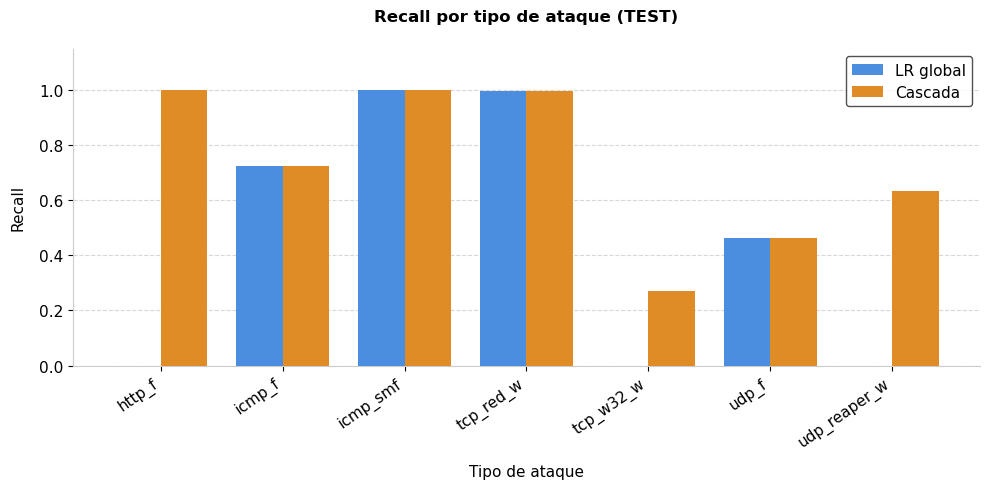

In [295]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.serif"] = ["Arial"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plot_df = df_test_attack_comparison.copy()
x = np.arange(len(plot_df))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

# Colores: Azul Marino para global, Verde Esmeralda/Académico para Cascada
color_azul = "#4B8EE0"
color_verde = "#DF8C27"

# 1. Creamos las barras iniciales con altura CERO
bars_global = ax.bar(x - width / 2, np.zeros(len(plot_df)), width, label="LR global", color=color_azul, zorder=3)
bars_cascade = ax.bar(x + width / 2, np.zeros(len(plot_df)), width, label="Cascada", color=color_verde, zorder=3,)

# Estilizado estático del gráfico
ax.set_xticks(x)
ax.set_xticklabels(plot_df["attack_t"], rotation=35, ha="right", fontsize=11, color="#000000")
ax.tick_params(axis="y", labelsize=11, colors="#000000")
ax.set_ylim(0, 1.15)  # Espacio para que las barras no toquen el borde arriba
ax.set_ylabel("Recall", fontsize=11, labelpad=10, color="#000000")
ax.set_xlabel("Tipo de ataque", fontsize=11, labelpad=10, color="#000000")
ax.set_title("Recall por tipo de ataque (TEST)", fontsize=12, fontweight="bold", pad=20)

ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
ax.legend(frameon=True, edgecolor="#272626", fontsize=11, loc="upper right")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

# 2. Definimos el número total de frames por fase de la animación
total_frames_fase = 50  # Duración de la subida de cada grupo de barras
# 2. Fotogramas de pausa al final de cada fase (para que no cambie de golpe)
pausa_intermedia = 30
pausa_final = 35

# 3. Función que actualiza la altura de las barras cuadro a cuadro
def update(frame):
    # FASE 1: Suben las barras azules (LR global)
    if frame <= total_frames_fase:
        progreso = frame / total_frames_fase
        for bar, h_final in zip(bars_global, plot_df["recall_global"]):
            bar.set_height(h_final * progreso)

    # PAUSA 1: Mantener barras azules congeladas un momento antes de empezar las verdes
    elif frame <= total_frames_fase + pausa_intermedia:
        for bar, h_final in zip(bars_global, plot_df["recall_global"]):
            bar.set_height(h_final)

    # FASE 2: Suben las barras verdes (Cascada)
    elif frame <= (total_frames_fase * 2) + pausa_intermedia:
        frame_actual_verde = frame - (total_frames_fase + pausa_intermedia)
        progreso = frame_actual_verde / total_frames_fase
        for bar, h_final in zip(bars_global, plot_df["recall_global"]):
            bar.set_height(h_final)
        for bar, h_final in zip(bars_cascade, plot_df["recall_cascade"]):
            bar.set_height(h_final * progreso)

    # PAUSA FINAL: Mantener ambas barras arriba para poder apreciarlas
    else:
        for bar, h_final in zip(bars_global, plot_df["recall_global"]):
            bar.set_height(h_final)
        for bar, h_final in zip(bars_cascade, plot_df["recall_cascade"]):
            bar.set_height(h_final)

    return list(bars_global) + list(bars_cascade)
total_frames_totales = (total_frames_fase * 2) + pausa_intermedia + pausa_final
ani = animation.FuncAnimation(fig, update, frames=total_frames_totales, interval=60, blit=False)
plt.tight_layout()
#Guardar como GIF animado (Requiere la librería 'pillow', instalable con: pip install pillow)
ani.save(FINAL_CASCADE_PATH / "test_recall_global_vs_cascade_animated.gif", writer="pillow", fps=20)
plt.show()

2. Evolución de FPR frente a macro-recall por etapa

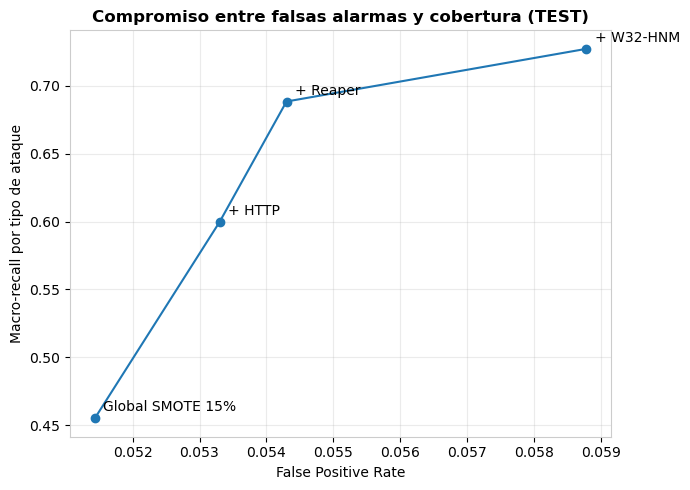

In [296]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_test_cascade_stages["fpr"], df_test_cascade_stages["macro_recall"], marker="o")
for _, row in df_test_cascade_stages.iterrows():
    ax.annotate(row["stage"],(row["fpr"], row["macro_recall"]),
        xytext=(6, 5),
        fontsize=10,
        textcoords="offset points",
    )
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("Macro-recall por tipo de ataque")
ax.set_title("Compromiso entre falsas alarmas y cobertura (TEST)", fontweight="bold")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

3. Matriz de confusión final de la cascada

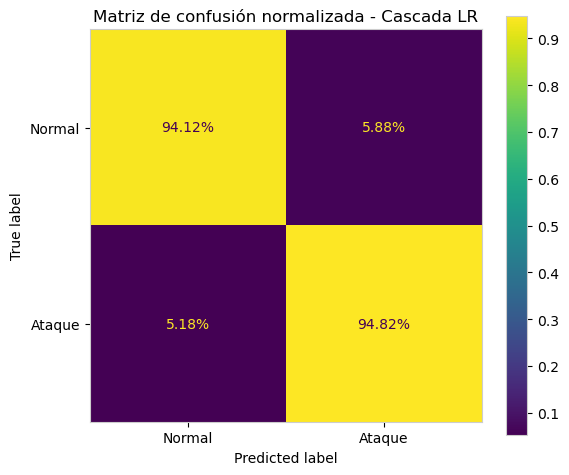

In [285]:
from sklearn.metrics import ConfusionMatrixDisplay
cascade_cm_abs = confusion_matrix(y_test_final, pred_cascade_final, labels=[0, 1])
cascade_cm_norm = confusion_matrix(y_test_final, pred_cascade_final, labels=[0, 1], normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cascade_cm_norm, display_labels=["Normal", "Ataque"]).plot(ax=ax, values_format=".2%")
ax.set_title("Matriz de confusión normalizada - Cascada LR")
plt.tight_layout()
plt.savefig(FINAL_CASCADE_PATH / "test_confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

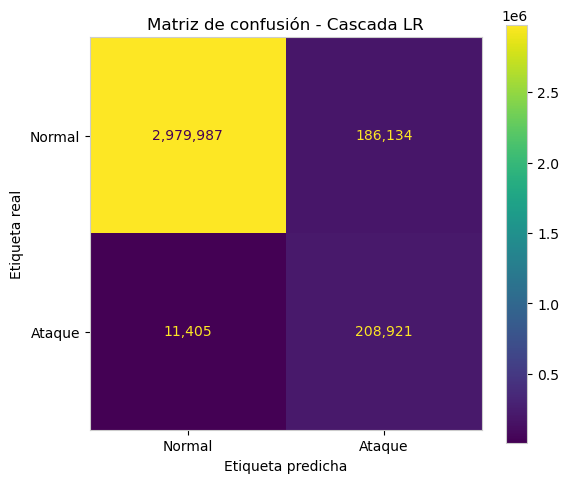

In [300]:
cascade_cm_abs = confusion_matrix(y_test_final, pred_cascade_final, labels=[0, 1])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cascade_cm_abs, display_labels=["Normal", "Ataque"]).plot(ax=ax, values_format=",d")
ax.set_title("Matriz de confusión - Cascada LR")
ax.set_xlabel("Etiqueta predicha")
ax.set_ylabel("Etiqueta real")
plt.tight_layout()
plt.savefig(FINAL_CASCADE_PATH / "test_confusion_matrix_absolute.png", dpi=300, bbox_inches="tight")
plt.show()

4. PR curve + punto de cascada

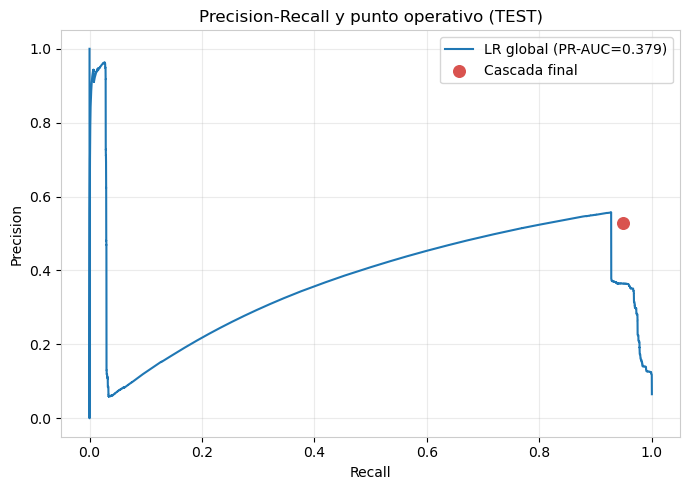

In [ ]:
precision_curve, recall_curve, _ = (precision_recall_curve(y_test_final, global_test_scores))
global_pr_auc = auc(recall_curve, precision_curve)
cascade_metrics = evaluate_binary_alerts(y_test_final, pred_cascade_final)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_curve, precision_curve, label=( f"LR global " f"(PR-AUC={global_pr_auc:.3f})"))
ax.scatter(cascade_metrics["recall"], cascade_metrics["precision"], color="#D9534F", s=70, marker="o", label="Cascada final")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall y punto operativo (TEST)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

5. ROC Curve

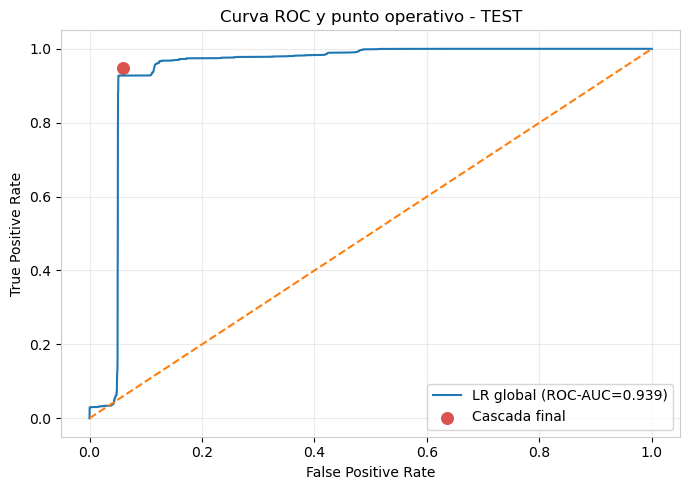

In [289]:
fpr_curve, tpr_curve, _ = roc_curve(y_test_final, global_test_scores)
global_roc_auc = roc_auc_score(y_test_final, global_test_scores)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_curve, tpr_curve, label=(f"LR global " f"(ROC-AUC={global_roc_auc:.3f})"))
ax.plot([0, 1], [0, 1], linestyle="--")
ax.scatter(cascade_metrics["fpr"], cascade_metrics["recall"], color="#D9534F", s=70, label="Cascada final")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC y punto operativo - TEST")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 14. Clasificación multiclase del tipo de ataque

### 14.1 Preparación de TRAIN y VALID multiclase

In [57]:
required_objects = ["X_train_binary_full", "X_valid_binary_full", "df_train_labels", "df_valid_labels"]
missing_objects = [
    name for name in required_objects
    if name not in globals()
]
if missing_objects:
    raise RuntimeError(f"Faltan objetos necesarios: {missing_objects}. Reejecuta las celdas de carga de FULL TRAIN/VALID y etiquetas.")
print("Objetos necesarios disponibles.")

Objetos necesarios disponibles.


Filtrar exclusivamente por attack_a=1

In [56]:
train_attack_idx = np.flatnonzero(df_train_labels["attack_a"].to_numpy() == 1)
valid_attack_idx = np.flatnonzero(df_valid_labels["attack_a"].to_numpy() == 1)
X_train_multiclass_full = (X_train_binary_full.iloc[train_attack_idx].reset_index(drop=True))
X_valid_multiclass_full = (X_valid_binary_full.iloc[valid_attack_idx].reset_index(drop=True))
y_train_multiclass_full = (df_train_labels["attack_t"].astype(str).to_numpy()[train_attack_idx])
y_valid_multiclass_full = (df_valid_labels["attack_t"].astype(str).to_numpy()[valid_attack_idx])
print("MULTICLASS TRAIN:", X_train_multiclass_full.shape, y_train_multiclass_full.shape)
print("MULTICLASS VALID:", X_valid_multiclass_full.shape, y_valid_multiclass_full.shape)

MULTICLASS TRAIN: (1028170, 22) (1028170,)
MULTICLASS VALID: (220322, 22) (220322,)


In [58]:
assert len(X_train_multiclass_full) == len(y_train_multiclass_full)
assert len(X_valid_multiclass_full) == len(y_valid_multiclass_full)
assert set(np.unique(y_train_multiclass_full)) == set(ATTACK_CLASS_ORDER)
assert set(np.unique(y_valid_multiclass_full)) == set(ATTACK_CLASS_ORDER)
print("Las siete clases están presentes y X/y están alineados.")

Las siete clases están presentes y X/y están alineados.


In [48]:
MULTICLASS_VALID_TARGETS_PATH = (LR_MULTICLASS_RESULTS_PATH / "validation_targets.npy")
np.save(MULTICLASS_VALID_TARGETS_PATH, np.asarray(y_valid_multiclass_full, dtype="U32"))
print("Targets VALID multiclase guardados.")

Targets VALID multiclase guardados.


In [49]:
del X_train_binary_full
del X_valid_binary_full
gc.collect()
print("Matrices binarias completas liberadas.")

Matrices binarias completas liberadas.


### 14.2 Distribución de los siete ataques

In [59]:
def multiclass_distribution(y, split_name):
    counts = pd.Series(y).value_counts().reindex(ATTACK_CLASS_ORDER)
    return pd.DataFrame({
        "split": split_name,
        "attack_t": ATTACK_CLASS_ORDER,
        "n": counts.to_numpy(),
        "proportion": counts.to_numpy() / counts.sum(),
    })
df_multiclass_distribution_full = pd.concat([
    multiclass_distribution(y_train_multiclass_full, "train"),
    multiclass_distribution(y_valid_multiclass_full, "valid"),], ignore_index=True)
df_multiclass_distribution_full

,split,attack_t,n,proportion
0,train,icmp_f,8139,0.007916
1,train,icmp_smf,41635,0.040494
2,train,udp_f,65508,0.063713
3,train,http_f,16071,0.015631
4,train,tcp_w32_w,17003,0.016537
5,train,tcp_red_w,878991,0.854908
6,train,udp_reaper_w,823,0.000800
7,valid,icmp_f,1744,0.007916
8,valid,icmp_smf,8922,0.040495
9,valid,udp_f,14037,0.063711


In [60]:
df_multiclass_distribution_pivot = (df_multiclass_distribution_full.pivot(index="attack_t", columns="split", values=["n", "proportion"]))
df_multiclass_distribution_pivot

n           proportion          
split            train     valid      train     valid
attack_t                                             
http_f         16071.0    3444.0   0.015631  0.015632
icmp_f          8139.0    1744.0   0.007916  0.007916
icmp_smf       41635.0    8922.0   0.040494  0.040495
tcp_red_w     878991.0  188355.0   0.854908  0.854908
tcp_w32_w      17003.0    3644.0   0.016537  0.016539
udp_f          65508.0   14037.0   0.063713  0.063711
udp_reaper_w     823.0     176.0   0.000800  0.000799

In [61]:
train_counts_mc = (pd.Series(y_train_multiclass_full).value_counts().reindex(ATTACK_CLASS_ORDER))
majority_class = train_counts_mc.idxmax()
minority_class = train_counts_mc.idxmin()
imbalance_ratio_mc = (train_counts_mc.max() / train_counts_mc.min())
print(f"Clase mayoritaria: {majority_class} ({train_counts_mc.max():,})")
print(f"Clase minoritaria: {minority_class} ({train_counts_mc.min():,})")
print(f"Relación mayoritaria/minoritaria: {imbalance_ratio_mc:.2f}:1")

Clase mayoritaria: tcp_red_w (878,991)
Clase minoritaria: udp_reaper_w (823)
Relación mayoritaria/minoritaria: 1068.03:1


Aquí el desbalance Red/Reaper supera 1.000:1, así que este problema es incluso más extremo internamente de lo que parecía al mirar únicamente normal/ataque.

In [62]:
# pesos automáticos que usaría class_weight
multiclass_class_weights_full = compute_class_weight_dict(y_train_multiclass_full)
df_multiclass_weights = pd.DataFrame({"attack_t": ATTACK_CLASS_ORDER, "class_weight": [
        multiclass_class_weights_full[c]
        for c in ATTACK_CLASS_ORDER
    ],
})
df_multiclass_weights

,attack_t,class_weight
0,icmp_f,18.046619
1,icmp_smf,3.527835
2,udp_f,2.242191
3,http_f,9.139533
4,tcp_w32_w,8.638560
5,tcp_red_w,0.167102
6,udp_reaper_w,178.470752


### 14.3 Baseline multiclase sin tratamiento

In [57]:
LR_MULTICLASS_SCREEN_PATH = (LR_MULTICLASS_RESULTS_PATH / "strategy_screening")
LR_MULTICLASS_SCREEN_PATH.mkdir(parents=True, exist_ok=True)
print(LR_MULTICLASS_SCREEN_PATH)

C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\logistic_regression\multiclass\strategy_screening


In [46]:
def run_multiclass_strategy(strategy_name, force=False):
    strategy_path = (LR_MULTICLASS_SCREEN_PATH / strategy_name)
    strategy_path.mkdir(parents=True, exist_ok=True)
    metrics_path = strategy_path / "validation_metrics.csv"
    per_class_path = strategy_path / "validation_per_class.csv"
    cm_path = strategy_path / "confusion_matrix.csv"
    pred_path = strategy_path / "validation_predictions.npy"
    if (
        not force
        and metrics_path.exists()
        and per_class_path.exists()
        and cm_path.exists()
    ):
        print(f"{strategy_name}: resultados existentes → no se reentrena.")
        return (pd.read_csv(metrics_path), pd.read_csv(per_class_path), pd.read_csv(cm_path, index_col=0))

    print("\n" + "=" * 60)
    print(f"MULTICLASE: {strategy_name.upper()}")
    print("=" * 60)
    pipeline = build_logistic_regression_pipeline(task="multiclass", strategy_name=strategy_name, y_train=y_train_multiclass_full)
    sampler = pipeline.named_steps["resampler"]
    classifier = pipeline.named_steps["classifier"]
    if strategy_name == "class_weight":
        print("Class weight:")
        print(classifier.class_weight)

    elif sampler != "passthrough":
        print("Sampling strategy:")
        print(sampler.sampling_strategy)

    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        pipeline.fit(X_train_multiclass_full, y_train_multiclass_full)
    fit_time = time.perf_counter() - start
    convergence_warning = any(issubclass(w.category, ConvergenceWarning) for w in caught)
    classifier = pipeline.named_steps["classifier"]
    n_iter = int(np.max(classifier.n_iter_))
    start = time.perf_counter()
    y_valid_pred = pipeline.predict(X_valid_multiclass_full)
    predict_time = time.perf_counter() - start
    summary, per_class, cm = (evaluate_multiclass_predictions(y_true=y_valid_multiclass_full, y_pred=y_valid_pred, class_order=ATTACK_CLASS_ORDER))
    summary.insert(0, "strategy", strategy_name)
    summary["fit_time_seconds"] = fit_time
    summary["predict_time_seconds"] = predict_time
    summary["n_iter"] = n_iter
    summary["max_iter"] = classifier.max_iter
    summary["convergence_warning"] = convergence_warning
    summary.to_csv(metrics_path, index=False, encoding="utf-8-sig")
    per_class.to_csv(per_class_path, index=False, encoding="utf-8-sig")
    cm.to_csv(cm_path, encoding="utf-8-sig")
    np.save(pred_path, np.asarray(y_valid_pred, dtype="U32"))
    print(f"Macro-F1: {summary.loc[0, 'macro_f1']:.6f}")
    print(f"Macro-recall: {summary.loc[0, 'macro_recall']:.6f}")
    print(f"Weighted-F1: {summary.loc[0, 'weighted_f1']:.6f}")
    print(f"Entrenamiento: {fit_time / 60:.2f} min")
    print(f"Predicción: {predict_time:.2f} s")
    print(f"Iteraciones: {n_iter}/{classifier.max_iter}")
    print(f"ConvergenceWarning: {convergence_warning}")
    del pipeline, y_valid_pred
    gc.collect()
    return summary, per_class, cm

#### Baseline: None

In [49]:
import time
mc_none_metrics, mc_none_per_class, mc_none_cm = (run_multiclass_strategy("none"))

none: resultados existentes → no se reentrena.


In [57]:
mc_none_metrics

,strategy,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,n,fit_time_seconds,predict_time_seconds,n_iter,max_iter,convergence_warning
0,none,0.989877,0.99787,0.99368,0.999405,0.99787,220322,159.596835,2.315197,59,1000,False


In [58]:
mc_none_per_class

,class,precision,recall,f1,support
0,icmp_f,0.929142,1.000000,0.963270,1744
1,icmp_smf,1.000000,0.985093,0.992491,8922
2,udp_f,1.000000,1.000000,1.000000,14037
3,http_f,1.000000,1.000000,1.000000,3444
4,tcp_w32_w,1.000000,1.000000,1.000000,3644
5,tcp_red_w,1.000000,1.000000,1.000000,188355
6,udp_reaper_w,1.000000,1.000000,1.000000,176


In [59]:
mc_none_cm

,pred_icmp_f,pred_icmp_smf,pred_udp_f,pred_http_f,pred_tcp_w32_w,pred_tcp_red_w,pred_udp_reaper_w
real_icmp_f,1744,0,0,0,0,0,0
real_icmp_smf,133,8789,0,0,0,0,0
real_udp_f,0,0,14037,0,0,0,0
real_http_f,0,0,0,3444,0,0,0
real_tcp_w32_w,0,0,0,0,3644,0,0
real_tcp_red_w,0,0,0,0,0,188355,0
real_udp_reaper_w,0,0,0,0,0,0,176


### 14.4 Auditoría del desempeño multiclase y separabilidad entre ataques

In [63]:
print("Predictores utilizados:")
print(predictor_columns)
FORBIDDEN_COLUMNS = {"attack_a", "attack_t", "dataset_name", "attack_family", "clase", "strata_key", "split", "row_id_model", "row_id_source"}
forbidden_present = sorted(FORBIDDEN_COLUMNS.intersection(X_train_multiclass_full.columns))
print("\nVariables prohibidas presentes:")
print(forbidden_present)

Predictores utilizados:
['td', 'sa', 'da', 'sp', 'dp', 'pr', 'tcp_flag_fin', 'tcp_flag_syn', 'tcp_flag_rst', 'tcp_flag_psh', 'tcp_flag_ack', 'tcp_flag_urg', 'tcp_flag_ece', 'tcp_flag_cwr', 'stos', 'ipkt', 'ibyt', 'in_if', 'out_if', 'sas', 'das', 'exp']

Variables prohibidas presentes:
[]


In [64]:
# ¿Hay registros con exactamente los mismos 22 valores predictivos presentes en ambos conjuntos?

train_hash = pd.util.hash_pandas_object(X_train_multiclass_full[predictor_columns], index=False).to_numpy(dtype=np.uint64)
valid_hash = pd.util.hash_pandas_object(X_valid_multiclass_full[predictor_columns], index=False).to_numpy(dtype=np.uint64)
unique_train_hash = np.unique(train_hash)
valid_seen_in_train = np.isin(valid_hash, unique_train_hash)
print(f"VALID exactamente repetido en TRAIN: "f"{valid_seen_in_train.sum():,} / "f"{len(valid_seen_in_train):,}")
print(f"Proporción: "f"{valid_seen_in_train.mean():.4%}")

VALID exactamente repetido en TRAIN: 2,236 / 220,322
Proporción: 1.0149%


In [70]:
df_exact_overlap = pd.DataFrame({
    "attack_t": y_valid_multiclass_full,
    "exact_seen_in_train": valid_seen_in_train,
})
df_exact_overlap = (df_exact_overlap.groupby("attack_t", as_index=False).agg(n=("exact_seen_in_train", "size"), exact_duplicates=("exact_seen_in_train", "sum"), proportion=("exact_seen_in_train", "mean")))
df_exact_overlap

,attack_t,n,exact_duplicates,proportion
0,http_f,3444,83,0.024100
1,icmp_f,1744,718,0.411697
2,icmp_smf,8922,1136,0.127326
3,tcp_red_w,188355,154,0.000818
4,tcp_w32_w,3644,0,0.000000
5,udp_f,14037,145,0.010330
6,udp_reaper_w,176,0,0.000000


**Comprobar cuánto se puede identificar solo con la “firma” de red**

In [65]:
SIGNATURE_COLUMNS = ["pr", "sp", "dp", "tcp_flag_fin", "tcp_flag_syn", "tcp_flag_rst", "tcp_flag_psh", "tcp_flag_ack", "tcp_flag_urg", "tcp_flag_ece", "tcp_flag_cwr"]
train_signature_hash = pd.util.hash_pandas_object(X_train_multiclass_full[SIGNATURE_COLUMNS], index=False).to_numpy(dtype=np.uint64)
valid_signature_hash = pd.util.hash_pandas_object(X_valid_multiclass_full[SIGNATURE_COLUMNS], index=False).to_numpy(dtype=np.uint64)

In [66]:
df_train_signature = pd.DataFrame({
    "signature": train_signature_hash,
    "attack_t": y_train_multiclass_full,
})
signature_stats = (df_train_signature.groupby("signature")["attack_t"].agg(predicted_class="first", n_classes="nunique"))
pure_signature_map = (signature_stats.loc[signature_stats["n_classes"] == 1, "predicted_class"])
print(f"Firmas únicas de TRAIN: " f"{len(signature_stats):,}")
print(f"Firmas puras: " f"{len(pure_signature_map):,}")

Firmas únicas de TRAIN: 125,755
Firmas puras: 125,754


In [73]:
valid_signature_prediction = (pd.Series(valid_signature_hash).map(pure_signature_map))
signature_covered = (valid_signature_prediction.notna())
signature_accuracy = (valid_signature_prediction[signature_covered].to_numpy() == np.asarray(y_valid_multiclass_full)[signature_covered.to_numpy()]).mean()
print(f"Cobertura VALID con firmas conocidas: " f"{signature_covered.mean():.4%}")
print(f"Accuracy dentro de firmas cubiertas: " f"{signature_accuracy:.4%}")

Cobertura VALID con firmas conocidas: 95.1489%
Accuracy dentro de firmas cubiertas: 100.0000%


**Revisar overfitting TRAIN vs VALID**

In [67]:
import joblib
mc_none_audit_model = (build_logistic_regression_pipeline(task="multiclass", strategy_name="none", y_train=y_train_multiclass_full))
start = time.perf_counter()
mc_none_audit_model.fit(X_train_multiclass_full, y_train_multiclass_full)
audit_fit_time = (time.perf_counter() - start)
print(f"Entrenamiento: " f"{audit_fit_time / 60:.2f} min")

Entrenamiento: 2.43 min


In [68]:
y_train_pred_audit = (mc_none_audit_model.predict(X_train_multiclass_full))
y_valid_pred_audit = (mc_none_audit_model.predict(X_valid_multiclass_full))

In [66]:
train_audit_metrics, _, _ = (evaluate_multiclass_predictions(y_true=y_train_multiclass_full, y_pred=y_train_pred_audit, class_order=ATTACK_CLASS_ORDER))
valid_audit_metrics, _, _ = (evaluate_multiclass_predictions(y_true=y_valid_multiclass_full, y_pred=y_valid_pred_audit, class_order=ATTACK_CLASS_ORDER))
df_train_valid_audit = pd.concat([train_audit_metrics.assign(split="train"), valid_audit_metrics.assign(split="valid")], ignore_index=True)
df_train_valid_audit[["split", "macro_precision", "macro_recall", "macro_f1", "weighted_f1", "balanced_accuracy"]]

,split,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy
0,train,0.990100,0.997921,0.993825,0.999419,0.997921
1,valid,0.989877,0.997870,0.993680,0.999405,0.997870


No existe evidencia de overfitting clásico importante

In [69]:
joblib.dump(mc_none_audit_model, LR_MULTICLASS_RESULTS_PATH / "lr_multiclass_none_candidate.joblib", compress=3)
print("Modelo baseline multiclase guardado.")

Modelo baseline multiclase guardado.


**Métricas excluyendo los vectores exactos que ya aparecieron en TRAIN:**

In [68]:
unseen_exact_mask = ~valid_seen_in_train
metrics_no_exact, per_class_no_exact, cm_no_exact = (evaluate_multiclass_predictions(y_true=np.asarray(y_valid_multiclass_full)[unseen_exact_mask], y_pred=np.asarray(y_valid_pred_audit)[unseen_exact_mask], class_order=ATTACK_CLASS_ORDER))
metrics_no_exact

,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,n
0,0.987313,0.998165,0.992438,0.999551,0.998165,218086


la LR también generaliza más allá de las firmas discretas ya conocidas, ya que al eliminar del análisis los 2.236 registros, cuyo vector completo de 22 predictores ya existía en TRAIN, el Macro-F1 baja solamente 0.00124.

In [74]:
unseen_signature_mask = ~signature_covered.to_numpy()
metrics_unseen_signature, per_class_unseen_signature, cm_unseen_signature = (evaluate_multiclass_predictions(
        y_true=np.asarray(y_valid_multiclass_full)[unseen_signature_mask],
        y_pred=np.asarray(y_valid_pred_audit)[unseen_signature_mask],
        class_order=ATTACK_CLASS_ORDER,
    )
)
metrics_unseen_signature

,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,n
0,0.833206,0.833333,0.83327,0.99986,0.833333,10688


El modelo es extraordinariamente bueno dentro de los patrones de ataque representados por LITNET-2020, pero pierde capacidad cuando protocolo + puertos + flags forman combinaciones no vistas previamente.

In [75]:
per_class_unseen_signature

,class,precision,recall,f1,support
0,icmp_f,0.999236,1.0,0.999618,1308
1,icmp_smf,0.000000,0.0,0.000000,1
2,udp_f,1.000000,1.0,1.000000,4737
3,http_f,1.000000,1.0,1.000000,3290
4,tcp_w32_w,0.000000,0.0,0.000000,0
5,tcp_red_w,1.000000,1.0,1.000000,1188
6,udp_reaper_w,1.000000,1.0,1.000000,164


In [77]:
cm_unseen_signature

,pred_icmp_f,pred_icmp_smf,pred_udp_f,pred_http_f,pred_tcp_w32_w,pred_tcp_red_w,pred_udp_reaper_w
real_icmp_f,1308,0,0,0,0,0,0
real_icmp_smf,1,0,0,0,0,0,0
real_udp_f,0,0,4737,0,0,0,0
real_http_f,0,0,0,3290,0,0,0
real_tcp_w32_w,0,0,0,0,0,0,0
real_tcp_red_w,0,0,0,0,0,1188,0
real_udp_reaper_w,0,0,0,0,0,0,164


### 14.5 Evaluación final multiclase sobre TEST

In [51]:
MULTICLASS_FINAL_CONFIG = {
    "task": "multiclass_attack_type",
    "model": "logistic_regression",
    "strategy": "none",
    "solver": "saga",
    "penalty": "l2",
    "C": 1.0,
    "fit_intercept": True,
    "max_iter": 1000,
    "tol": 1e-4,
    "random_state": RANDOM_STATE,
    "target": "attack_t",
    "classes": ATTACK_CLASS_ORDER,
    "selection_metric": "macro_f1",
}
MULTICLASS_FINAL_PATH = (LR_MULTICLASS_RESULTS_PATH / "final_none")
MULTICLASS_FINAL_PATH.mkdir(parents=True, exist_ok=True)
with open(MULTICLASS_FINAL_PATH / "final_config.json", "w", encoding="utf-8",) as f:
    json.dump(MULTICLASS_FINAL_CONFIG, f, indent=4, ensure_ascii=False)
print("Configuración multiclase congelada.")

Configuración multiclase congelada.


In [70]:
if "mc_none_audit_model" not in globals():
    mc_none_audit_model = joblib.load(LR_MULTICLASS_RESULTS_PATH / "lr_multiclass_none_candidate.joblib")
print("Modelo multiclase disponible.")

Modelo multiclase disponible.


In [71]:
if "df_test_final" not in globals():
    TEST_COLUMNS = list(dict.fromkeys(predictor_columns + ["attack_a", "attack_t"]))
    df_test_final = load_split_dataframe(
        split_name="test",
        preprocessing_config=preprocessing_config,
        use_dev_sample=False,
        columns=TEST_COLUMNS,
        project_root=PROJECT_ROOT,
    )
print("TEST completo:", df_test_final.shape)

TEST completo: (3386447, 24)


In [72]:
test_attack_mask_mc = (df_test_final["attack_a"].to_numpy() == 1)
X_test_multiclass_full = (df_test_final.loc[test_attack_mask_mc, predictor_columns].reset_index(drop=True))
y_test_multiclass_full = (df_test_final.loc[test_attack_mask_mc, "attack_t"].astype(str).to_numpy())
print("MULTICLASS TEST:", X_test_multiclass_full.shape)
print("Targets:", y_test_multiclass_full.shape)
print()
print(pd.Series(y_test_multiclass_full).value_counts().reindex(ATTACK_CLASS_ORDER))

MULTICLASS TEST: (220326, 22)
Targets: (220326,)

icmp_f            1745
icmp_smf          8922
udp_f            14038
http_f            3444
tcp_w32_w         3644
tcp_red_w       188356
udp_reaper_w       177
Name: count, dtype: int64


In [73]:
assert len(X_test_multiclass_full) == len(y_test_multiclass_full)
assert set(np.unique(y_test_multiclass_full)) == set(ATTACK_CLASS_ORDER)
print("TEST multiclase correctamente preparado.")

TEST multiclase correctamente preparado.


**Predicción final**

In [74]:
start = time.perf_counter()
y_test_multiclass_pred = (mc_none_audit_model.predict(X_test_multiclass_full))
test_multiclass_predict_time = (time.perf_counter() - start)
print(f"Predicción TEST: " f"{test_multiclass_predict_time:.2f} s")

Predicción TEST: 2.37 s


In [75]:
(test_multiclass_metrics, test_multiclass_per_class, test_multiclass_cm) = evaluate_multiclass_predictions(
    y_true=y_test_multiclass_full,
    y_pred=y_test_multiclass_pred,
    class_order=ATTACK_CLASS_ORDER,
)

In [76]:
test_multiclass_metrics.insert(0, "split", "test")
test_multiclass_metrics["predict_time_seconds"] = test_multiclass_predict_time
test_multiclass_metrics

,split,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,n,predict_time_seconds
0,test,0.989812,0.997854,0.993637,0.999401,0.997854,220326,2.371765


In [77]:
test_multiclass_per_class

,class,precision,recall,f1,support
0,icmp_f,0.928685,1.000000,0.963024,1745
1,icmp_smf,1.000000,0.984981,0.992434,8922
2,udp_f,1.000000,1.000000,1.000000,14038
3,http_f,1.000000,1.000000,1.000000,3444
4,tcp_w32_w,1.000000,1.000000,1.000000,3644
5,tcp_red_w,1.000000,1.000000,1.000000,188356
6,udp_reaper_w,1.000000,1.000000,1.000000,177


In [78]:
test_multiclass_cm

,pred_icmp_f,pred_icmp_smf,pred_udp_f,pred_http_f,pred_tcp_w32_w,pred_tcp_red_w,pred_udp_reaper_w
real_icmp_f,1745,0,0,0,0,0,0
real_icmp_smf,134,8788,0,0,0,0,0
real_udp_f,0,0,14038,0,0,0,0
real_http_f,0,0,0,3444,0,0,0
real_tcp_w32_w,0,0,0,0,3644,0,0
real_tcp_red_w,0,0,0,0,0,188356,0
real_udp_reaper_w,0,0,0,0,0,0,177


In [88]:
test_multiclass_metrics.to_csv(MULTICLASS_FINAL_PATH / "test_metrics.csv", index=False, encoding="utf-8-sig")
test_multiclass_per_class.to_csv(MULTICLASS_FINAL_PATH / "test_per_class.csv", index=False, encoding="utf-8-sig")
test_multiclass_cm.to_csv(MULTICLASS_FINAL_PATH / "test_confusion_matrix.csv", encoding="utf-8-sig")
np.save(MULTICLASS_FINAL_PATH / "test_predictions.npy", np.asarray(y_test_multiclass_pred, dtype="U32"))
np.save(MULTICLASS_FINAL_PATH / "test_targets.npy", np.asarray(y_test_multiclass_full, dtype="U32"))
print("Resultados TEST guardados.")

Resultados TEST guardados.


**VALID vs TEST**

In [89]:
valid_final_metrics = (valid_audit_metrics.copy())
valid_final_metrics.insert(0, "split", "valid")
df_multiclass_valid_test = pd.concat([valid_final_metrics, test_multiclass_metrics[valid_final_metrics.columns]], ignore_index=True)
df_multiclass_valid_test

,split,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,n
0,valid,0.989877,0.997870,0.993680,0.999405,0.997870,220322
1,test,0.989812,0.997854,0.993637,0.999401,0.997854,220326


**Resultados TEST por ataque**

In [79]:
test_multiclass_per_class["errors"] = (test_multiclass_per_class["support"] * (1 - test_multiclass_per_class["recall"])).round().astype(int)
test_multiclass_per_class

,class,precision,recall,f1,support,errors
0,icmp_f,0.928685,1.000000,0.963024,1745,0
1,icmp_smf,1.000000,0.984981,0.992434,8922,134
2,udp_f,1.000000,1.000000,1.000000,14038,0
3,http_f,1.000000,1.000000,1.000000,3444,0
4,tcp_w32_w,1.000000,1.000000,1.000000,3644,0
5,tcp_red_w,1.000000,1.000000,1.000000,188356,0
6,udp_reaper_w,1.000000,1.000000,1.000000,177,0


In [80]:
# Principales confusiones
confusion_records = []
for real_class in ATTACK_CLASS_ORDER:
    for pred_class in ATTACK_CLASS_ORDER:
        if real_class == pred_class:
            continue
        count = int(test_multiclass_cm.loc[f"real_{real_class}",f"pred_{pred_class}"])
        if count > 0:
            confusion_records.append({
                "real_class": real_class,
                "predicted_class": pred_class,
                "count": count,
            })
df_multiclass_confusions = (pd.DataFrame(confusion_records))
if not df_multiclass_confusions.empty:
    df_multiclass_confusions = (df_multiclass_confusions.sort_values("count", ascending=False).reset_index(drop=True))
df_multiclass_confusions

,real_class,predicted_class,count
0,icmp_smf,icmp_f,134


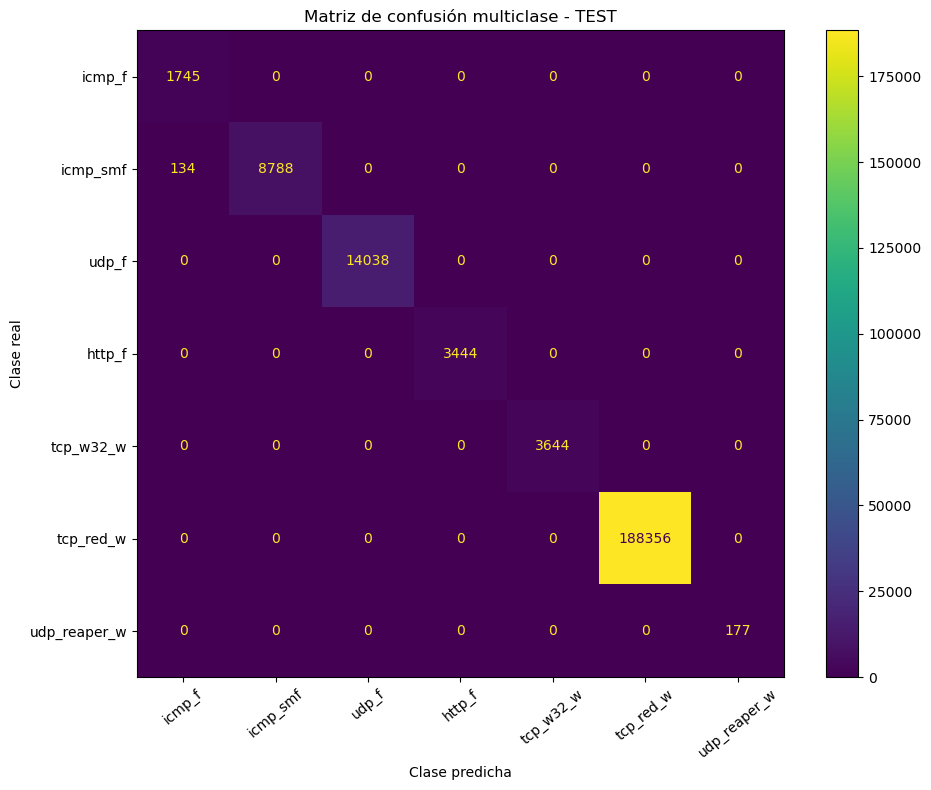

In [81]:
# Matriz de confusión absoluta
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm_test_abs = confusion_matrix(y_test_multiclass_full, y_test_multiclass_pred, labels=ATTACK_CLASS_ORDER)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_test_abs, display_labels=ATTACK_CLASS_ORDER,).plot(ax=ax, values_format="d", xticks_rotation=40)
ax.set_title("Matriz de confusión multiclase - TEST")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
plt.tight_layout()
plt.show()

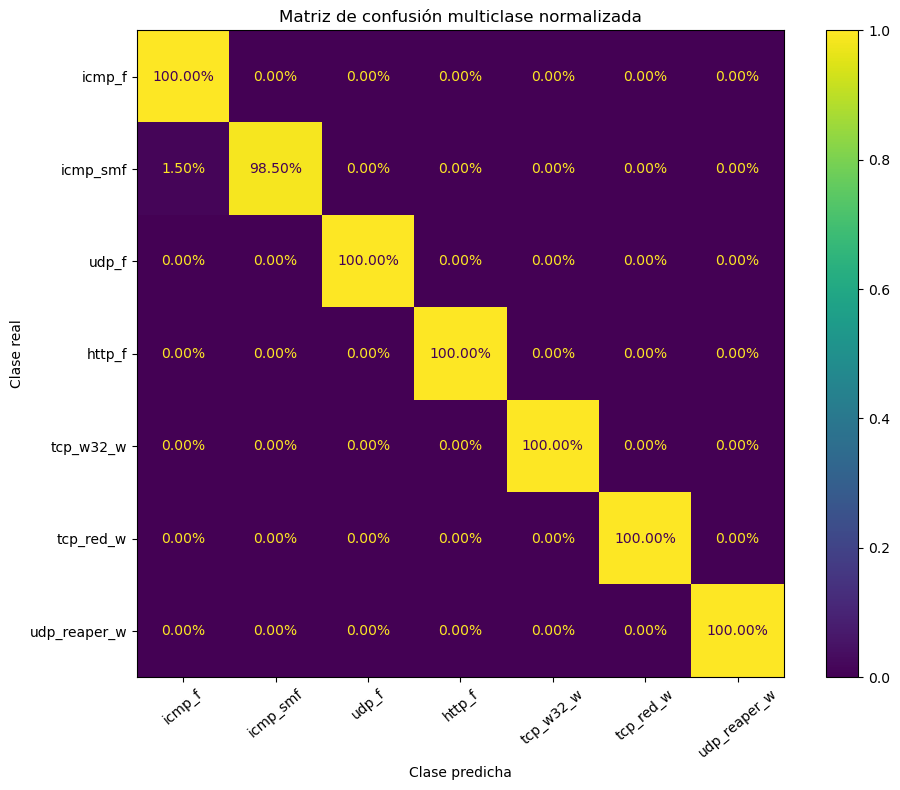

In [96]:
# Matriz de confusión normalizada
cm_test_norm = confusion_matrix(y_test_multiclass_full, y_test_multiclass_pred, labels=ATTACK_CLASS_ORDER, normalize="true")
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_test_norm, display_labels=ATTACK_CLASS_ORDER,).plot(ax=ax, values_format=".2%", xticks_rotation=40)
ax.set_title("Matriz de confusión multiclase normalizada")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
plt.tight_layout()
plt.show()

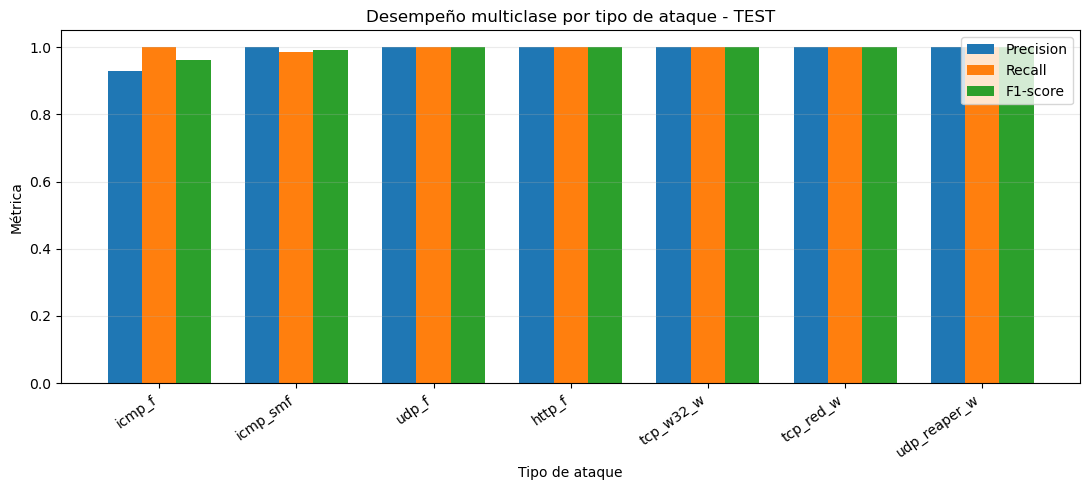

In [83]:
# Precision, Recall y F1 por ataque
plot_mc = (test_multiclass_per_class.copy())
x = np.arange(len(plot_mc))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, plot_mc["precision"], width, label="Precision")
ax.bar(x, plot_mc["recall"], width, label="Recall")
ax.bar(x + width, plot_mc["f1"], width, label="F1-score")
ax.set_xticks(x)
ax.set_xticklabels(plot_mc["class"].astype(str), rotation=35, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Métrica")
ax.set_xlabel("Tipo de ataque")
ax.set_title("Desempeño multiclase por tipo de ataque - TEST")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### 14.6 Interpretar la Regresión Logística multiclase

¿qué variables transformadas tienen mayor peso para cada clase? - coef

In [84]:
print(mc_none_audit_model.named_steps.keys())

dict_keys(['preprocessor', 'resampler', 'classifier'])


In [85]:
mc_preprocessor = (mc_none_audit_model.named_steps["preprocessor"])
mc_classifier = (mc_none_audit_model.named_steps["classifier"])
print("Clases:")
print(mc_classifier.classes_)
print("Coeficientes:")
print(mc_classifier.coef_.shape)

Clases:
['http_f' 'icmp_f' 'icmp_smf' 'tcp_red_w' 'tcp_w32_w' 'udp_f'
 'udp_reaper_w']
Coeficientes:
(7, 39)


In [86]:
mc_feature_names = (mc_preprocessor.get_feature_names_out())
print("Número de variables transformadas:", len(mc_feature_names))

Número de variables transformadas: 39


In [87]:
# Matriz de coeficientes multiclase
df_mc_coefficients = pd.DataFrame(mc_classifier.coef_, index=mc_classifier.classes_, columns=mc_feature_names)
df_mc_coefficients

,num_log__td,num_log__ipkt,num_log__ibyt,flags__tcp_flag_fin,flags__tcp_flag_syn,flags__tcp_flag_rst,flags__tcp_flag_psh,flags__tcp_flag_ack,flags__tcp_flag_urg,flags__tcp_flag_ece,...,ip_features__da_prefix_freq,ip_features__da_is_ipv6,port_features__sp_is_zero,port_features__sp_is_well_known,port_features__sp_is_registered,port_features__sp_is_dynamic,port_features__dp_is_zero,port_features__dp_is_well_known,port_features__dp_is_registered,port_features__dp_is_dynamic
http_f,-0.522027,-0.954451,1.100050,0.823712,-0.841176,1.270330,0.677369,1.930793,0.0,0.0,...,-0.625120,-0.189695,-0.955232,-0.596253,0.999041,0.949790,-0.031250,1.843733,-1.289988,-0.173511
icmp_f,1.238387,2.645522,-2.281247,-0.049324,-0.568146,-0.076864,-0.029024,-0.445023,0.0,0.0,...,-4.000000,-0.060754,2.546890,-0.321624,-0.485970,-0.427154,3.645524,-1.392678,-0.336070,-0.076077
icmp_smf,-0.460271,-4.433011,2.834479,-0.073025,-1.000000,-0.131932,-0.204499,-0.999868,0.0,0.0,...,3.752585,-0.225078,1.290332,-1.000000,-1.008543,-1.000000,-3.301926,1.926560,-0.500000,-0.250000
tcp_red_w,1.012012,1.296175,-0.606379,-0.346526,1.143718,-0.206127,-0.292346,2.209319,0.0,0.0,...,2.269134,-0.019072,-0.338468,3.216789,-0.982202,-2.539507,-0.016175,-2.068810,0.703532,0.757389
tcp_w32_w,-0.586745,1.321870,-0.503494,-0.145056,1.071440,-0.324981,-0.074169,-1.590402,0.0,0.0,...,-1.127345,-0.030389,-0.431862,-1.136200,-0.781381,2.028879,-0.020536,-3.477531,3.541757,-0.214768
udp_f,-0.499726,-1.988326,1.157700,-0.145376,-1.408827,-0.203987,-0.052081,-0.865869,0.0,0.0,...,2.000000,0.549266,-1.505705,-0.488250,1.669046,0.975034,-0.152583,1.184985,-0.653695,-0.130758
udp_reaper_w,-0.271649,1.931701,-1.441266,-0.106104,1.163885,-0.508088,-0.031169,-0.609846,0.0,0.0,...,-0.401726,-0.046962,-0.635511,-0.322394,0.590170,0.141697,-0.070955,1.638948,-2.000000,-0.081383


In [88]:
df_mc_coefficients.columns = [str(col).replace("num__", "").replace("flags__", "").replace("cat__", "").replace("remainder__", "") for col in df_mc_coefficients.columns]

**Variables que más favorecen cada ataque**

In [89]:
TOP_N = 8
top_positive_coefficients = []
for attack in mc_classifier.classes_:
    top = (df_mc_coefficients.loc[attack].sort_values(ascending=False).head(TOP_N))
    for feature, coef in top.items():
        top_positive_coefficients.append({
            "attack_t": attack,
            "feature": feature,
            "coefficient": coef,
        })
df_mc_top_positive = pd.DataFrame(top_positive_coefficients)
df_mc_top_positive

,attack_t,feature,coefficient
0,http_f,onehot__exp_1,1.996789
1,http_f,onehot__pr_TCP,1.996789
2,http_f,tcp_flag_ack,1.930793
3,http_f,port_features__dp_is_well_known,1.843733
4,http_f,frequency__stos_freq,1.352867
5,http_f,tcp_flag_rst,1.270330
6,http_f,num_log__ibyt,1.100050
7,http_f,port_features__sp_is_registered,0.999041
8,icmp_f,port_features__dp_is_zero,3.645524
9,icmp_f,num_log__ipkt,2.645522


**Alejan al modelo de cada clase**

In [90]:
top_negative_coefficients = []
for attack in mc_classifier.classes_:
    top = (df_mc_coefficients.loc[attack].sort_values().head(TOP_N))
    for feature, coef in top.items():
        top_negative_coefficients.append({
            "attack_t": attack,
            "feature": feature,
            "coefficient": coef,
        })
df_mc_top_negative = pd.DataFrame(top_negative_coefficients)
df_mc_top_negative

,attack_t,feature,coefficient
0,http_f,frequency__das_freq,-2.794015
1,http_f,frequency__in_if_freq,-1.978565
2,http_f,port_features__dp_is_registered,-1.289988
3,http_f,port_features__sp_is_zero,-0.955232
4,http_f,onehot__exp_2,-0.955232
5,http_f,onehot__pr_ICMP,-0.955232
6,http_f,num_log__ipkt,-0.954451
7,http_f,frequency__out_if_freq,-0.882637
8,icmp_f,frequency__dp_freq,-4.000000
9,icmp_f,frequency__in_if_freq,-4.000000


¿qué valores originales caracterizan a cada ataque?

**Perfil de los valores originales por ataque**

In [91]:
df_mc_original_train = (X_train_multiclass_full.copy())
df_mc_original_train["attack_t"] = (y_train_multiclass_full)

In [92]:
def dominant_value(df, attack, column):
    s = df.loc[df["attack_t"] == attack, column]
    counts = s.value_counts(dropna=False)
    value = counts.index[0]
    proportion = counts.iloc[0] / len(s)
    return value, proportion

In [93]:
profile_rows = []
for attack in ATTACK_CLASS_ORDER:
    pr_value, pr_prop = dominant_value(df_mc_original_train, attack, "pr")
    sp_value, sp_prop = dominant_value(df_mc_original_train, attack, "sp")
    dp_value, dp_prop = dominant_value(df_mc_original_train, attack, "dp")
    subset = df_mc_original_train[df_mc_original_train["attack_t"] == attack]
    profile_rows.append({
        "attack_t": attack,
        "protocol_mode": pr_value,
        "protocol_pct": pr_prop,
        "sp_mode": sp_value,
        "sp_pct": sp_prop,
        "dp_mode": dp_value,
        "dp_pct": dp_prop,
        "SYN_pct": subset["tcp_flag_syn"].mean(),
        "ACK_pct": subset["tcp_flag_ack"].mean(),
        "PSH_pct": subset["tcp_flag_psh"].mean(),
        "RST_pct": subset["tcp_flag_rst"].mean(),
        "FIN_pct": subset["tcp_flag_fin"].mean(),
        "td_median": subset["td"].median(),
        "ipkt_median": subset["ipkt"].median(),
        "ibyt_median": subset["ibyt"].median(),
    })
df_mc_attack_profiles = pd.DataFrame(profile_rows)
df_mc_attack_profiles

,attack_t,protocol_mode,protocol_pct,sp_mode,sp_pct,dp_mode,dp_pct,SYN_pct,ACK_pct,PSH_pct,RST_pct,FIN_pct,td_median,ipkt_median,ibyt_median
0,icmp_f,ICMP,1.0,0,1.000000,11,0.742966,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,80.0
1,icmp_smf,ICMP,1.0,0,1.000000,771,0.996397,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,183.0
2,udp_f,UDP,1.0,61454,0.000153,53,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,2.0,184.0
3,http_f,TCP,1.0,58653,0.000373,80,1.000000,0.277830,0.800759,0.283865,0.265696,0.288781,0.0,5.0,500.0
4,tcp_w32_w,TCP,1.0,56667,1.000000,4444,1.000000,0.990178,0.000000,0.000000,0.012057,0.000000,0.0,5.0,200.0
5,tcp_red_w,TCP,1.0,80,1.000000,1708,0.000049,0.996397,0.998932,0.000008,0.006658,0.000159,0.0,5.0,220.0
6,udp_reaper_w,TCP,1.0,38899,0.002430,81,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,2.0,80.0


In [94]:
percentage_cols = ["protocol_pct", "sp_pct", "dp_pct", "SYN_pct", "ACK_pct", "PSH_pct", "RST_pct", "FIN_pct"]
df_mc_attack_profiles_display = (df_mc_attack_profiles.copy())
df_mc_attack_profiles_display[percentage_cols] *= 100
df_mc_attack_profiles_display.round(3)

,attack_t,protocol_mode,protocol_pct,sp_mode,sp_pct,dp_mode,dp_pct,SYN_pct,ACK_pct,PSH_pct,RST_pct,FIN_pct,td_median,ipkt_median,ibyt_median
0,icmp_f,ICMP,100.0,0,100.000,11,74.297,0.000,0.000,0.000,0.000,0.000,0.0,1.0,80.0
1,icmp_smf,ICMP,100.0,0,100.000,771,99.640,0.000,0.000,0.000,0.000,0.000,0.0,1.0,183.0
2,udp_f,UDP,100.0,61454,0.015,53,100.000,0.000,0.000,0.000,0.000,0.000,0.0,2.0,184.0
3,http_f,TCP,100.0,58653,0.037,80,100.000,27.783,80.076,28.387,26.570,28.878,0.0,5.0,500.0
4,tcp_w32_w,TCP,100.0,56667,100.000,4444,100.000,99.018,0.000,0.000,1.206,0.000,0.0,5.0,200.0
5,tcp_red_w,TCP,100.0,80,100.000,1708,0.005,99.640,99.893,0.001,0.666,0.016,0.0,5.0,220.0
6,udp_reaper_w,TCP,100.0,38899,0.243,81,100.000,100.000,0.000,0.000,0.000,0.000,0.0,2.0,80.0


Heatmap pequeño de coeficientes

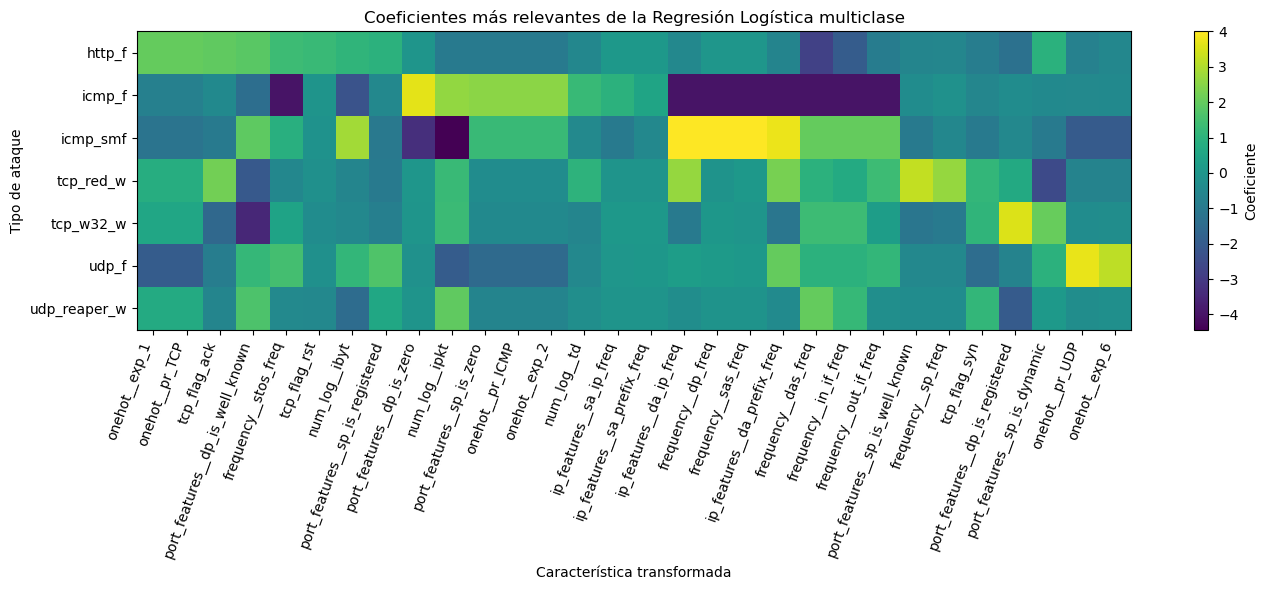

In [95]:
top_features_union = (df_mc_top_positive["feature"].drop_duplicates().tolist())
coef_plot = (df_mc_coefficients[top_features_union])
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(coef_plot.to_numpy(), aspect="auto")
ax.set_yticks(np.arange(len(coef_plot.index)))
ax.set_yticklabels(coef_plot.index)
ax.set_xticks(np.arange(len(coef_plot.columns)))
ax.set_xticklabels(coef_plot.columns, rotation=70, ha="right")
ax.set_title("Coeficientes más relevantes de la Regresión Logística multiclase")
ax.set_xlabel("Característica transformada")
ax.set_ylabel("Tipo de ataque")
fig.colorbar(im, ax=ax, label="Coeficiente")
plt.tight_layout()
plt.show()

**Experimento final: ablación de variables dependientes de infraestructura**

In [98]:
INFRASTRUCTURE_RAW_COLUMNS = ["sa", "da", "sas", "das", "in_if", "out_if", "exp"]

In [99]:
mc_preprocessor = (mc_none_audit_model.named_steps["preprocessor"])
X_train_mc_t = mc_preprocessor.transform(X_train_multiclass_full)
X_valid_mc_t = mc_preprocessor.transform(X_valid_multiclass_full)
mc_feature_names = np.asarray(mc_preprocessor.get_feature_names_out(), dtype=str)
print("TRAIN transformado:", X_train_mc_t.shape)
print("VALID transformado:", X_valid_mc_t.shape)
print("Features:", len(mc_feature_names))

TRAIN transformado: (1028170, 39)
VALID transformado: (220322, 39)
Features: 39


In [100]:
INFRASTRUCTURE_PREFIXES = ("ip_features__sa_","ip_features__da_","frequency__sas_","frequency__das_","frequency__in_if_","frequency__out_if_","onehot__exp_")
infra_mask = np.array([feature.startswith(INFRASTRUCTURE_PREFIXES)for feature in mc_feature_names])
infra_features_removed = (mc_feature_names[infra_mask])
generic_features_kept = (mc_feature_names[~infra_mask])
print(f"Características originales transformadas: "f"{len(mc_feature_names)}")
print(f"Características eliminadas: "f"{infra_mask.sum()}")
print(f"Características conservadas: "f"{(~infra_mask).sum()}")
print("\nEliminadas:")
for feature in infra_features_removed:
    print(" -", feature)

Características originales transformadas: 39
Características eliminadas: 14
Características conservadas: 25

Eliminadas:
 - onehot__exp_1
 - onehot__exp_2
 - onehot__exp_6
 - onehot__exp_7
 - frequency__sas_freq
 - frequency__das_freq
 - frequency__in_if_freq
 - frequency__out_if_freq
 - ip_features__sa_ip_freq
 - ip_features__sa_prefix_freq
 - ip_features__sa_is_ipv6
 - ip_features__da_ip_freq
 - ip_features__da_prefix_freq
 - ip_features__da_is_ipv6


In [101]:
X_train_mc_generic = (X_train_mc_t[:, ~infra_mask])
X_valid_mc_generic = (X_valid_mc_t[:, ~infra_mask])
print("TRAIN sin infraestructura:", X_train_mc_generic.shape)
print("VALID sin infraestructura:", X_valid_mc_generic.shape)

TRAIN sin infraestructura: (1028170, 25)
VALID sin infraestructura: (220322, 25)


In [102]:
lr_multiclass_ablation = LogisticRegression(**LR_BASE_PARAMS)
start = time.perf_counter()
lr_multiclass_ablation.fit(X_train_mc_generic, y_train_multiclass_full)
ablation_fit_time = (time.perf_counter() - start)
print(f"Entrenamiento ablación: "f"{ablation_fit_time / 60:.2f} min")
print("Iteraciones:", lr_multiclass_ablation.n_iter_)

Entrenamiento ablación: 1.17 min
Iteraciones: [40]


In [103]:
y_valid_ablation_pred = (lr_multiclass_ablation.predict(X_valid_mc_generic))
(ablation_metrics, ablation_per_class, ablation_cm,) = evaluate_multiclass_predictions(y_true=y_valid_multiclass_full, y_pred=y_valid_ablation_pred, class_order=ATTACK_CLASS_ORDER)
ablation_metrics

,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,n
0,0.984629,0.99503,0.989373,0.999063,0.99503,220322


Las variables de infraestructura ayudan de forma material, aunque sigue existiendo mucha señal general del comportamiento.

In [104]:
ablation_per_class

,class,precision,recall,f1,support
0,icmp_f,0.892985,1.000000,0.943468,1744
1,icmp_smf,1.000000,0.976575,0.988149,8922
2,udp_f,1.000000,1.000000,1.000000,14037
3,http_f,0.999420,1.000000,0.999710,3444
4,tcp_w32_w,1.000000,1.000000,1.000000,3644
5,tcp_red_w,1.000000,1.000000,1.000000,188355
6,udp_reaper_w,1.000000,0.988636,0.994286,176


In [105]:
del (X_train_mc_t, X_valid_mc_t, X_train_mc_generic, X_valid_mc_generic)
gc.collect()

20276

El elevado desempeño multiclase no depende de manera sustancial de características específicas de infraestructura, como direcciones IP, sistemas autónomos, interfaces o exportadores. La mayor parte de la capacidad discriminativa se conserva utilizando características más generales del comportamiento del flujo, como protocolo, puertos, banderas TCP y variables de volumen. Sin embargo, la reducción observada frente a combinaciones de estas características no representadas durante el entrenamiento indica que el modelo continúa siendo sensible a cambios en los patrones de tráfico aprendidos.